# Import packages

In [1]:
import mlflow
# Set MLflow experiment
mlflow.set_experiment("GeoX_Test_Readout")


/Users/ppavuluri/Desktop/cursor_databricks_setup/.venv/lib/python3.11/site-packages/mlflow/tracking/_tracking_service/utils.py:140: FutureWarning: Filesystem tracking backend (e.g., './mlruns') is deprecated. Please switch to a database backend (e.g., 'sqlite:///mlflow.db'). For feedback, see: https://github.com/mlflow/mlflow/issues/18534
  return FileStore(store_uri, store_uri)


<Experiment: artifact_location='file:///Users/ppavuluri/Desktop/mlruns/620010354575338676', creation_time=1772571412344, experiment_id='620010354575338676', last_update_time=1772571412344, lifecycle_stage='active', name='GeoX_Test_Readout', tags={}>

In [2]:
import panel_exp
import os
import numpy as np
import pandas as pd
# from databricks import sql
import matplotlib.pyplot as plt
import seaborn as sns
# import multiprocessing
from sklearn.linear_model import RidgeCV, Ridge
from typing import Dict, List, NewType, Optional, Tuple, Union
from abc import ABCMeta
from datetime import datetime, timedelta
# from panel_exp.util import standardize

from panel_exp.panel_data import long_df_to_paneldataset, PanelDataset, TimePeriod
from panel_exp.methods.triply_robust_est import TROP
from panel_exp.methods.tbr import TBR, TBRRidge, TBRAutoSARIMAX
from panel_exp.methods.DID import DID
from panel_exp.methods.synthetic_did import SyntheticDID
from panel_exp.methods.bayesian_regression import BayesianTBR, BayesianTBRHorseShoe
from panel_exp.methods.scm import AugSynthCVXPY
from panel_exp.methods.scm import SyntheticControl, SyntheticControlCVXPY
from panel_exp.methods.mtgp import MTGP
from panel_exp.design.power import PowerAnalysis
from panel_exp.design import StratifiedRandomization, CompleteRandomization, ThinningDesign, Rerandomization, QuickBlock, MatchedPair, greedy_match_markets
from panel_exp.design.design_metrics import imbalance
from panel_exp.design.geo_experiment_design import GeoExperimentDesign
# from panel_exp.design.supergeos import SupergeoModel
from panel_exp.design.trimmed_match import TrimmedMatchDesign
from panel_exp.utils.test_designs_evaluation import *
from panel_exp.utils.apiutils import *
from panel_exp.utils.analysis_helper import * 
from panel_exp.utils.counterfactual_stability_tests import *

# Load environment variables from the .env file in the user folder
import os
from dotenv import load_dotenv
dotenv_path = '/Users/ppavuluri/Desktop/env/.env'  
load_dotenv(dotenv_path)

DATABRICKS_HOST = os.getenv("DATABRICKS_HOST")
DATABRICKS_TOKEN = os.getenv("DATABRICKS_TOKEN")
DATABRICKS_CLUSTER_ID = os.getenv("DATABRICKS_CLUSTER_ID")

# API_HOST = os.getenv("GEMSTONE_API_HOST")

In [3]:
cc= ['TEAM', 'STOCK', 'HED',  'INDIVIDUAL', 'PHOTOGRAPHY', 'K12+EEA', 'STUDENT']

dc = [ 'ACROBAT DC',  'ACROBAT CC' ]

all_segment = ['TEAM', 'STOCK', 'HED', 'ACROBAT DC', 'INDIVIDUAL', 'PHOTOGRAPHY', 'K12+EEA', 'ACROBAT CC', 'PDF SERVICES', 'SIGN', 'STUDENT']

dme = ['TEAM', 'STOCK', 'HED', 'ACROBAT DC', 'INDIVIDUAL', 'PHOTOGRAPHY', 'K12+EEA', 'ACROBAT CC', 'STUDENT']

In [4]:
from pyspark import SparkContext, SparkConf , StorageLevel
from pyspark.sql import SparkSession, HiveContext
from pyspark.sql.functions import *
from pyspark.sql.types import *
import logging
from datetime import datetime,timedelta 
import json
from pyspark.sql import functions
import sys
import pytz
import pandas as pd

In [5]:
from databricks.connect import DatabricksSession
import os

# Set Databricks connection parameters
DATABRICKS_HOST = os.getenv("DATABRICKS_HOST")
DATABRICKS_TOKEN = os.getenv("DATABRICKS_TOKEN")
DATABRICKS_CLUSTER_ID = os.getenv("DATABRICKS_CLUSTER_ID")

# Initialize Databricks session
spark = DatabricksSession.builder \
    .remote() \
    .getOrCreate()


In [6]:
# pd.set_option("display.max_columns", 300)
# pd.set_option("display.max_rows", 300)
# pd.options.display.float_format = None


# spark.sql('SET hive.groupby.orderby.position.alias=true')
# spark.sql('SET hive.exec.dynamic.partition=true')
# spark.sql('SET hive.exec.dynamic.partition.mode=nonstrict')
# spark.sql('SET spark.sql.sources.partitionOverwriteMode=dynamic')
# # spark.conf.set("spark.databricks.queryWatchdog.maxQueryTasks", "4000")

# #DELTA OPTIMIZATIONS
# spark.sql('SET spark.databricks.delta.autoCompact.enabled=auto')
# spark.sql('SET spark.databricks.delta.optimizeWrite.enabled=true')
# spark.sql('SET spark.sql.shuffle.partitions=auto')


# Fetch Data and Plot trends

In [7]:
# # # Sales and Conversions data for last 12 months fetched from pivot table
# us_sales_l12m = spark.sql("""
#      select date
#      , geo
#      , cc_segment
#      , di_y_n
#      , video_y_n
#      , sum(response1) as sales 
#      , sum(response2) as conversions 
# from gmi_im.us_dme_sales_l12m
# where cc_segment is not null
# group by 1,2,3,4,5
# """).toPandas()

# # # Conversions data for last 12 months fetched from web orders
# us_web_orders_l12m = spark.sql("""select 
#      click_date as date
#      , b.dma_id as geo  
#      , sum(buy_orders)  all_buy_orders
#      , sum(try_orders) all_try_orders
#      , sum(buy_orders + try_orders) all_orders 
#      , sum(cc) cc_all_orders 
#      , sum(dc) dc_all_orders 
#      , sum(dme) dme_all_orders 
#      , sum(cc_buy) as cc_buy_orders
#      , sum(dc_buy ) as dc_buy_orders
#      , sum(dme_buy) as dme_buy_orders
#      , sum(cc_try) as cc_try_orders
#      , sum(dc_try) as dc_try_orders
#      , sum(dme_try) as dme_try_orders

# from gmi_im.us_dly_dma_web_orders a
# join gmi_im.unpack_sales_region b 
# on a.dma = b.dma
# where split_part(a.dma,':',1) = 'usa'
# and dma_id is not null
# and dma_id != 0
# group by all""").toPandas()


# us_web_visits_l12m = spark.sql("""select 
#      click_date as date
#      , b.dma_id as geo  
#      , sum(visits)  visits
#      , sum(unique_visitors) unique_visitors

# from gmi_im.us_top_pages_dly_dma_visits_and_visitors a
# join gmi_im.unpack_sales_region b 
# on a.dma = b.dma
# where split_part(a.dma,':',1) = 'usa'
# and dma_id is not null
# and dma_id != 0
# group by all""").toPandas()

# # us_web_visits_by_lt_l12m = spark.sql("""select 
# #      click_date as date
# #      , marketing_channel
# #      , channel_grouping
# #      , dma_id as geo  
# #      , sum(visits)  visits
# #      , sum(unique_visitors) unique_visitors

# # from gmi_im.us_dly_dma_traffic_by_lt_channel a
# # join gmi_im.unpack_sales_region b 
# # on a.dma = b.dma
# # where split_part(a.dma,':',1) = 'usa'
# # and dma_id is not null
# # and dma_id != 0
# # group by all""").toPandas()

# us_sales_l12m['geo'] = us_sales_l12m['geo'].astype(int).astype(str)
# us_web_orders_l12m['geo'] = us_web_orders_l12m['geo'].astype(int).astype(str)
# us_web_visits_l12m['geo'] = us_web_visits_l12m['geo'].astype(int).astype(str)
# us_web_visits_by_lt_l12m['geo'] = us_web_visits_by_lt_l12m['geo'].astype(int).astype(str)

# us_sales_l12m['date'] = pd.to_datetime(us_sales_l12m['date'])
# us_web_orders_l12m['date'] = pd.to_datetime(us_web_orders_l12m['date'])
# us_web_visits_l12m['date'] = pd.to_datetime(us_web_visits_l12m['date'])
# us_web_visits_by_lt_l12m['date'] = pd.to_datetime(us_web_visits_by_lt_l12m['date'])

In [8]:
# dim_date = spark.sql("""
# SELECT fiscal_yr_and_wk_desc, date_date FROM gmi_ml.dim_date GROUP BY ALL """).toPandas()

# dim_date.head()

In [9]:
# us_sales_l12m.to_pickle("/Users/ppavuluri/Desktop/FY26/Q1/Reddit/us_sales_l12m_oct24_feb26.pkl")
# us_web_orders_l12m.to_pickle("/Users/ppavuluri/Desktop/FY26/Q1/Reddit/us_web_orders_l12m.pkl")
# us_web_visits_l12m.to_pickle("/Users/ppavuluri/Desktop/FY26/Q1/Reddit/us_web_visits_l12m.pkl")

us_sales_l12m = pd.read_pickle("/Users/ppavuluri/Desktop/FY26/Q1/Reddit/us_sales_l12m_oct24_feb26.pkl")
us_web_orders_l12m = pd.read_pickle("/Users/ppavuluri/Desktop/FY26/Q1/Reddit/us_web_orders_l12m.pkl")
us_web_visits_l12m = pd.read_pickle("/Users/ppavuluri/Desktop/FY26/Q1/Reddit/us_web_visits_l12m.pkl")


In [10]:
# Convert daily data to weekly using fiscal_yr_and_wk_desc from dim_date
def convert_to_fy_week(df, dim_date, date_col='date'):
    """
    Convert daily data to weekly data using fiscal_yr_and_wk_desc from dim_date as fy_week.
    """
    df = df.copy()
    dim_date = dim_date.copy()

    # Ensure date columns are datetime
    df[date_col] = pd.to_datetime(df[date_col])
    dim_date['date_date'] = pd.to_datetime(dim_date['date_date'])

    # Merge with dim_date to get fiscal_yr_and_wk_desc
    df = df.merge(dim_date[['date_date', 'fiscal_yr_and_wk_desc']], left_on=date_col, right_on='date_date', how='left')
    df['date'] = df['fiscal_yr_and_wk_desc']
    df = df.drop(columns=['date_date', 'fiscal_yr_and_wk_desc'])

    # Group by fy_week and sum all numeric columns
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    other_cols = [col for col in df.columns if col not in numeric_cols and col != date_col and col != 'date']

    weekly_df = df.groupby(['date'] + other_cols)[numeric_cols].sum().reset_index()
    weekly_df = weekly_df[weekly_df.date <= '2026-13']

    return weekly_df


def convert_to_weekly_sat(df, date_col='date'):
    """
    Convert daily data to weekly data using Saturday as the week starting date.
    No dim_date required. Each date is assigned to the Saturday of its week (Sat–Fri),
    then numeric columns are summed by week.
    """
    df = df.copy()
    df[date_col] = pd.to_datetime(df[date_col])
    # W-FRI: week ends Friday, so week runs Sat–Fri; start_time gives the Saturday of each week
    df['week_start'] = df[date_col].dt.to_period('W-FRI').apply(lambda r: r.start_time)

    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    other_cols = [col for col in df.columns if col not in numeric_cols and col != date_col and col != 'week_start']

    weekly_df = df.groupby(['week_start'] + other_cols)[numeric_cols].sum().reset_index()
    weekly_df = weekly_df.rename(columns={'week_start': 'date'})
    return weekly_df

In [11]:
# us_wkly_sales_l12m = convert_to_fy_week(us_sales_l12m, dim_date)
# us_wkly_web_orders_l12m = convert_to_fy_week(us_web_orders_l12m, dim_date)
# us_wkly_web_visits_l12m = convert_to_fy_week(us_web_visits_l12m, dim_date)

us_wkly_sales_l12m = convert_to_weekly_sat(us_sales_l12m)
us_wkly_web_orders_l12m = convert_to_weekly_sat(us_web_orders_l12m)
us_wkly_web_visits_l12m = convert_to_weekly_sat(us_web_visits_l12m)

In [12]:
us_sales_l12m[(us_sales_l12m.date >= '2026-01-24') & (us_sales_l12m.date <= '2026-02-27')].groupby(['date']).agg({'conversions': 'sum'}).reset_index().conversions.sum()

721341

In [13]:
us_wkly_sales_l12m.date.min(), us_sales_l12m.date.max()

(Timestamp('2024-09-28 00:00:00'), Timestamp('2026-02-27 00:00:00'))

In [14]:
# # Data form newly created MOE table for visits, visitors and orders
# us_dly_mmt_data = spark.sql("""select 
#      date
#      , fiscal_yr_and_wk_desc as fy_wk
#      , dma_id
#      , sum(visits) as visits
#      , sum(visitors) as visitors
#      , sum(Orders) as orders
#      , sum(d2p_Orders) as d2p_orders
#      , sum(twp_Orders) as twp_orders
#      , sum(converted_twp_Orders) as converted_twp_orders
#      , sum(net_Orders) as net_orders
# from aa_uat.mmt_dma_asset
# where date >= cast(date_add(current_date, -400) as date)
# and dma_id is not null
# and dma_id != 0
# group by date, fiscal_yr_and_wk_desc, dma_id
# """).toPandas()

# us_dly_mmt_data['date'] = pd.to_datetime(us_dly_mmt_data['date'])
# us_dly_mmt_data['dma_id'] = us_dly_mmt_data['dma_id'].fillna(0).astype(int).astype(str)

In [15]:
# # Data form newly created MOE table for visits, visitors and orders
# us_uat_mmt_conv = spark.sql("""select 
#      event_date as date
#      , dma_id
#      , sum(Orders) as orders
#      , sum(d2p_Orders) as d2p_orders
#      , sum(twp_Orders) as twp_orders
#      , sum(converted_twp_Orders) as converted_twp_orders
#      , sum(net_Orders) as net_orders
# from aa_uat.mmt_dma_conversions
# where event_date >= cast(date_add('2026-02-28', -400) as date)
# and geo_country = 'usa'
# and dma_id is not null
# and dma_id != 0
# group by all
# """).toPandas()

# us_uat_mmt_conv['date'] = pd.to_datetime(us_uat_mmt_conv['date'])
# us_uat_mmt_conv['dma_id'] = us_uat_mmt_conv['dma_id'].fillna(0).astype(int).astype(str)

In [16]:
# us_wkly_uat_mmt_conv = convert_to_weekly_sat(us_uat_mmt_conv)
# us_wkly_uat_mmt_conv.head()

In [17]:
# us_wkly_uat_mmt_conv.to_pickle("/Users/ppavuluri/Desktop/FY26/Q1/Reddit/us_wkly_uat_mmt_conv.pkl")
us_wkly_uat_mmt_conv = pd.read_pickle("/Users/ppavuluri/Desktop/FY26/Q1/Reddit/us_wkly_uat_mmt_conv.pkl")

us_wkly_uat_mmt_conv.head()

,date,dma_id,orders,d2p_orders,twp_orders,converted_twp_orders,net_orders
0,2025-01-18,500,66,16,50,21,37
1,2025-01-18,501,1788,441,1347,665,1106
2,2025-01-18,502,29,9,20,6,15
3,2025-01-18,503,42,8,34,13,21
4,2025-01-18,504,600,129,471,256,385


In [18]:
def plot_data_trends(dataset1, dataset2, dataset3, dataset4, 
                     title1='Dataset 1', title2='Dataset 2', title3='Dataset 3', title4='Dataset 4',
                     cols_dataset2=None):
    """
    Plot 4 datasets in a 2x2 grid with the same structure as before
    
    Parameters:
    dataset1, dataset2, dataset3, dataset4: DataFrames to plot
    title1, title2, title3, title4: Titles for each plot
    cols_dataset2: List of specific columns for dataset2 (optional)
    """
    import matplotlib.pyplot as plt
    import seaborn as sns

    # Set up the plotting style
    plt.style.use('seaborn-v0_8')
    sns.set_palette("husl")

    # Create figure with 2x2 subplots
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('Plots for Data Trends', fontsize=16, fontweight='bold')

    # Plot 1: Dataset 1 with conversions on secondary axis
    ax1 = axes[0, 0]
    ax1_twin = ax1.twinx()  # Create secondary y-axis

    # Get all numeric columns excluding 'geo'
    numeric_cols_1 = dataset1.select_dtypes(include=['number']).columns
    numeric_cols_1 = [col for col in numeric_cols_1 if col != 'geo']

    # Separate conversion and sales columns based on column names
    conversion_cols = []
    sales_cols = []

    for col in numeric_cols_1:
        if 'conversions' in col.lower():
            conversion_cols.append(col)
        else:
            sales_cols.append(col)

    # Plot sales data on primary axis (left y-axis)
    for col in sales_cols:
        grouped_data = dataset1.groupby('date')[col].sum().reset_index()
        ax1.plot(grouped_data['date'], grouped_data[col], marker='o', linewidth=2, label=f'{col} (Sales)', alpha=0.8, color='blue')

    # Plot conversion data on secondary axis (right y-axis)
    for col in conversion_cols:
        grouped_data = dataset1.groupby('date')[col].sum().reset_index()
        ax1_twin.plot(grouped_data['date'], grouped_data[col], marker='s', linewidth=2, label=f'{col} (Conversion)', linestyle='--', alpha=0.8, color='red')

    ax1.set_title(title1, fontweight='bold')
    ax1.set_xlabel('Date')
    ax1.set_ylabel('Sales Value', color='blue', fontweight='bold')
    ax1_twin.set_ylabel('Conversion Value', color='red', fontweight='bold')
    ax1.grid(True, alpha=0.3)
    ax1.tick_params(axis='x', rotation=45)

    # Color the y-axis labels to match the data
    ax1.yaxis.label.set_color('blue')
    ax1_twin.yaxis.label.set_color('red')
    ax1.tick_params(axis='y', colors='blue')
    ax1_twin.tick_params(axis='y', colors='red')

    # Combine legends
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax1_twin.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', bbox_to_anchor=(0, 1))

    # Plot 2: Dataset 2 - specific columns or default
    ax2 = axes[0, 1]
    if cols_dataset2 is None:
        cols_dataset2 = ['all_buy_orders', 'all_try_orders', 'all_orders']

    for col in cols_dataset2:
        if col in dataset2.columns:
            grouped_data = dataset2.groupby('date')[col].sum().reset_index()
            ax2.plot(grouped_data['date'], grouped_data[col], marker='s', linewidth=2, label=col)
    ax2.set_title(title2, fontweight='bold')
    ax2.set_xlabel('Date')
    ax2.set_ylabel('Order Count')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    ax2.tick_params(axis='x', rotation=45)

    # Plot 3: Dataset 3
    ax3 = axes[1, 0]
    numeric_cols_3 = dataset3.select_dtypes(include=['number']).columns
    for col in numeric_cols_3:
        if col != 'geo':
            grouped_data = dataset3.groupby('date')[col].sum().reset_index()
            ax3.plot(grouped_data['date'], grouped_data[col], marker='^', linewidth=2, label=col)
    ax3.set_title(title3, fontweight='bold')
    ax3.set_xlabel('Date')
    ax3.set_ylabel('Value')
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    ax3.tick_params(axis='x', rotation=45)

    # Plot 4: Dataset 4
    ax4 = axes[1, 1]
    numeric_cols_4 = dataset4.select_dtypes(include=['number']).columns
    for col in numeric_cols_4:
        if col != 'geo':
            grouped_data = dataset4.groupby('date')[col].sum().reset_index()
            ax4.plot(grouped_data['date'], grouped_data[col], marker='d', linewidth=2, label=col)
    ax4.set_title(title4, fontweight='bold')
    ax4.set_xlabel('Date')
    ax4.set_ylabel('Value')
    ax4.legend()
    ax4.grid(True, alpha=0.3)
    ax4.tick_params(axis='x', rotation=45)

    # Adjust layout to prevent overlap
    plt.tight_layout()
    plt.show()

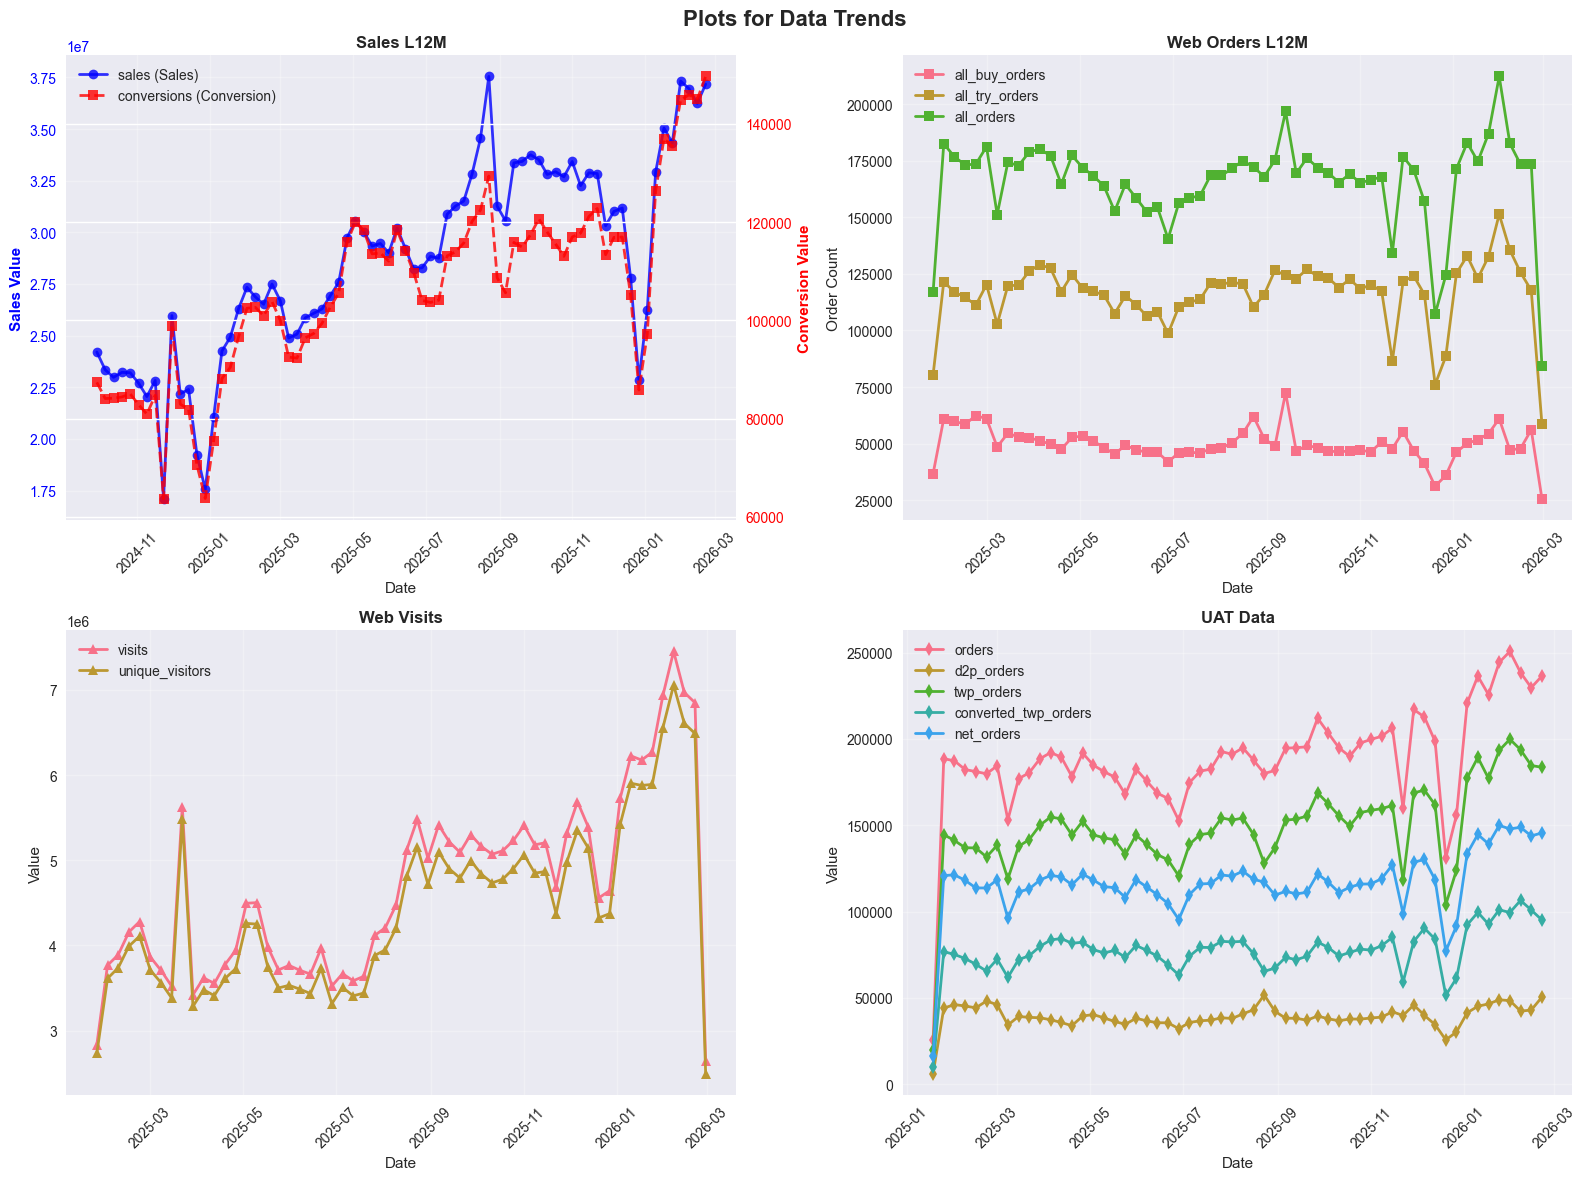

In [19]:
plot_data_trends(
    dataset1=us_wkly_sales_l12m[us_wkly_sales_l12m.cc_segment.isin(dme)].groupby(['date','geo'])[['sales','conversions']].sum().reset_index(),
    dataset2=us_wkly_web_orders_l12m,
    dataset3=us_wkly_web_visits_l12m,
    dataset4=us_wkly_uat_mmt_conv,
    title1='Sales L12M',
    title2='Web Orders L12M',
    title3='Web Visits',
    title4='UAT Data',
    cols_dataset2=['all_buy_orders', 'all_try_orders', 'all_orders'])

In [20]:
# #Logging raw data with ML flow for reproducibility
# import uuid

# # Start main run for data loading
# mlflow.start_run(run_name=f"geox_readout_{uuid.uuid4().hex[:8]}")
    
# # Log data parameters
# mlflow.log_param("data_size", len(us_sales_l12m))
# mlflow.log_param("total_sales", us_sales_l12m.sales.sum().round())
# mlflow.log_param("total_conversions", us_sales_l12m.conversions.sum().round())
# mlflow.log_param("date_range_start", str(us_sales_l12m.date.min()))
# mlflow.log_param("date_range_end", str(us_sales_l12m.date.max()))

# # # Log the file as an artifact
# # us_sales_l12m.to_csv("us_sales_l12m_full.csv", index=False)
# # mlflow.log_artifact(local_path="us_sales_l12m_full.csv", artifact_path="raw_data")

# # # Log web orders data
# # us_web_orders_l12m.to_csv("us_web_orders_l12m.csv", index=False)
# # mlflow.log_artifact(local_path="us_web_orders_l12m.csv", artifact_path="raw_data")

# # # Log web visits data
# # us_web_visits_l12m.to_csv("us_web_visits_l12m.csv", index=False)
# # mlflow.log_artifact(local_path="us_web_visits_l12m.csv", artifact_path="raw_data")

# # print(f"Logged entire dataset with {len(us_sales_l12m)} rows")

# # End the data loading run
# mlflow.end_run()


In [21]:
weekly = [False, True][1]

if weekly: 
    orders = us_wkly_web_orders_l12m
    sales = us_wkly_sales_l12m
    visits = us_wkly_web_visits_l12m
else: 
    orders = us_web_orders_l12m
    sales = us_sales_l12m
    visits = us_web_visits_l12m

# Orders dara grouped by sub-segments
us_dme_web_orders_l12m = orders[['date', 'geo', 'dme_all_orders']]
us_dme_web_buy_orders_l12m = orders[['date', 'geo', 'dme_buy_orders']]
us_dme_web_try_orders_l12m = orders[['date', 'geo', 'dme_try_orders']]

us_cc_web_orders_l12m = orders[['date', 'geo', 'cc_all_orders']]
us_cc_web_buy_orders_l12m = orders[['date', 'geo', 'cc_buy_orders']]
us_cc_web_try_orders_l12m = orders[['date', 'geo', 'cc_try_orders']]

us_dc_web_orders_l12m = orders[['date', 'geo', 'dc_all_orders']]
us_dc_web_buy_orders_l12m = orders[['date', 'geo', 'dc_buy_orders']]
us_dc_web_try_orders_l12m = orders[['date', 'geo', 'dc_try_orders']]


# Sale data grouped by sub-segments
us_dme_sales_l12m = sales[sales.cc_segment.isin(dme)].groupby(['date','geo'])[['sales','conversions']].sum().reset_index()
us_dc_sales_l12m = sales[sales.cc_segment.isin(dc)].groupby(['date','geo'])[['sales','conversions']].sum().reset_index()
us_cc_sales_l12m = sales[sales.cc_segment.isin(cc)].groupby(['date','geo'])[['sales','conversions']].sum().reset_index()
us_ste_sales_l12m = sales[sales.cc_segment.isin(['STUDENT'])].groupby(['date','geo'])[['sales','conversions']].sum().reset_index()
us_photo_sales_l12m = sales[sales.cc_segment.isin(['PHOTOGRAPHY'])].groupby(['date','geo'])[['sales','conversions']].sum().reset_index()
us_indv_sales_l12m = sales[sales.cc_segment.isin(['INDIVIDUAL'])].groupby(['date','geo'])[['sales','conversions']].sum().reset_index()
us_di_sales_l12m = sales[sales.di_y_n == 'Y'].groupby(['date','geo'])[['sales','conversions']].sum().reset_index()
us_video_sales_l12m = sales[sales.video_y_n == 'Y'].groupby(['date','geo'])[['sales','conversions']].sum().reset_index()

print(f'dme: {us_dme_sales_l12m.shape}, dc: {us_dc_sales_l12m.shape}, cc: {us_cc_sales_l12m.shape}, ste: {us_ste_sales_l12m.shape}, photo: {us_photo_sales_l12m.shape}, indv: {us_indv_sales_l12m.shape}, di: {us_di_sales_l12m.shape}, video: {us_video_sales_l12m.shape}')

dme: (15517, 4), dc: (15495, 4), cc: (15472, 4), ste: (14623, 4), photo: (15106, 4), indv: (15419, 4), di: (15325, 4), video: (13967, 4)


In [22]:
print(f'dme: {us_dme_sales_l12m.sales.sum().round()}, dc: {us_dc_sales_l12m.sales.sum().round()}, cc: {us_cc_sales_l12m.sales.sum().round()}, ste: {us_ste_sales_l12m.sales.sum().round()}, photo: {us_photo_sales_l12m.sales.sum().round()}, indv: {us_indv_sales_l12m.sales.sum().round()}, di: {us_di_sales_l12m.sales.sum().round()}, video: {us_video_sales_l12m.sales.sum().round()}')

dme: 2118551399.0, dc: 1142327018.0, cc: 976224381.0, ste: 114866274.0, photo: 92568308.0, indv: 575286317.0, di: 230971686.0, video: 81645416.0


In [23]:
# Calculate net conversions (Trail converts): conversions - buy_orders (clipped at 0 to avoid negatives)

# DME
us_dme_net_conversions = pd.merge(us_dme_sales_l12m, us_dme_web_buy_orders_l12m, on=['date', 'geo'], how='left')
us_dme_net_conversions['dme_buy_orders'] = us_dme_net_conversions['dme_buy_orders'].fillna(0)
us_dme_net_conversions['try_conversions'] = (us_dme_net_conversions['conversions'] - us_dme_net_conversions['dme_buy_orders']).clip(lower=0)
us_dme_net_conversions = us_dme_net_conversions[['date', 'geo', 'try_conversions']]

# CC
us_cc_net_conversions = pd.merge(us_cc_sales_l12m, us_cc_web_buy_orders_l12m, on=['date', 'geo'], how='left')
us_cc_net_conversions['cc_buy_orders'] = us_cc_net_conversions['cc_buy_orders'].fillna(0)
us_cc_net_conversions['try_conversions'] = (us_cc_net_conversions['conversions'] - us_cc_net_conversions['cc_buy_orders']).clip(lower=0)
us_cc_net_conversions = us_cc_net_conversions[['date', 'geo', 'try_conversions']]

# DC
us_dc_net_conversions = pd.merge(us_dc_sales_l12m, us_dc_web_buy_orders_l12m, on=['date', 'geo'], how='left')
us_dc_net_conversions['dc_buy_orders'] = us_dc_net_conversions['dc_buy_orders'].fillna(0)
us_dc_net_conversions['try_conversions'] = (us_dc_net_conversions['conversions'] - us_dc_net_conversions['dc_buy_orders']).clip(lower=0)
us_dc_net_conversions = us_dc_net_conversions[['date', 'geo', 'try_conversions']]

# Run Analysis/Inference

In [ ]:
# Updated MMTAnalysis class with improved DID implementation
import builtins
import os
import mlflow
from scipy.stats import norm
import pandas as pd
import numpy as np
from typing import Dict, List, Optional, Union, Tuple, Any
import math
from dataclasses import dataclass
from builtins import round, abs, max
from panel_exp.panel_data import long_df_to_paneldataset, PanelDataset, TimePeriod
from panel_exp.methods.tbr import TBRRidge
from panel_exp.methods.DID import DID


# --- NaN-safe row formatting (TROP + any estimator with missing inference) ---
def _mmt_is_missing(v: Any) -> bool:
    if v is None:
        return True
    if isinstance(v, float) and math.isnan(v):
        return True
    try:
        if isinstance(v, np.floating) and np.isnan(v):
            return True
    except (TypeError, ValueError):
        pass
    try:
        if pd.isna(v):
            return True
    except (TypeError, ValueError):
        pass
    return False


def _safe_round_or_none(value: Any, ndigits: int = 0) -> Optional[Union[int, float]]:
    """Row-safe rounding: None / NaN / non-finite → None; else builtins.round (avoids round(NaN) crashes)."""
    if value is None or _mmt_is_missing(value):
        return None
    try:
        x = float(value)
    except (TypeError, ValueError, OverflowError):
        return None
    if not np.isfinite(x):
        return None
    if ndigits:
        return builtins.round(float(x), ndigits)
    return builtins.round(float(x))


def _mmt_safe_round_optional(value: Any, ndigits: int = 0) -> Optional[Union[int, float]]:
    return _safe_round_or_none(value, ndigits)


def _mmt_safe_format_numeric(value: Any, ndigits: int = 0) -> Optional[Union[int, float]]:
    """Alias for row/CSV numeric fields (same as _safe_round_or_none)."""
    return _safe_round_or_none(value, ndigits)


def _mmt_ci_pair_finite(ci: Any) -> bool:
    """True if ci is a length-2 sequence with finite, non-missing endpoints (effect-space CI)."""
    if ci is None or not isinstance(ci, (list, tuple)) or len(ci) < 2:
        return False
    lo, hi = ci[0], ci[1]
    if _mmt_is_missing(lo) or _mmt_is_missing(hi):
        return False
    try:
        return bool(np.isfinite(float(lo)) and np.isfinite(float(hi)))
    except (TypeError, ValueError):
        return False


def _mmt_safe_int_optional(value: Any) -> Optional[int]:
    """Pre/post counts and diagnostic integers: None/NaN/non-finite → None."""
    r = _mmt_safe_round_optional(value, 0)
    if r is None:
        return None
    try:
        return int(r)
    except (TypeError, ValueError, OverflowError):
        return None


def _mmt_none_if_nonfinite_scalar(v: Any) -> Any:
    """For stats dict: leave arrays alone; coerce scalar NaN/inf to None."""
    if v is None or isinstance(v, (np.ndarray, list)):
        return v
    if _mmt_is_missing(v):
        return None
    try:
        x = float(v)
        return None if not math.isfinite(x) else v
    except (TypeError, ValueError):
        return None


def _mmt_is_trop_model(model: Any) -> bool:
    return type(model).__name__ == "TROP"


def _mmt_trop_inference_missing(model: Any, inf: Dict[str, Any]) -> bool:
    if not _mmt_is_trop_model(model) or not isinstance(inf, dict):
        return False
    if inf.get("is_degenerate") is True:
        return True
    sr = inf.get("selection_reason") or ""
    if isinstance(sr, str) and sr.startswith("degenerate_"):
        return True
    if inf.get("ci_invalid_effect_scale") is True:
        return True
    cc = inf.get("cumulative_ci")
    if cc is None:
        return True
    if isinstance(cc, (list, tuple)) and len(cc) >= 2:
        lo, hi = cc[0], cc[1]
        if _mmt_is_missing(lo) or _mmt_is_missing(hi):
            return True
        try:
            return not (np.isfinite(float(lo)) and np.isfinite(float(hi)))
        except (TypeError, ValueError):
            return True
    return True


@dataclass
class TestConfig:
    """Configuration for test parameters"""
    test_groups: Dict[str, List[str]]
    control_groups: Dict[str, List[str]]
    datasets: Dict[str, pd.DataFrame]
    kpi: Dict[str, str]
    test_start_dates: Dict[str, str]
    test_end_dates: Dict[str, str]
    aggregation: str


class MMTAnalysis:
    """Class to handle MMT analysis with all its components"""
    
    def __init__(
        self,
        test_groups: Dict[str, List[str]],
        control_groups: Dict[str, List[str]],
        datasets: Dict[str, pd.DataFrame],
        kpi: Dict[str, str],
        test_start_dates: Dict[str, str],
        test_end_dates: Dict[str, str],

        # Optional parameters
        panel_aggregation_config: Optional[str] = 'no',
        mlflow_run_name: Optional[str] = "experiment_analysis",
        alpha: Optional[float] = 0.1,
        inference: Optional[str] = 'Kfold',
        model_selection: Optional[str] = None,  # e.g. 'TBRRidge', 'AugSynthCVXPY', 'DID'. If None, uses 'TBRRidge'.
        skip_pre_test_r2: Optional[bool] = False,  # if True, skip slow pre-test forward OOS R²
        # BRB (BlockResidualBootstrap) options; passed through to run_analysis when inference=BlockResidualBootstrap
        refit_in_bootstrap: Optional[bool] = False,
        refit_mode: Optional[str] = "post_only",  # "post_only" | "pre_bootstrap"
        ci_method: Optional[str] = "bca",  # "percentile" | "bca"
        bootstrap_type: Optional[str] = "block",  # "block" | "wild"
        block_length: Optional[int] = 7,  # BRB moving-block length
    ):
        """Initialize MMT analysis with all configurations"""
        self.config = TestConfig(
            test_groups=test_groups,
            control_groups=control_groups,
            datasets=datasets,
            kpi=kpi,
            test_start_dates=test_start_dates,
            test_end_dates=test_end_dates,
            aggregation=panel_aggregation_config
        )
        self.mlflow_run_name = mlflow_run_name
        self.alpha = alpha
        self.inference = inference
        self.default_model = model_selection if model_selection is not None else 'TBRRidge'
        self.model_selection = self._setup_model_selection()
        self.skip_pre_test_r2 = skip_pre_test_r2
        self.refit_in_bootstrap = refit_in_bootstrap
        self.refit_mode = refit_mode
        self.ci_method = ci_method
        self.bootstrap_type = bootstrap_type
        self.block_length = block_length
        self.max_pre_length = 0
        self.max_post_length = 0
        
    def _setup_model_selection(self) -> Dict:
        """Setup model selection dictionary with proper configuration"""
        return {
            'TBR': lambda: TBR(full_model=False, inference=self.inference),
            'TBRAutoSARIMAX': lambda: TBRAutoSARIMAX(
                seasonal=False,
                seasonal_period=52,
                max_p=1,
                max_q=1,
                max_d=0,
                max_P=0,
                max_Q=0,
                max_D=0,
                information_criterion="bic",
                stepwise=True,
                trace=False,
                max_controls=5,
                exog_reduction="synthetic_ridge",
                fallback_to_ridge=True,
                retry_without_seasonality=False,
                retry_with_fewer_factors=False,
            ),           
            'DID': lambda: DID(alpha=self.alpha),  # Use improved DID with proper alpha
            'SyntheticDID': lambda: SyntheticDID(alpha=self.alpha),
            'BayesianTBR': lambda: BayesianTBR(full_model=False),
            'BayesianTBRHorseShoe': lambda: BayesianTBRHorseShoe(full_model=False),
            'TBRRidge': lambda: TBRRidge(
                full_model=False,
                inference=self.inference
            ),
            'AugSynthCVXPY': lambda: AugSynthCVXPY(
                outcome_model=Ridge,
                full_model=False,
                inference=self.inference
            ),
            'SyntheticControlCVXPY': lambda: SyntheticControlCVXPY(inference=self.inference, alpha=self.alpha),
            'Trop': lambda: TROP(
                    method="global",
                    cv_mode="global_obs",
                    inference_mode="auto",
                    alpha=0.05,
                    lambda_unit_grid=[0.1],
                    lambda_time_grid=[0.1],
                    lambda_nuclear_grid=[0.05],
                    max_cv_placebos=1,
                    cv_max_cycles=1,
                    max_iter=150,
                    tol=1e-4,
                    n_bootstrap=0,
                    verbose=False,
                )
                }
    
    def _calculate_statistics(self, model, start, end):
        # Trop: use inference_summary() for inbuilt bootstrap inference
        if hasattr(model, 'inference_summary'):
            try:
                inf = model.inference_summary()
            except Exception:
                inf = {}
            if not isinstance(inf, dict):
                inf = {}
            n_post = max(0, end - start + 1)
            if _mmt_is_trop_model(model) and _mmt_trop_inference_missing(model, inf):
                m = max(1, n_post)
                post_actual = np.full(m, np.nan)
                post_predicted = np.full(m, np.nan)
                return {
                    'post_actual': post_actual,
                    'post_predicted': post_predicted,
                    'cumulative_diff_sum': None,
                    'y_lower': None,
                    'y_upper': None,
                    'se': None,
                    'z': None,
                    'p_value': None,
                    'confidence_interval': None,
                    'has_confidence_intervals': False,
                    '_mmt_inference_snapshot': inf,
                }
            def _fg(x, default=np.nan):
                if _mmt_is_missing(x):
                    return float(default)
                try:
                    v = float(x)
                    return v if math.isfinite(v) else float('nan')
                except (TypeError, ValueError):
                    return float(default)
            obs = _fg(inf.get('observed_total'), 0.0)
            cf = _fg(inf.get('counterfactual_total'), 1.0)
            ti = inf.get('total_incremental')
            if _mmt_is_missing(ti):
                total = obs - cf if math.isfinite(obs) and math.isfinite(cf) else float('nan')
            else:
                total = _fg(ti, np.nan)
            p_val = inf.get('p_value')
            if _mmt_is_missing(p_val):
                p_val = None
            else:
                try:
                    pv = float(p_val)
                    p_val = pv if math.isfinite(pv) else None
                except (TypeError, ValueError):
                    p_val = None
            ci = inf.get('ci_percentile') or inf.get('ci_normal')
            eff_low = eff_high = None
            ci_width = None
            if ci is not None and len(ci) >= 2 and not _mmt_is_missing(ci[0]) and not _mmt_is_missing(ci[1]):
                try:
                    lo, hi = float(ci[0]), float(ci[1])
                    if math.isfinite(lo) and math.isfinite(hi):
                        eff_low, eff_high = lo, hi
                        ci_width = eff_high - eff_low
                except (TypeError, ValueError):
                    pass
            if ci_width is None:
                se_raw = inf.get('std_error')
                if not _mmt_is_missing(se_raw) and math.isfinite(float(se_raw)) and cf and math.isfinite(cf) and float(cf) != 0:
                    ci_width = 2 * 1.96 * float(se_raw) * float(cf)
                else:
                    ci_width = None
            se_out = inf.get('std_error')
            if _mmt_is_missing(se_out):
                se_out = None
            else:
                try:
                    se_f = float(se_out)
                    se_out = se_f if math.isfinite(se_f) else None
                except (TypeError, ValueError):
                    se_out = None
            if n_post <= 0:
                post_actual = np.array([])
                post_predicted = np.array([])
            else:
                post_actual = np.full(n_post, obs / n_post if n_post and math.isfinite(obs) else np.nan)
                post_predicted = np.full(n_post, cf / n_post if n_post and math.isfinite(cf) else np.nan)
            out = {
                'post_actual': post_actual,
                'post_predicted': post_predicted,
                'cumulative_diff_sum': total if math.isfinite(total) else None,
                'y_lower': eff_low,
                'y_upper': eff_high,
                'se': se_out,
                'z': None,
                'p_value': p_val,
                'confidence_interval': ci_width if ci_width is not None and math.isfinite(ci_width) else None,
                'has_confidence_intervals': eff_low is not None and eff_high is not None,
                '_mmt_inference_snapshot': inf,
            }
            for k in ('p_value', 'confidence_interval', 'y_lower', 'y_upper', 'se', 'cumulative_diff_sum'):
                if k not in out:
                    continue
                if _mmt_is_missing(out[k]):
                    out[k] = None
                else:
                    out[k] = _mmt_none_if_nonfinite_scalar(out[k])
            # TROP: never pass NaN for inference scalars to the row builder
            if _mmt_is_trop_model(model):
                for key in ('p_value', 'confidence_interval', 'y_lower', 'y_upper', 'cumulative_diff_sum', 'se'):
                    v = out.get(key)
                    if v is None:
                        continue
                    try:
                        if not np.isfinite(float(v)):
                            out[key] = None
                    except (TypeError, ValueError):
                        out[key] = None
            return out
        # Calculate basic stats that are always needed
        post_actual = model.results['y'][start:end+1]
        post_predicted = model.results['y_hat'][start:end+1]
        cumulative_diff_sum = np.sum(post_actual - post_predicted)

        # Placebo (and any estimator with test-inversion CI): use cumulative inversion bounds when available.
        # Must check before has_confidence_intervals; Placebo may set effect_ci_*_inversion without y_lower/y_upper.
        inv_lo = model.results.get('effect_ci_lower_inversion')
        inv_hi = model.results.get('effect_ci_upper_inversion')
        if (inv_lo is not None and inv_hi is not None and
            np.isfinite(inv_lo) and np.isfinite(inv_hi)):
            y_lower = float(inv_lo)
            y_upper = float(inv_hi)
            confidence_interval = y_upper - y_lower
            z_alpha = norm.ppf(1 - self.alpha / 2)
            se = (y_upper - y_lower) / (2 * z_alpha)
            se = max(float(se), 1e-10) if np.isfinite(se) else 1e-10
            z = cumulative_diff_sum / se
            p_value = 2 * norm.sf(builtins.abs(z))
            if _mmt_is_missing(p_value) or (p_value is not None and not math.isfinite(float(p_value))):
                p_value = None
            inv_out = {
                'post_actual': post_actual,
                'post_predicted': post_predicted,
                'cumulative_diff_sum': cumulative_diff_sum,
                'y_lower': y_lower,
                'y_upper': y_upper,
                'se': se,
                'z': z,
                'p_value': p_value,
                'confidence_interval': confidence_interval,
                'has_confidence_intervals': True
            }
            for k in ('p_value', 'confidence_interval', 'y_lower', 'y_upper', 'se', 'z', 'cumulative_diff_sum'):
                if k not in inv_out:
                    continue
                if _mmt_is_missing(inv_out[k]):
                    inv_out[k] = None
                else:
                    inv_out[k] = _mmt_none_if_nonfinite_scalar(inv_out[k])
            return inv_out

        # Check if model provides confidence intervals (y_lower, y_upper)
        has_confidence_intervals = ('y_lower' in model.results and 'y_upper' in model.results)
        
        # For DID/SyntheticDID single-effect: use built-in inference; cumulative bounds = n_post * CI
        if hasattr(model, 'treatment_effect') and hasattr(model, 'treatment_se'):
            n_post = end - start + 1
            se = model.treatment_se
            z = model.treatment_effect / se if se > 0 else 0
            p_value = model.treatment_pvalue
            ci_width_per_period = model.treatment_ci[1] - model.treatment_ci[0]
            confidence_interval = n_post * ci_width_per_period  # cumulative CI width (matches y_lower/y_upper)
            y_lower = n_post * model.treatment_ci[0]  # cumulative lower
            y_upper = n_post * model.treatment_ci[1]  # cumulative upper
        elif has_confidence_intervals:
            # Placebo: prefer test-inversion CI when available (CI around estimate, not null bounds)
            inv_lo = model.results.get('effect_ci_lower_inversion')
            inv_hi = model.results.get('effect_ci_upper_inversion')
            if (inv_lo is not None and inv_hi is not None and
                np.isfinite(inv_lo) and np.isfinite(inv_hi)):
                y_lower = float(inv_lo)
                y_upper = float(inv_hi)
                confidence_interval = y_upper - y_lower
            # TimeSeriesKfold: prefer direct cumulative TSK bounds (avoid summing weekly bounds)
            elif (getattr(model, 'inference', None) == 'TimeSeriesKfold' and
                  'effect_ci_lower_cumulative_tsk' in model.results and
                  'effect_ci_upper_cumulative_tsk' in model.results):
                tsk_lo = model.results['effect_ci_lower_cumulative_tsk']
                tsk_hi = model.results['effect_ci_upper_cumulative_tsk']
                if np.isfinite(tsk_lo) and np.isfinite(tsk_hi):
                    y_lower = float(tsk_lo)
                    y_upper = float(tsk_hi)
                    confidence_interval = y_upper - y_lower
                else:
                    y_lower = np.sum(model.results['y'][start:end+1] - model.results['y_lower'][start:end+1])
                    y_upper = np.sum(model.results['y'][start:end+1] - model.results['y_upper'][start:end+1])
                    confidence_interval = cumulative_diff_sum - y_lower
            # BlockResidualBootstrap: prefer direct cumulative BRB bounds (avoid summing weekly bounds)
            elif (getattr(model, 'inference', None) == 'BlockResidualBootstrap' and
                  'effect_ci_lower_cumulative_brb' in model.results and
                  'effect_ci_upper_cumulative_brb' in model.results):
                brb_lo = model.results['effect_ci_lower_cumulative_brb']
                brb_hi = model.results['effect_ci_upper_cumulative_brb']
                if np.isfinite(brb_lo) and np.isfinite(brb_hi):
                    y_lower = float(brb_lo)
                    y_upper = float(brb_hi)
                    confidence_interval = y_upper - y_lower
                else:
                    y_lower = np.sum(model.results['y'][start:end+1] - model.results['y_lower'][start:end+1])
                    y_upper = np.sum(model.results['y'][start:end+1] - model.results['y_upper'][start:end+1])
                    confidence_interval = cumulative_diff_sum - y_lower
            else:
                # Standard path: use y_lower, y_upper from results (sum of weekly bounds)
                y_lower = np.sum(model.results['y'][start:end+1] - model.results['y_lower'][start:end+1])
                y_upper = np.sum(model.results['y'][start:end+1] - model.results['y_upper'][start:end+1])
                confidence_interval = cumulative_diff_sum - y_lower
            z_alpha = norm.ppf(1 - self.alpha / 2)
            se = (y_upper - y_lower) / (2 * z_alpha)
            se = max(float(se), 1e-10) if np.isfinite(se) else 1e-10
            z = cumulative_diff_sum / se
            p_value = 2 * norm.sf(builtins.abs(z))
        else:
            # For models without confidence intervals, set these to None
            y_lower = None
            y_upper = None
            se = None
            z = None
            p_value = None
            confidence_interval = None

        out = {
            'post_actual': post_actual,
            'post_predicted': post_predicted,
            'cumulative_diff_sum': cumulative_diff_sum,
            'y_lower': y_lower,
            'y_upper': y_upper,
            'se': se,
            'z': z,
            'p_value': p_value,
            'confidence_interval': confidence_interval,
            'has_confidence_intervals': has_confidence_intervals,
        }
        for k in ('p_value', 'confidence_interval', 'y_lower', 'y_upper', 'se', 'z', 'cumulative_diff_sum'):
            if k not in out:
                continue
            if _mmt_is_missing(out[k]):
                out[k] = None
            else:
                out[k] = _mmt_none_if_nonfinite_scalar(out[k])
        return out
    
    # calculate pre-test R² using forward CV and out-of-sample
    def _pre_test_forward_cv_r2(
        self,
        panel_dataset,
        model,
        test,
        control,
        pre_test_times,
        pre_test_actual,
        min_train_periods: int = 5,
        block_size: int = 2,
        control_matrix=None,
        treated_series=None,
        treated_sum_series=None,
    ) -> Tuple[Optional[float], Optional[float], int, Optional[bool]]:
        """Block-based forward OOS: train on 1..train_end, predict block [train_end+1, train_end+block_size].
        Sequential; no future data in training. Returns (r2_oos, None, n_oos, overfitting_flag); no adjusted R² for OOS (equals R² by definition)."""
        try:
            if model.__class__.__name__ == "TROP":
                return (None, None, 0, None)
            if getattr(model, 'inference', None) == 'Bayesian':
                return (None, None, 0, None)
            if self.config.aggregation == 'none':
                return (None, None, 0, None)
            is_did = model.__class__.__name__ == "DID"
            if not is_did and not (hasattr(model, 'run_analysis') and hasattr(model, 'model') and callable(getattr(model.model, 'predict', None))):
                return (None, None, 0, None)
            n_pre = len(pre_test_times)
            if n_pre < min_train_periods + block_size:
                return (None, None, 0, None)

            # Use cached objects when provided; otherwise compute
            if control_matrix is None:
                control_matrix = panel_dataset.wide_data.loc[control]
            if treated_series is None:
                treated_series = panel_dataset.wide_data.loc[test]
            if treated_sum_series is None:
                treated_sum_series = treated_series.sum(axis=0)

            if self.config.aggregation == 'yes':
                control_units = pd.DataFrame(control_matrix.sum(axis=0), columns=['control'])
                treated_units = pd.DataFrame(treated_sum_series, columns=['treated'])
                wide_agg = pd.concat([treated_units, control_units], axis=1)
            else:
                control_units = control_matrix
                treated_units = pd.DataFrame(treated_sum_series, columns=['treated'])
                wide_agg = pd.concat([treated_units.T, control_units], axis=0)

            actuals, preds = [], []
            train_end = min_train_periods

            while train_end + block_size <= n_pre:
                block_pre_times = pre_test_times[:train_end]
                if self.config.aggregation == 'yes':
                    wide_sub = wide_agg.iloc[:train_end, :].T.copy()
                else:
                    wide_sub = wide_agg.iloc[:, :train_end].copy()
                treat_start_date = pre_test_times[train_end]
                wide_sub[treat_start_date] = 0.0
                treated_periods = [TimePeriod(treat_start_date, treat_start_date)]
                pds_sub = PanelDataset(wide_sub, treated_units=['treated'], treated_periods=treated_periods)
                model_cv = self.model_selection[self.default_model]()
                model_cv.run_analysis(pds_sub)

                if is_did:
                    # DID: use formula treated_pre_mean + (control_at_t - control_pre_mean)
                    pre_mask = model_cv._agg_by_time['time_unit'].isin(block_pre_times)
                    treated_pre_mean = model_cv._agg_by_time.loc[pre_mask, 'y'].mean()
                    control_pre_mean = control_matrix.loc[:, block_pre_times].sum(axis=0).mean()
                    for t in range(train_end, train_end + block_size):
                        control_at_t = control_matrix.loc[:, pre_test_times[t]].sum()
                        pred_t = treated_pre_mean + (control_at_t - control_pre_mean)
                        actuals.append(pre_test_actual[t])
                        preds.append(pred_t)
                else:
                    # Non-DID: use model.predict
                    for t in range(train_end, train_end + block_size):
                        control_at_t = control_matrix.loc[:, pre_test_times[t]]
                        if self.config.aggregation == 'yes':
                            control_at_t = control_at_t.sum()
                            control_at_t = np.array([[control_at_t]])
                        else:
                            control_at_t = control_at_t.values.reshape(1, -1)
                        pred_t = np.asarray(model_cv.model.predict(control_at_t)).ravel()[0]
                        actuals.append(pre_test_actual[t])
                        preds.append(pred_t)
                train_end += block_size

            if len(actuals) == 0:
                return (None, None, 0, None)
            actuals = np.array(actuals)
            preds = np.array(preds)
            n_oos = len(actuals)
            ss_res = np.sum((actuals - preds) ** 2)
            ss_tot = np.sum((actuals - np.mean(pre_test_actual)) ** 2)
            if ss_tot <= 0:
                r2_oos = 0.0
            else:
                r2_oos = 1 - (ss_res / ss_tot)
            overfitting_flag_cv = n_oos < 10
            return (r2_oos, None, n_oos, overfitting_flag_cv)
        except Exception as e:
            import warnings
            warnings.warn(f"Pre-test CV R² failed: {e}", UserWarning)
            return (None, None, 0, None)
    
    def _process_aggregation(
        self, panel_dataset, test, control, test_start_date, test_end_date,
        test_group, d, k, fltrd_df
    ) -> Dict:
        """Process aggregation based on mode: 'no' (default), 'yes', or 'none'"""
        # Cache raw slices before aggregation branching (optimization)
        control_matrix = panel_dataset.wide_data.loc[control]
        treated_series = panel_dataset.wide_data.loc[test]
        treated_sum_series = treated_series.sum(axis=0)

        if self.config.aggregation == 'yes':
            # Aggregate both control and test units
            control_units = pd.DataFrame(control_matrix.sum(axis=0), columns=['control'])
            treated_units = pd.DataFrame(treated_sum_series, columns=['treated'])
            wide_agg = pd.concat([treated_units, control_units], axis=1)
            pds = PanelDataset(wide_agg.T, treated_units=['treated'],
                            treated_periods=[TimePeriod(test_start_date, test_end_date)])
        elif self.config.aggregation == 'none':
            # No aggregation for either test or control
            control_units = control_matrix
            treated_units = treated_series
            wide_agg = pd.concat([treated_units, control_units], axis=0)
            pds = PanelDataset(wide_agg, treated_units=test,
                            treated_periods=[TimePeriod(test_start_date, test_end_date)] * len(test))
        else:  # 'no' - default, only test units aggregated
            control_units = control_matrix
            treated_units = pd.DataFrame(treated_sum_series, columns=['treated'])
            wide_agg = pd.concat([treated_units.T, control_units], axis=0)
            pds = PanelDataset(wide_agg, treated_units=['treated'],
                            treated_periods=[TimePeriod(test_start_date, test_end_date)])

        # Run analysis for post-test period first (model chosen via config model_selection)
        model = self.model_selection[self.default_model]()
        
        # Pass parameters in run_analysis (BRB options when inference=BlockResidualBootstrap)
        inference_kwargs = {}
        if getattr(self, 'inference', None) == 'BlockResidualBootstrap':
            inference_kwargs = {
                'refit_in_bootstrap': getattr(self, 'refit_in_bootstrap', False),
                'refit_mode': getattr(self, 'refit_mode', 'post_only'),
                'ci_method': getattr(self, 'ci_method', 'percentile'),
                'bootstrap_type': getattr(self, 'bootstrap_type', 'block'),
                'block_length': getattr(self, 'block_length', 7),
            }
        model.run_analysis(pds, **inference_kwargs)
        
        df = model.summary()  # Use the improved summary method

        # Get post-test indices (panel_data or panel for minimal DID)
        pdata = getattr(model, 'panel_data', None) or getattr(model, 'panel', None)
        if pdata is None:
            start_idx, end_idx = 0, -1
        else:
            start_idx = pdata.treated_start_idxs[0]
            end_idx = pdata.treated_end_idxs[0]
        n_post = max(0, end_idx - start_idx + 1)
        if model.__class__.__name__ == "DID":
            print(f"n_post (computed): {n_post} (start_idx={start_idx}, end_idx={end_idx})")
            # DID: require diagnostics before any row construction; no fallback
            if not hasattr(model, 'get_detailed_results'):
                print("DID diagnostics missing — skipping row construction (no get_detailed_results)")
                return (None, pd.DataFrame())
            did_results = model.get_detailed_results()
            cum_ci = did_results.get('cumulative_ci') or did_results.get('treatment_ci_aggregate') or did_results.get('treatment_ci')
            if cum_ci is None or not (isinstance(cum_ci, (list, tuple)) and len(cum_ci) >= 2):
                print(f"DID diagnostics missing — skipping row construction (cumulative_ci={cum_ci})")
                return (None, pd.DataFrame())
            if n_post <= 0:
                print(f"DID diagnostics missing — skipping row construction (n_post={n_post})")
                return (None, pd.DataFrame())
            # Save DID diagnostics: path-based cumulative_att, cumulative_ci, p_value, etc.
            import json
            out_dir = getattr(self, 'base_output_dir', None) or os.getcwd()
            diag_out = {
                'cumulative_att': did_results.get('cumulative_att'),
                'mean_post_period_att': did_results.get('mean_post_period_att'),
                'cumulative_ci': [float(cum_ci[0]), float(cum_ci[1])],
                'treatment_ci_aggregate': [float(cum_ci[0]), float(cum_ci[1])],
                'treatment_ci': [float(cum_ci[0]), float(cum_ci[1])],
                'n_post': n_post,
            }
            for k in ('parallel_trends_test', 'placebo_test', 'p_value', 'primary_inference_method', 'significant'):
                v = did_results.get(k)
                if v is not None:
                    if isinstance(v, dict):
                        diag_out[k] = {kk: (float(vv) if isinstance(vv, (int, float)) or (hasattr(vv, 'item') and callable(getattr(vv, 'item'))) else vv) for kk, vv in v.items()}
                    else:
                        diag_out[k] = float(v) if isinstance(v, (int, float)) else v
            diag_path = os.path.join(out_dir, 'self_DID_did_diagnostics.json')
            try:
                with open(diag_path, 'w') as f:
                    json.dump(diag_out, f, indent=2, default=str)
            except Exception as e:
                print(f"Warning: could not save DID diagnostics to {diag_path}: {e}")
        
        # === TROP DEBUG (Phases 1-3, 2, 6): targeted diagnostics ===
        has_trop_inference = hasattr(model, 'inference_summary')
        if has_trop_inference:
            print("[DEBUG] Model identity:", type(model).__name__, "| method:", getattr(model, 'method', '?'), "| cv_mode:", getattr(model, 'cv_mode', '?'))
            res = getattr(model, 'results', {})
            print("[DEBUG] model.results keys:", list(res.keys()) if res else "None")
            y_sl = np.asarray(res.get('y', [])[start_idx:end_idx+1])
            yh_sl = np.asarray(res.get('y_hat', [])[start_idx:end_idx+1])
            if y_sl.ndim > 1:
                y_sum = np.sum(y_sl, axis=1) if y_sl.shape[1] > 1 else y_sl.ravel()
                yh_sum = np.sum(yh_sl, axis=1) if yh_sl.shape[1] > 1 else yh_sl.ravel()
            else:
                y_sum, yh_sum = np.sum(y_sl), np.sum(yh_sl)
            print("[DEBUG] post sum(y):", np.sum(y_sum), "| post sum(y_hat):", np.sum(yh_sum))
            te = res.get('treatment_effects')
            if te is not None:
                te_sl = np.asarray(te[start_idx:end_idx+1])
                te_sum = np.sum(te_sl) if te_sl.ndim <= 1 else np.sum(np.sum(te_sl, axis=1))
                print("[DEBUG] post sum(treatment_effects):", te_sum)
            else:
                print("[DEBUG] post sum(y - y_hat):", np.sum(y_sum) - np.sum(yh_sum))
            print("[DEBUG] y_lower exists:", 'y_lower' in res, "| y_upper exists:", 'y_upper' in res)
            if 'y_lower' in res and 'y_upper' in res:
                yl = np.asarray(res['y_lower'][start_idx:end_idx+1])
                yu = np.asarray(res['y_upper'][start_idx:end_idx+1])
                yl_sum = np.sum(np.sum(yl, axis=1)) if yl.ndim > 1 else np.sum(yl)
                yu_sum = np.sum(np.sum(yu, axis=1)) if yu.ndim > 1 else np.sum(yu)
                print("[DEBUG] post sum(y_lower):", yl_sum, "| post sum(y_upper):", yu_sum)
            inf = model.inference_summary()
            print("[DEBUG] inference_summary keys:", list(inf.keys()))
            for k in ['observed_total','counterfactual_total','total_incremental','relative_lift','p_value','std_error','ci_percentile','ci_normal','estimation_method','inference_method']:
                print(f"  {k}: {inf.get(k)}")
            obs, cf = float(inf.get('observed_total',0)), float(inf.get('counterfactual_total',1))
            inc = float(inf.get('total_incremental',0))
            rel = inf.get('relative_lift')
            manual_rel = (obs - cf) / cf if cf and np.isfinite(cf) else np.nan
            print("[DEBUG] obs:", obs, "| cf:", cf, "| obs-cf:", obs-cf, "| total_incremental:", inc, "| relative_lift:", rel, "| manual_rel:", manual_rel)
            if not np.isclose(inc, obs - cf, rtol=1e-5, atol=1e-8):
                print("[DEBUG WARN] total_incremental != observed_total - counterfactual_total")
            if rel is not None and np.isfinite(manual_rel) and not np.isclose(float(rel), manual_rel, rtol=1e-5, atol=1e-8):
                print("[DEBUG WARN] relative_lift != manual (obs-cf)/cf")
            if cf <= 0 or not np.isfinite(cf):
                print("[DEBUG] *** Invalid TROP counterfactual_total: non-positive or non-finite value ***")
        
        # Trop: build rdf from inference_summary if model.results missing required keys
        if has_trop_inference and (not hasattr(model, 'results') or 'y' not in getattr(model, 'results', {})):
            inf = model.inference_summary()
            n_post = end_idx - start_idx + 1
            times = panel_dataset.times[start_idx:end_idx+1]
            obs, cf = float(inf.get('observed_total', 0)), float(inf.get('counterfactual_total', 1))
            eff_per = float(inf.get('total_incremental', 0)) / n_post if n_post else 0
            rdf_data = {'dt': times, 'y': np.full(n_post, obs/n_post), 'y_hat': np.full(n_post, cf/n_post), 'effect': np.full(n_post, eff_per)}
            ci = inf.get('ci_percentile') or inf.get('ci_normal')
            if ci and len(ci) >= 2:
                # ate ci = (low, high); counterfactual bounds: cf_lo = obs - cf*high, cf_hi = obs - cf*low
                cf_lo = obs - cf * float(ci[1])
                cf_hi = obs - cf * float(ci[0])
                rdf_data['y_lower'] = np.full(n_post, cf_lo / n_post)
                rdf_data['y_upper'] = np.full(n_post, cf_hi / n_post)
            else:
                rdf_data['y_lower'] = rdf_data['y_upper'] = None
        else:
            # Create rdf DataFrame from model results (post-test period only)
            y_slice = np.asarray(model.results['y'][start_idx:end_idx+1])
            yhat_slice = np.asarray(model.results['y_hat'][start_idx:end_idx+1])
            eff_slice = model.results['treatment_effects'][start_idx:end_idx+1] if 'treatment_effects' in model.results else (y_slice - yhat_slice)
            # Aggregate over units when multi-unit (e.g. AugSynthCVXPY/SCM + BRB with unaggregated treated)
            if y_slice.ndim > 1 and y_slice.shape[1] > 1:
                y_slice = np.sum(y_slice, axis=1)
                yhat_slice = np.sum(yhat_slice, axis=1)
                eff_slice = np.sum(np.asarray(eff_slice), axis=1)
            rdf_data = {
                'dt': model.results['times'][start_idx:end_idx+1],  
                'y': np.asarray(y_slice).ravel(),       
                'y_hat': np.asarray(yhat_slice).ravel(), 
                'effect': np.asarray(eff_slice).ravel()
            }
            if hasattr(model, 'treatment_effect') and hasattr(model, 'treatment_ci'):
                y_post = np.asarray(y_slice).ravel()
                rdf_data['y_lower'] = y_post - model.treatment_ci[1]  # counterfactual lower
                rdf_data['y_upper'] = y_post - model.treatment_ci[0]  # counterfactual upper
            elif 'y_lower' in model.results and 'y_upper' in model.results:
                yl = np.asarray(model.results['y_lower'][start_idx:end_idx+1])
                yu = np.asarray(model.results['y_upper'][start_idx:end_idx+1])
                if yl.ndim > 1 and yl.shape[1] > 1:
                    yl = np.sum(yl, axis=1)
                    yu = np.sum(yu, axis=1)
                rdf_data['y_lower'] = yl.ravel()
                rdf_data['y_upper'] = yu.ravel()
            else:
                if hasattr(model, 'treatment_ci'):
                    ci_width = model.treatment_ci[1] - model.treatment_ci[0]
                    y_hat = np.asarray(model.results['y_hat'][start_idx:end_idx+1]).ravel()
                    rdf_data['y_lower'] = y_hat - ci_width/2
                    rdf_data['y_upper'] = y_hat + ci_width/2
                else:
                    rdf_data['y_lower'] = None
                    rdf_data['y_upper'] = None
        rdf = pd.DataFrame(rdf_data)
        rdf['dt'] = pd.to_datetime(rdf['dt'])
        
        # Calculate statistics for post-test period
        stats = self._calculate_statistics(model, start_idx, end_idx)
        inf_snap = stats.pop("_mmt_inference_snapshot", None)
        if not isinstance(inf_snap, dict):
            inf_snap = {}
        if has_trop_inference and _mmt_is_trop_model(model) and not inf_snap:
            try:
                inf_snap = model.inference_summary()
            except Exception:
                inf_snap = {}
        trop_skip = bool(
            has_trop_inference and _mmt_is_trop_model(model) and _mmt_trop_inference_missing(model, inf_snap)
        )
        if trop_skip:
            stats["p_value"] = None
            stats["confidence_interval"] = None
            stats["y_lower"] = None
            stats["y_upper"] = None
            stats["se"] = None

        # Now reuse the fitted model's predict function on pre-test data
        # Use explicit pre-period times (never label slicing)
        pre_test_times = panel_dataset.times[:start_idx]
        pre_test_control_data = control_matrix.loc[:, pre_test_times]
        pre_test_actual = treated_series.loc[:, pre_test_times].sum(axis=0).values
        if hasattr(model, 'get_pre_test_counterfactual'):
            # pre_test_actual = sum over treated units; use aggregate='sum' (default)
            pre_test_counterfactual = model.get_pre_test_counterfactual(pre_test_times)
        else:
            # For other models (TBRRidge, etc.), use the existing logic
            is_bayesian = hasattr(model.model, "posterior_samples") or "bayesian" in str(type(model.model)).lower()

            if self.config.aggregation == 'yes':
                pre_test_control_features = pre_test_control_data.sum(axis=0).values

                # Only convert to array for Bayesian models
                if is_bayesian:
                    input_data = pre_test_control_features.reshape(-1, 1)
                    predictions = model.model.predict(input_data)
                    pre_test_counterfactual = np.mean(predictions, axis=0)
                else:
                    input_data = pre_test_control_features.reshape(-1, 1)
                    pre_test_counterfactual = model.model.predict(input_data)  

            else:
                # For non-aggregated case
                if is_bayesian:
                    # Convert DataFrame to numpy array for Bayesian
                    if isinstance(pre_test_control_data, pd.DataFrame):
                        input_data = pre_test_control_data.values.T
                    else:
                        input_data = np.asarray(pre_test_control_data).T

                    predictions = model.model.predict(input_data)
                    pre_test_counterfactual = np.mean(predictions, axis=0)
                else:
                    input_data = pre_test_control_data.T
                    pre_test_counterfactual = model.model.predict(input_data)
                    if isinstance(pre_test_counterfactual, pd.Series):
                        pre_test_counterfactual = pre_test_counterfactual.values
        
        # Normalize to 1D for all models (AugSynthCVXPY returns (n,1), TBRRidge/DID return (n,), etc.)
        pre_test_counterfactual = np.asarray(pre_test_counterfactual).ravel()
        pre_test_effects = pre_test_actual - pre_test_counterfactual
        n_pre = len(pre_test_times)
        
        # Same-length y_lower/y_upper so concat with rdf never coerces scalar vs array (works for any model)
        pre_test_rdf = pd.DataFrame({
            'dt': pre_test_times,
            'y': pre_test_actual,
            'y_hat': pre_test_counterfactual,
            'effect': pre_test_effects,
            'y_lower': np.full(n_pre, np.nan),
            'y_upper': np.full(n_pre, np.nan)
        })
        pre_test_rdf['dt'] = pd.to_datetime(pre_test_rdf['dt'])
        
        # Combine pre-test and post-test results
        combined_rdf = pd.concat([pre_test_rdf, rdf], ignore_index=True)
        combined_rdf = combined_rdf.sort_values('dt').reset_index(drop=True)
        
        # Prepare results
        row = {
            "Test_Group": test_group,
            "Cloud": d,
            "KPI": k,
            "model": model,
            "start": start_idx,
            "end": end_idx
        }
        
        # Add effects and statistics
        n_post = end_idx - start_idx + 1
        # Trop: use inference_summary for abs/rel
        if has_trop_inference:
            inf = inf_snap if inf_snap else model.inference_summary()
            if trop_skip:
                abs_effect = None
                rel_effect = None
                ci_for_row = None
                sig_threshold = None
            else:
                abs_effect = inf.get('total_incremental', 0)
                try:
                    abs_effect = float(abs_effect) if not _mmt_is_missing(abs_effect) else None
                    if abs_effect is not None and not math.isfinite(abs_effect):
                        abs_effect = None
                except (TypeError, ValueError):
                    abs_effect = None
                rel_lift = inf.get('relative_lift')
                cf_tot = inf.get('counterfactual_total')
                if rel_lift is not None and not _mmt_is_missing(rel_lift):
                    try:
                        rel_effect = float(rel_lift) * 100 if math.isfinite(float(rel_lift)) else None
                    except (TypeError, ValueError):
                        rel_effect = None
                elif abs_effect is not None and cf_tot and not _mmt_is_missing(cf_tot):
                    try:
                        cff = float(cf_tot)
                        rel_effect = (abs_effect / cff * 100) if math.isfinite(cff) and cff != 0 else None
                    except (TypeError, ValueError):
                        rel_effect = None
                else:
                    rel_effect = None
                ci_for_row = stats.get('confidence_interval')
                if ci_for_row is not None:
                    try:
                        if _mmt_is_missing(ci_for_row) or not math.isfinite(float(ci_for_row)):
                            ci_for_row = None
                    except (TypeError, ValueError):
                        ci_for_row = None
                sig_threshold = ci_for_row
        # DID: path-based primary (cumulative_att, cumulative_ci, p_value from post-period effect path).
        elif (is_single_effect := hasattr(model, 'treatment_effect') and hasattr(model, 'treatment_se')) and "Average" in df.columns:
            if model.__class__.__name__ == "DID":
                # --- FIXED: use consistent source of truth (did_results) ---
                post_mask_rdf = combined_rdf['dt'] >= pd.to_datetime(test_start_date)
                n_post = int(post_mask_rdf.sum())

                if n_post == 0:
                    print("[DID ERROR] n_post=0 — skipping row creation")
                    return (None, combined_rdf)

                # Always trust diagnostics output (already path-consistent)
                cumulative_att = did_results.get('cumulative_att')
                mean_att = did_results.get('mean_post_period_att')

                if cumulative_att is None:
                    print("[DID ERROR] Missing cumulative_att in diagnostics — skipping")
                    return (None, combined_rdf)

                abs_effect = float(cumulative_att)

                # --- CI handling (NO rescaling, already cumulative) ---
                cum_ci = did_results.get('cumulative_ci') or did_results.get('treatment_ci_aggregate') or did_results.get('treatment_ci')

                if cum_ci is None or not (isinstance(cum_ci, (list, tuple)) and len(cum_ci) >= 2):
                    print("[DID ERROR] Missing CI from diagnostics — Effect Lower/Upper/95 CI set to None")
                    row["Effect Lower"] = None
                    row["Effect Upper"] = None
                    ci_for_row = None
                else:
                    cumulative_lb, cumulative_ub = float(cum_ci[0]), float(cum_ci[1])
                    ci_for_row = cumulative_ub - cumulative_lb

                    row["Effect Lower"] = _safe_round_or_none(cumulative_lb, 0)
                    row["Effect Upper"] = _safe_round_or_none(cumulative_ub, 0)
                    row["ci_scale"] = "cumulative"

                sig_threshold = (ci_for_row / 2) if ci_for_row is not None else None

                print(f"[DID FIXED] n_post={n_post} cumulative_att={abs_effect} "
                      f"cumulative_ci={cum_ci}")
            else:
                abs_effect = df.loc["Absolute Effect", "Average"]
                ci_for_row = stats['confidence_interval']
                sig_threshold = (ci_for_row / (2 * n_post)) if (ci_for_row is not None and n_post) else None
            sum_actual = float(stats['post_actual'].sum()) if stats.get('post_actual') is not None else None
            if model.__class__.__name__ == "DID" and (sum_actual is None or sum_actual == 0):
                print("DID: post_actual_sum is None or zero — skipping Relative Effect computation")
            if (
                sum_actual is not None
                and sum_actual != 0
                and abs_effect is not None
                and not _mmt_is_missing(abs_effect)
            ):
                try:
                    ae_f = float(abs_effect)
                    rel_effect = (ae_f / float(sum_actual) * 100) if math.isfinite(ae_f) else None
                except (TypeError, ValueError):
                    rel_effect = None
            else:
                rel_effect = None
        else:
            abs_effect = df.loc["Absolute Effect", "Cumulative"]
            rel_effect = df.loc["Relative Effect", "Cumulative"]
            ci_for_row = stats['confidence_interval']
            sig_threshold = ci_for_row

        if ci_for_row is not None:
            try:
                if _mmt_is_missing(ci_for_row) or not np.isfinite(float(ci_for_row)):
                    ci_for_row = None
            except (TypeError, ValueError):
                ci_for_row = None
        if sig_threshold is not None:
            try:
                if _mmt_is_missing(sig_threshold) or not np.isfinite(float(sig_threshold)):
                    sig_threshold = None
            except (TypeError, ValueError):
                sig_threshold = None

        pa_sum = stats["post_actual"].sum() if stats.get("post_actual") is not None else None
        pp_sum = stats["post_predicted"].sum() if stats.get("post_predicted") is not None else None
        if has_trop_inference and trop_skip:
            ae_disp, re_disp = None, None
        else:
            ae_disp = _safe_round_or_none(abs_effect, 0)
            re_disp = _safe_round_or_none(rel_effect, 2)
        ci_disp = None if (has_trop_inference and trop_skip) else _safe_round_or_none(ci_for_row, 0)
        pv_disp = None if (has_trop_inference and trop_skip) else _safe_round_or_none(stats.get("p_value"), 4)
        stat_sig = None
        if sig_threshold is not None and ae_disp is not None:
            st_r = _safe_round_or_none(sig_threshold, 0)
            if st_r is not None:
                stat_sig = "Yes" if abs(ae_disp) >= abs(st_r) else "No"

        if has_trop_inference and _mmt_is_trop_model(model):
            print(
                "[MMT DEBUG TROP row pre-build] ci_for_row=",
                ci_for_row,
                "effect_lower=",
                stats.get("y_lower"),
                "effect_upper=",
                stats.get("y_upper"),
                "p_value=",
                stats.get("p_value"),
            )

        row.update({
            f"actual": _safe_round_or_none(pa_sum, 0),
            f"predicted": _safe_round_or_none(pp_sum, 0),
            f"Absolute Effect": ae_disp,
            f"Relative Effect (%)": re_disp,
            f"95 CI": ci_disp,
            f"Stat. Sig. (at 90% CI)": stat_sig,
            f'p-value': pv_disp,
        })
        # Task 2: TROP - use ci_percentile/ci_normal from inference_summary directly as Effect Lower/Upper (effect-space).
        # Do not transform via counterfactual_total, post_predicted, y_lower/y_upper.
        if has_trop_inference and _mmt_is_trop_model(model):
            inf = inf_snap if inf_snap else model.inference_summary()
            if trop_skip:
                row["Effect Lower"] = None
                row["Effect Upper"] = None
                row["95 CI"] = None
                row["p-value"] = None
            else:
                ci_p = inf.get("ci_percentile")
                ci_n = inf.get("ci_normal")
                if _mmt_ci_pair_finite(ci_p):
                    row["Effect Lower"] = _safe_round_or_none(ci_p[0], 0)
                    row["Effect Upper"] = _safe_round_or_none(ci_p[1], 0)
                elif _mmt_ci_pair_finite(ci_n):
                    row["Effect Lower"] = _safe_round_or_none(ci_n[0], 0)
                    row["Effect Upper"] = _safe_round_or_none(ci_n[1], 0)
                else:
                    row["Effect Lower"] = None
                    row["Effect Upper"] = None
                if row.get("Effect Lower") is not None and row.get("Effect Upper") is not None:
                    row["95 CI"] = _safe_round_or_none(
                        float(row["Effect Upper"]) - float(row["Effect Lower"]), 0
                    )
                else:
                    row["95 CI"] = None
                row["p-value"] = _safe_round_or_none(inf.get("p_value"), 4)
        elif stats.get('y_lower') is not None and stats.get('y_upper') is not None:
            # DID: Effect Lower/Upper set above from treatment_ci_aggregate when ci_agg available; else use stats
            if model.__class__.__name__ != "DID" or "Effect Lower" not in row:
                row["Effect Lower"] = _safe_round_or_none(stats['y_lower'], 0)
                row["Effect Upper"] = _safe_round_or_none(stats['y_upper'], 0)

        if has_trop_inference and _mmt_is_trop_model(model):
            row["std_error"] = None if trop_skip else _safe_round_or_none(stats.get("se"), 4)
        else:
            row["std_error"] = _safe_round_or_none(stats.get("se"), 4)

        # BRB verification: Absolute Effect == effect_cumulative_brb, bounds from cumulative BRB, lb<=est<=ub
        if getattr(model, 'inference', None) == 'BlockResidualBootstrap' and 'effect_cumulative_brb' in model.results:
            brb_est = model.results['effect_cumulative_brb']
            brb_lo = model.results.get('effect_ci_lower_cumulative_brb', np.nan)
            brb_hi = model.results.get('effect_ci_upper_cumulative_brb', np.nan)
            rae, rlo, rhi = row.get('Absolute Effect'), row.get('Effect Lower'), row.get('Effect Upper')
            bre, brl, brh = _safe_round_or_none(brb_est, 0), _safe_round_or_none(brb_lo, 0), _safe_round_or_none(brb_hi, 0)
            ok_est = rae is not None and bre is not None and abs(float(rae) - float(bre)) <= 1
            ok_lo = rlo is not None and brl is not None and abs(float(rlo) - float(brl)) <= 1
            ok_hi = rhi is not None and brh is not None and abs(float(rhi) - float(brh)) <= 1
            ok_inv = rlo is not None and rhi is not None and rae is not None and float(rlo) <= float(rae) <= float(rhi)
            if not (ok_est and ok_lo and ok_hi and ok_inv):
                print(f"  [BRB verify] {d}: est_ok={ok_est} lo_ok={ok_lo} hi_ok={ok_hi} inv_ok={ok_inv} | row=({rae},{rlo},{rhi}) model=({bre},{brl},{brh})")

        # Collect BRB diagnostics for grid script (brb_diagnostics.jsonl)
        if getattr(self, 'inference', None) == 'BlockResidualBootstrap' and 'block_residual_bootstrap_stats' in model.results:
            brb = model.results['block_residual_bootstrap_stats']
            if not hasattr(self, '_brb_diagnostics'):
                self._brb_diagnostics = []
            self._brb_diagnostics.append({
                "dataset": d,
                "test_group": test_group,
                "brb_stats": brb,
            })

        # Calculate in-sample R-squared for pre-test period
        if len(pre_test_rdf) > 0:
            y_actual = pre_test_rdf['y'].values
            y_predicted = pre_test_rdf['y_hat'].values
            
            # Remove any NaN values
            mask = ~(np.isnan(y_actual) | np.isnan(y_predicted))
            y_actual_clean = y_actual[mask]
            y_predicted_clean = y_predicted[mask]
            
            if len(y_actual_clean) > 0:
                # Calculate R-squared
                ss_res = np.sum((y_actual_clean - y_predicted_clean) ** 2)
                ss_tot = np.sum((y_actual_clean - np.mean(y_actual_clean)) ** 2)
                
                if ss_tot == 0:
                    r_squared = 0.0
                else:
                    r_squared = 1 - (ss_res / ss_tot)
                
                # Adjusted R²: n = pre-period time points, p = number of control units (donor weights)
                n = len(y_actual_clean)
                p = pre_test_control_data.shape[0] if self.config.aggregation == 'no' else 1
                df_resid = n - p - 1
                
                if df_resid <= 0:
                    adj_r_squared = np.nan
                else:
                    adj_r_squared = 1 - ((1 - r_squared) * (n - 1) / df_resid)
                
                # Block-based forward OOS: train on 1..train_end, predict next block (sequential)
                if getattr(self, 'skip_pre_test_r2', False):
                    r2_cv, n_oos, flag_cv = None, 0, None
                else:
                    r2_cv, _, n_oos, flag_cv = self._pre_test_forward_cv_r2(
                        panel_dataset, model, test, control, pre_test_times, pre_test_actual,
                        min_train_periods=5, block_size=4,
                        control_matrix=control_matrix, treated_series=treated_series,
                        treated_sum_series=treated_sum_series
                    )
                
                row.update({
                    f"Pre-test R² (in-sample)": _safe_round_or_none(r_squared, 4),
                    f"Pre-test Adjusted R² (in-sample)": _safe_round_or_none(adj_r_squared, 4),
                    f"Pre-test observations": _mmt_safe_int_optional(len(y_actual_clean)),
                    f"Pre-test n_control": _mmt_safe_int_optional(p),
                    f"Pre-test df": _mmt_safe_int_optional(df_resid) if df_resid > 0 else None,
                    f"Pre-test R² (forward OOS)": _safe_round_or_none(r2_cv, 4),
                    f"Pre-test forward OOS n": _mmt_safe_int_optional(n_oos),
                    f"Pre-test forward OOS overfitting flag": flag_cv if flag_cv is not None else None
                })
            else:
                row.update({
                    f"Pre-test R² (in-sample)": None,
                    f"Pre-test Adjusted R² (in-sample)": None,
                    f"Pre-test observations": 0,
                    f"Pre-test n_control": None,
                    f"Pre-test df": None,
                    f"Pre-test R² (forward OOS)": None,
                    f"Pre-test forward OOS n": 0,
                    f"Pre-test forward OOS overfitting flag": None
                })
        else:
            row.update({
                f"Pre-test R² (in-sample)": None,
                f"Pre-test Adjusted R² (in-sample)": None,
                f"Pre-test observations": 0,
                f"Pre-test n_control": None,
                f"Pre-test df": None,
                f"Pre-test R² (forward OOS)": None,
                f"Pre-test forward OOS n": 0,
                f"Pre-test forward OOS overfitting flag": None
            })
        
        # Add DID/SDID-specific validation results. DID: path-based only — no regression fields.
        if hasattr(model, 'get_detailed_results'):
            did_results = model.get_detailed_results()
            pt_test = did_results.get('parallel_trends_test', {})
            pt_valid = not pt_test.get('parallel_trends_violated', True)
            _pvp = (did_results.get('placebo_test') or {}).get('placebo_pvalue')
            if _pvp is None or _mmt_is_missing(_pvp):
                _placebo_passed = None
            else:
                try:
                    _pvf = float(_pvp)
                    _placebo_passed = (_pvf >= 0.05) if np.isfinite(_pvf) else None
                except (TypeError, ValueError):
                    _placebo_passed = None
            update = {
                f"Parallel Trends Valid": pt_valid,
                f"Placebo Test Passed": _placebo_passed,
                f"Pre-trend Joint P-value": _safe_round_or_none(did_results.get('parallel_trends_joint_pvalue'), 4),
                f"Pre-trend Test Type": did_results.get('parallel_trends_test_type'),
                f"Largest Pre-trend Deviation": _safe_round_or_none(did_results.get('largest_pretrend_deviation'), 4),
                f"Largest Pre-trend Period": did_results.get('largest_pretrend_period'),
                f"Inference Method": did_results.get('primary_inference_method'),
                f"Bootstrap N": _mmt_safe_int_optional(did_results.get('bootstrap_n')),
            }
            if model.__class__.__name__ == "DID":
                # Path-based: att_per_period, p-value, Stat. Sig. from get_detailed_results
                update[f"att_per_period"] = _safe_round_or_none(did_results.get('mean_post_period_att'), 4)
                update[f"p-value"] = _safe_round_or_none(did_results.get('p_value'), 4)
                update[f"Stat. Sig. (at 90% CI)"] = "Yes" if did_results.get("significant") else "No"
            else:
                update[f"DID Treatment Effect"] = _safe_round_or_none(
                    did_results.get('treatment_effect_aggregate') or did_results.get('treatment_effect'), 4)
                update[f"DID Treatment Effect (per geo)"] = _safe_round_or_none(
                    did_results.get('treatment_effect_per_geo') or did_results.get('treatment_effect'), 4)
                _te_agg = did_results.get('treatment_effect_aggregate') or did_results.get('treatment_effect')
                update[f"att_per_period"] = (
                    _safe_round_or_none(_te_agg, 4)
                    if _te_agg is not None and model.__class__.__name__ == "SyntheticDID"
                    else None
                )
                update[f"DID Standard Error"] = _safe_round_or_none(
                    did_results.get('standard_error_aggregate') or did_results.get('standard_error'), 4)
                update[f"DID P-value"] = _safe_round_or_none(did_results.get('p_value'), 4)
                update[f"DID Significant"] = did_results['significant']
                update[f"Model-Based SE"] = _safe_round_or_none(did_results.get('model_based_se'), 4)
                update[f"Model-Based P-value"] = _safe_round_or_none(did_results.get('model_based_pvalue'), 4)
            row.update(update)
            # CSV consistency diagnostic (first dataset only) — path-based cumulative_att. Use n_post from pickle (DID block).
            if not getattr(self, '_did_csv_diagnostic_printed', False) and model.__class__.__name__ == "DID":
                ci_agg = did_results.get('treatment_ci_aggregate') or did_results.get('treatment_ci')
                cum_att = cumulative_att if np.isfinite(cumulative_att) else None
                exp_lower = (ci_agg[0] * n_post) if (ci_agg and len(ci_agg) >= 2 and n_post) else None
                exp_upper = (ci_agg[1] * n_post) if (ci_agg and len(ci_agg) >= 2 and n_post) else None
                post_sum = float(stats['post_actual'].sum()) if stats.get('post_actual') is not None else None
                exp_rel = (cum_att / post_sum * 100) if (cum_att and post_sum and post_sum > 0) else None
                inc = []
                if row.get('Absolute Effect') is not None and cum_att is not None and abs(float(row['Absolute Effect']) - cum_att) > 0.5:
                    inc.append(f"Absolute Effect ({row['Absolute Effect']}) != cumulative_att ({cum_att})")
                if exp_lower is not None and row.get('Effect Lower') is not None and abs(float(row['Effect Lower']) - exp_lower) > 0.5:
                    inc.append(f"Effect Lower ({row['Effect Lower']}) != expected ({exp_lower})")
                if exp_upper is not None and row.get('Effect Upper') is not None and abs(float(row['Effect Upper']) - exp_upper) > 0.5:
                    inc.append(f"Effect Upper ({row['Effect Upper']}) != expected ({exp_upper})")
                if exp_rel is not None and row.get('Relative Effect (%)') is not None and abs(float(row['Relative Effect (%)']) - exp_rel) > 0.01:
                    inc.append(f"Relative Effect ({row['Relative Effect (%)']}%) != expected ({exp_rel:.2f}%)")
                print(f"[DID CSV diagnostic] {test_group}/{d}: cumulative_att={cum_att} n_post={n_post} "
                      f"csv_Absolute_Effect={row.get('Absolute Effect')} "
                      f"csv_Effect_Lower={row.get('Effect Lower')} csv_Effect_Upper={row.get('Effect Upper')} "
                      f"post_actual_sum={post_sum}")
                if inc:
                    print(f"  INCONSISTENCIES: {inc}")
                self._did_csv_diagnostic_printed = True
            # Compact DID diagnostics
            if model.__class__.__name__ == "DID":
                print(f"[DID] {test_group}/{d}: cumulative_att={cumulative_att} p-value={did_results.get('p_value')} "
                  f"inference={did_results.get('primary_inference_method')} "
                  f"pretrend_type={did_results.get('parallel_trends_test_type')} "
                  f"pretrend_joint_pv={did_results.get('parallel_trends_joint_pvalue')} "
                  f"pretrend_violated={did_results.get('parallel_trends_violated')} "
                  f"largest_dev={did_results.get('largest_pretrend_deviation')} @ {did_results.get('largest_pretrend_period')}")
        
        # Add AOV if applicable
        if k in ('sales', 'conversions'):
            den = fltrd_df['conversions'].sum()
            num = fltrd_df['sales'].sum()
            row[f"L3M_AOV"] = _safe_round_or_none(float(num) / float(den), 0) if not _mmt_is_missing(den) and float(den) != 0 else None

        # Placebo unsupported: skip row (insufficient control units or TBR)
        if self.inference == "Placebo" and model.results.get("placebo_unsupported"):
            print(f"  Placebo skipped ({d}): {model.results['placebo_unsupported']}")
            return (None, combined_rdf)
        
        return row, combined_rdf
    
    def _process_test_group(self) -> tuple[pd.DataFrame, Dict, Dict]:
        """Process all test groups and return results and residuals"""
        self._brb_diagnostics = []  # for grid script brb_diagnostics.jsonl
        op_df = pd.DataFrame()
        all_weekly_rdfs = {}

        for test_group in self.config.test_groups.keys():
            # for k in self.config.kpi.keys():
            for d in self.config.datasets.keys():
                data = self.config.datasets[d].copy()
                data['geo'] = data['geo'].astype(str)
                data['date'] = pd.to_datetime(data['date'])
                k = self.config.kpi[d]
                
                # Prepare test and control groups
                test = data[data.geo.isin(self.config.test_groups[test_group])].geo.unique().tolist()
                control = data[data.geo.isin(self.config.control_groups[test_group])].geo.unique().tolist()
                
                # Set test dates
                test_start_date = self.config.test_start_dates[test_group]
                test_end_date = self.config.test_end_dates[test_group]
                
                # Filter data for AOV calculation
                fltrd_df = data[(data['date'] >= test_start_date) & (data['geo'].isin(self.config.control_groups[test_group]))]
                
                # Filter data to test end date
                data = data[data.date <= test_end_date]
                
                # with mlflow.start_run(run_name=f"{test_group}_{d}", nested=True):
                print(f'{d}')
                panel_dataset = long_df_to_paneldataset(
                    data, "date", "geo", k,
                    treated_units=test,
                    treated_start_times=[test_start_date] * len(test),
                    treated_end_times=[test_end_date] * len(test)
                )
                panel_dataset.wide_data = panel_dataset.wide_data.fillna(0)
                
                # Process aggregation
                row, weekly_rdf = self._process_aggregation(
                    panel_dataset, test, control, test_start_date, test_end_date, 
                    test_group, d, k, fltrd_df)

                # Append results (skip row when Placebo unsupported)
                if row is not None:
                    op_df = pd.concat([op_df, pd.DataFrame([row])], ignore_index=True)
                all_weekly_rdfs[(test_group, d)] = weekly_rdf
        
        return op_df, all_weekly_rdfs
    
    def run(self):
        """Run the complete MMT analysis"""
        # Process all test groups
        op_df, weekly_rdfs_dict = self._process_test_group()
        
        return op_df, weekly_rdfs_dict


In [25]:
# control = ['633', '543', '574', '676', '554', '753', '659', '598', '548', '500', '597', '641', '839', '576', '588', '521', '510', '609', '881', '563', '559', '747', '541', '558', '709', '639', '737', '626', '530', '512', '555', '546', '698', '635', '634', '584', '820', '678', '577', '567', '710', '754', '625', '825', '604', '759', '544', '571', '855', '616', '630', '583', '623', '642', '804', '552', '682', '560', '627', '516', '736', '529', '766', '502', '515', '651']
# display_test = ['505', '532', '744', '638', '648', '524', '770', '533', '673', '650', '640', '693', '819', '751', '758', '547', '798', '771', '711', '662', '570', '716', '755', '582', '722', '656', '631', '692', '600', '581', '636', '561', '539', '526']
# sem_test = ['702', '520', '603', '617', '679', '535', '507', '545', '802', '821', '643', '691', '743', '718', '866', '746', '790', '509', '644', '514', '734', '632', '801', '745', '504', '528', '762', '605', '724', '752', '789', '566', '717', '619', '610', '652', '538', '675', '749', '622', '534', '506', '550', '523', '557', '537', '596', '800', '756']
# reddit_test = ['807', '551', '687', '606', '503', '592', '556', '517', '767', '575', '540', '542', '670', '649', '624', '549', '658', '686', '513', '527', '564', '573', '508', '705', '536', '618', '811', '525', '531', '657', '828', '757', '647', '565', '519', '569', '637', '810', '725', '764', '612', '628', '522', '765', '553', '773', '518', '611', '862']

# control = ['678','722','866','565','566','534','630','627','546','622','500','705','514','828','764','512','725','558','644','819','736','545','624','641','549','556','635','576','759','582','679','560','802','807','642','766','651','682','604','588','603','544','506','760','758','626','650','757','619','563','515','702','800','673','798','686','661','718','528','628','773','868','687','762','734','743','652','524','517','508','532','527','592','625','602','638','634','657','691','825','596','751','583','737','543','623','509','501','526','536','569','744','862','547','632','765','522','749','676','535','518','633','698','710','746','554','754','559','755','550','711','612','790','605','531','581','600','613','571','516','716','564','724','539','541','643','533','740','747','659','502','542','753','537','507','575','504','540','561','658','756']
control = ['678','722','866','565','566','534','630','627','546','622','500','705','514','828','764','512','725','558','644','819','736','545','624','641','549','556','635','576','759','582','679','560','802','807','642','766','651','682','604','588','603','544','506','760','758','626','650','757','619','563','515','702','800','673','798','686','661','718','528','628','773','868','687','762','734','743','652','524','517','508','532']
reddit_test = ['636','551','577','811','803','647','552','584','617','525','529','574','505','597','520','637','511','693','801','640','538','813','821','670','804','671','752','598','519','606','555','649','656','609','767','639','662','669','770','881','810','692','631','611','855','570','618','573','513','745','557','548','839','510','648','610','771','789','616','820','567','503','530','553','675','521','709','523','717']

mmt = MMTAnalysis(
    # Required parameters
    test_groups={
                 'Reddit': reddit_test,
                 },

    control_groups={
                    'Reddit': control,
                    },

    datasets= {
            #   'WEB_VISITS': visits,
            #   'WEB_VISITORS': visits,
              # 'DME_WEB_ORDERS': us_dme_web_orders_l12m,
            #   'DME_WEB_BUY_ORDERS': us_dme_web_buy_orders_l12m,
            #   'DME_WEB_TRY_ORDERS': us_dme_web_try_orders_l12m,
              # 'CC_WEB_ORDERS': us_cc_web_orders_l12m,
            #   'CC_WEB_BUY_ORDERS': us_cc_web_buy_orders_l12m,
            #   'CC_WEB_TRY_ORDERS': us_cc_web_try_orders_l12m,
              # 'DC_WEB_ORDERS': us_dc_web_orders_l12m,
            #   'DC_WEB_BUY_ORDERS': us_dc_web_buy_orders_l12m,
            #   'DC_WEB_TRY_ORDERS': us_dc_web_try_orders_l12m,
              'DME_CONVERSIONS': us_dme_sales_l12m,
            #   'DME_TRY_CONVERSIONS': us_dme_net_conversions,
              # 'CC_CONVERSIONS': us_cc_sales_l12m,
            #   'CC_TRY_CONVERSIONS': us_cc_net_conversions,
              # 'DC_CONVERSIONS': us_dc_sales_l12m,
            #   'DC_TRY_CONVERSIONS': us_dc_net_conversions,
              # 'STE_CONVERSIONS': us_ste_sales_l12m,
              # 'PHOTO_CONVERSIONS': us_photo_sales_l12m,
              # 'INDV_CONVERSIONS': us_indv_sales_l12m,
              # 'DI_CONVERSIONS': us_di_sales_l12m,
              # 'VIDEO_CONVERSIONS': us_video_sales_l12m,
            #   'DME_SALES': us_dme_sales_l12m,
            #   'CC_SALES': us_cc_sales_l12m,
            #   'DC_SALES': us_dc_sales_l12m,
              },

    kpi={
        #   'WEB_VISITS': 'visits',
        #   'WEB_VISITORS': 'unique_visitors',
          # 'DME_WEB_ORDERS': 'dme_all_orders',
        #   'DME_WEB_BUY_ORDERS': 'dme_buy_orders',
        #   'DME_WEB_TRY_ORDERS': 'dme_try_orders',
          # 'CC_WEB_ORDERS': 'cc_all_orders',
        #   'CC_WEB_BUY_ORDERS': 'cc_buy_orders',
        #   'CC_WEB_TRY_ORDERS': 'cc_try_orders',
          # 'DC_WEB_ORDERS': 'dc_all_orders',
        #   'DC_WEB_BUY_ORDERS': 'dc_buy_orders',
        #   'DC_WEB_TRY_ORDERS': 'dc_try_orders',
          'DME_CONVERSIONS': 'conversions',
        #   'DME_TRY_CONVERSIONS': 'try_conversions',
          # 'CC_CONVERSIONS': 'conversions',
        #   'CC_TRY_CONVERSIONS': 'try_conversions',
          # 'DC_CONVERSIONS': 'conversions',
        #   'DC_TRY_CONVERSIONS': 'try_conversions',
          # 'STE_CONVERSIONS': 'conversions',
          # 'PHOTO_CONVERSIONS': 'conversions',
          # 'INDV_CONVERSIONS': 'conversions',
          # 'DI_CONVERSIONS': 'conversions',
          # 'VIDEO_CONVERSIONS': 'conversions',
        #   'DME_SALES': 'sales',
        #   'CC_SALES': 'sales',
        #   'DC_SALES': 'sales',
         },

    test_start_dates={
                    'Reddit': '2026-01-24',
                    # 'Reddit': '2026-09',
                    },

    test_end_dates={
                   'Reddit': '2026-02-21',
                #    'Reddit': '2026-02-27',
                # 'Reddit': '2026-13',
                   },

    panel_aggregation_config=['yes','no'][1],
    
    # Optional parameters
    # GEMSTONE_API_HOST="https://geoxapi.corp.ethos506-prod-or2.prod.ethos.corp.adobe.com",
    # GEMSTONE_API_HOST=None,
    # enable_residuals=False,
    model_selection=['TBR','TBRRidge','Bayesian_TBR','AugSynthCVXPY','SyntheticControlCVXPY','DID','SyntheticDID','Bayesian_TBRHorseShoe','Trop'][1],
    inference=['Kfold','Conformal','TimeSeriesKfold', 'UnitJackKnife','Placebo'][0], 
    mlflow_run_name="mmt_results",
    skip_pre_test_r2=True
    )

In [26]:
# # Log MMT configuration parameters to MLflow
# mlflow.start_run(run_name="mmt_configuration", nested=True)

# # Log test group configurations
# mlflow.log_param("num_test_groups", len(mmt.config.test_groups))
# for group_name, geos in mmt.config.test_groups.items():
#     mlflow.log_param(f"{group_name}_test_geos", geos)
#     mlflow.log_param(f"{group_name}_test_geos_count", len(geos))
#     mlflow.log_param(f"{group_name}_test_start_date", mmt.config.test_start_dates[group_name])
#     mlflow.log_param(f"{group_name}_test_end_date", mmt.config.test_end_dates[group_name])

# # Log control group configuration
# for group_name, geos in mmt.config.control_groups.items():
#     mlflow.log_param(f"{group_name}_control_geos", geos)
#     mlflow.log_param(f"{group_name}_control_geos_count", len(geos))

# # Log dataset configurations
# mlflow.log_param("num_datasets", len(mmt.config.datasets))
# mlflow.log_param("dataset_names", ", ".join(mmt.config.datasets.keys()))

# # Log model parameters
# mlflow.log_param("panel_aggregation", mmt.config.aggregation)
# mlflow.log_param("inference_method", mmt.inference)
# mlflow.log_param("alpha", mmt.alpha)
# mlflow.log_param("mlflow_run_name", mmt.mlflow_run_name)

# # Log test group geo lists as artifacts
# import json
# test_control_config = {
#     "test_groups": {k: v for k, v in mmt.config.test_groups.items()},
#     "control_groups": {k: v for k, v in mmt.config.control_groups.items()}
# }
# with open("test_control_geos.json", "w") as f:
#     json.dump(test_control_config, f, indent=2)
# mlflow.log_artifact("test_control_geos.json", artifact_path="configuration")

# print("✅ MMT configuration parameters logged to MLflow")
# mlflow.end_run()


In [27]:
# # Run the analysis
# summary_stats_df, weekly_trends_dct = mmt.run()

In [28]:
# summary_stats_df[['Test_Group', 'Cloud', 'Absolute Effect', 'Relative Effect (%)', '95 CI', 'p-value', 'L3M_AOV', 'Pre-test R² (forward OOS)', 'Pre-test forward OOS overfitting flag']]

In [29]:
# # Log final summary results to MLflow
# mlflow.start_run(run_name="mmt_final_summary", nested=True)

# # Log the complete summary statistics table
# summary_stats_df.to_csv("mmt_final_summary_table.csv", index=False)
# mlflow.log_artifact("mmt_final_summary_table.csv", artifact_path="results")

# weekly_trends_list = [df.assign(Test_Group=kg[0], Cloud=kg[1]) for kg, df in weekly_trends_dct.items()]
# pd.concat(weekly_trends_list, ignore_index=True).to_csv("mmt_weekly_trends_table.csv", index=False)
# mlflow.log_artifact("mmt_weekly_trends_table.csv", artifact_path="results")

# print(f"✅ Logged MMT results to MLflow")
# mlflow.end_run()


In [30]:
# ## store dict as pickle
# import pickle
# with open('/Users/ppavuluri/Desktop/FY26/Q1/Reddit/tbr_ridge_weekly_trends_dct.pickle', 'wb') as f: # Open in write binary mode ('wb')
#     pickle.dump(weekly_trends_dct, f, pickle.HIGHEST_PROTOCOL)

# ## store df as csv

# summary_stats_df[['Test_Group', 'Cloud', 'Absolute Effect', 'Relative Effect (%)', '95 CI', 
# 'p-value', 'L3M_AOV', 'Pre-test R² (forward OOS)', 
# 'Pre-test forward OOS overfitting flag']].to_csv('/Users/ppavuluri/Desktop/FY26/Q1/Reddit/tbr_ridge_summary_stats_df.csv', index=False)

In [37]:
%run /Users/ppavuluri/Desktop/latest_pxp/panel_exp/scripts/run_mmt_estimator_inference_grid.py


[DATE EXCLUDE] DME_CONVERSIONS: removed 0 rows across 1 date range(s)
[STABILITY] Starting counterfactual stability diagnostics (runs before estimator grid).
[STABILITY] Running dataset='DME_CONVERSIONS' test_group='Reddit' (break='2025-12-13', train_end='2025-12-06', pseudo=['2025-12-13'..'2026-01-17'])
[STABILITY_PERF] DME_CONVERSIONS/Reddit wide_panel_build_elapsed_s=0.028
[STABILITY WARNING] You passed break_start=2025-12-13 but auto-detection found 2025-08-16 00:00:00 as the strongest candidate (cusum_stat=10.61). Using your supplied break_start. Pass break_start=None to use auto-detection.
[STABILITY] control_transform='auto' but heterogeneity check skipped — defaulting to 'aggregate'.
[STABILITY_PERF] DME_CONVERSIONS/Reddit estimator='TBRRidge' fit_predict_start
[STABILITY_PERF] DME_CONVERSIONS/Reddit estimator='TBRRidge' fit_predict_end elapsed_s=0.016
[STABILITY_PERF] DME_CONVERSIONS/Reddit estimator='AugSynthCVXPY' fit_predict_start
[STABILITY_PERF] DME_CONVERSIONS/Reddit est

/Users/ppavuluri/Desktop/latest_pxp/panel_exp/panel_exp/utils/counterfactual_stability_tests.py:1158: UserWarning: [STABILITY] Heterogeneity check failed (non-fatal): run_control_heterogeneity_diagnostics: shock_end must be after shock_start (shock_start_idx=34, shock_end_idx=34)
  _w.warn(f"[STABILITY] Heterogeneity check failed (non-fatal): {_het_exc}", UserWarning)


DME_CONVERSIONS


/Users/ppavuluri/Desktop/latest_pxp/panel_exp/panel_exp/inference/block_residual_bootstrap.py:772: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  boot_skew = float(stats.skew(cb_valid))
/Users/ppavuluri/Desktop/latest_pxp/panel_exp/panel_exp/inference/block_residual_bootstrap.py:773: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  boot_kurtosis = float(stats.kurtosis(cb_valid))


  Saved: /Users/ppavuluri/Desktop/FY26/Q1/Reddit/estimators_inference_grid_v2/BlockResidualBootstrap_TBR_weekly_trends_dct.pickle
  BRB validate TBR-BRB: est=2011, lb=982, ub=2819, inv_ok=True, src=cumulative_brb_direct, block_length=None, boot_std=None, residual_pool_size=None
  Saved: /Users/ppavuluri/Desktop/FY26/Q1/Reddit/estimators_inference_grid_v2/BlockResidualBootstrap_TBR_summary_stats_df.csv
  BRB diagnostics saved for TBR-DME_CONVERSIONS
  OK: TBR + BlockResidualBootstrap

[2/11] TBRRidge + BlockResidualBootstrap
DME_CONVERSIONS


...

  0%|          | 0/4000 [00:00<?, ?it/s]

X shape: (40, 71)
coeffs shape: (71,)
mu shape: (40,)
sigma shape: ()
y shape: (40,)


sample: 100%|██████████| 4000/4000 [00:15<00:00, 259.75it/s, 255 steps of size 1.20e-02. acc. prob=0.56] 


X shape: (40, 71)
coeffs shape: (71,)
mu shape: (40,)
sigma shape: ()
y shape: (40,)
 Trace Shapes:     
  Param Sites:     
 Sample Sites:     
      tau dist    |
         value    |
      lam dist 71 |
         value 71 |
   coeffs dist 71 |
         value 71 |
intercept dist    |
         value    |
    sigma dist    |
         value    |
    data plate 40 |
      obs dist 40 |
         value 40 |
X shape: (45, 71)
coeffs shape: (71,)
mu shape: (45,)
sigma shape: ()
X shape: (40, 71)
coeffs shape: (71,)
mu shape: (40,)
sigma shape: ()
  Saved: /Users/ppavuluri/Desktop/FY26/Q1/Reddit/estimators_inference_grid_v2/self_Bayesian_TBR_HorseShoe_weekly_trends_dct.pickle
  Saved: /Users/ppavuluri/Desktop/FY26/Q1/Reddit/estimators_inference_grid_v2/self_Bayesian_TBR_HorseShoe_summary_stats_df.csv
  OK: Bayesian_TBR_HorseShoe + self

BRB fallback summary: 3 cumulative_brb_direct, 0 weekly_sum_fallback (100% direct). Expect almost all on direct.

Grid run finished.


/var/folders/jb/6bx2f7m51cv7yd6wvv54q6q40000gq/T/ipykernel_18616/3366964153.py:867: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  combined_rdf = pd.concat([pre_test_rdf, rdf], ignore_index=True)


In [32]:
%run /Users/ppavuluri/Desktop/latest_pxp/panel_exp/scripts/plot_mmt_grid_results.py

Loading results from: /Users/ppavuluri/Desktop/FY26/Q1/Reddit/estimators_inference_grid_v2
Found 26 pickle(s), 26 CSV(s)

--- KPI: DME_CONVERSIONS ---
  Saved: /Users/ppavuluri/Desktop/FY26/Q1/Reddit/estimators_inference_grid_v2/DME_CONVERSIONS/figures/distribution_of_results.png, distribution_family_summary.csv
  Saved: /Users/ppavuluri/Desktop/FY26/Q1/Reddit/estimators_inference_grid_v2/DME_CONVERSIONS/figures/inference_comparison.png, inference_comparison_summary.csv
  [geo_map] Saved: /Users/ppavuluri/Desktop/FY26/Q1/Reddit/estimators_inference_grid_v2/geo_map.png
  [stability plots] Loaded stability data from: /Users/ppavuluri/Desktop/FY26/Q1/Reddit/estimators_inference_grid_v2/stability_tests/counterfactual_stability_summary.csv
  Saved: /Users/ppavuluri/Desktop/FY26/Q1/Reddit/estimators_inference_grid_v2/DME_CONVERSIONS/figures/counterfactual_stability_summary_filtered.csv
  Saved: /Users/ppavuluri/Desktop/FY26/Q1/Reddit/estimators_inference_grid_v2/DME_CONVERSIONS/figures/count

/Users/ppavuluri/Desktop/latest_pxp/panel_exp/scripts/plot_mmt_grid_results.py:2368: UserWarning: Glyph 8323 (\N{SUBSCRIPT THREE}) missing from font(s) Arial.
  fig.tight_layout()
/Users/ppavuluri/Desktop/latest_pxp/panel_exp/scripts/plot_mmt_grid_results.py:2370: UserWarning: Glyph 8323 (\N{SUBSCRIPT THREE}) missing from font(s) Arial.
  fig.savefig(os.path.join(save_dir, f"{base_name}.png"), dpi=150, bbox_inches="tight")


  Saved: /Users/ppavuluri/Desktop/FY26/Q1/Reddit/estimators_inference_grid_v2/DME_CONVERSIONS/figures/did_estimate.png (+ table if CSV present)
  Saved: /Users/ppavuluri/Desktop/FY26/Q1/Reddit/estimators_inference_grid_v2/DME_CONVERSIONS/figures/did_gap_diagnostic.png
  Saved: /Users/ppavuluri/Desktop/FY26/Q1/Reddit/estimators_inference_grid_v2/DME_CONVERSIONS/figures/did_preperiod_fit_DME_CONVERSIONS.png
  Saved: /Users/ppavuluri/Desktop/FY26/Q1/Reddit/estimators_inference_grid_v2/DME_CONVERSIONS/figures/event_study_DID_DME_CONVERSIONS.png


/Users/ppavuluri/Desktop/latest_pxp/panel_exp/scripts/plot_mmt_grid_results.py:1619: UserWarning: ATT mismatch: SyntheticDID DME_CONVERSIONS: canonical mean ATT=9,970, diagnostics=10,172, diff=202
  _plot_did_estimate_single(pickles, csvs, save_dir, dataset_filter, key, estimator)
/Users/ppavuluri/Desktop/latest_pxp/panel_exp/scripts/plot_mmt_grid_results.py:1619: UserWarning: ATT outside CI bounds — CI source mismatch
  _plot_did_estimate_single(pickles, csvs, save_dir, dataset_filter, key, estimator)


  SyntheticDID diagnostics: dataset=DME_CONVERSIONS, R2_pre=0.03, effective_donors=71.0, placebo_ATT(8w=309.4135333376835,12w=1038.4392907601505,20w=942.4569922496594), pre_rmse_pct=7.35%, top_donors=[705:0.01,619:0.01,673:0.01,642:0.01,651:0.01]
  Saved: /Users/ppavuluri/Desktop/FY26/Q1/Reddit/estimators_inference_grid_v2/DME_CONVERSIONS/figures/did_estimate_sdid.png (+ table if CSV present)
  Saved: /Users/ppavuluri/Desktop/FY26/Q1/Reddit/estimators_inference_grid_v2/DME_CONVERSIONS/figures/did_gap_diagnostic_sdid.png
  Saved: /Users/ppavuluri/Desktop/FY26/Q1/Reddit/estimators_inference_grid_v2/DME_CONVERSIONS/figures/event_study_SyntheticDID_DME_CONVERSIONS.png
  BRB table TBR-BRB: est=2011, lb=990, ub=2927, lb<=est<=ub=True, scale=cumulative_brb_direct
  TSK table TBR-TSK: est=3155, lb=1744, ub=4566, lb<=est<=ub=True, scale=cumulative_tsk_direct
  BRB table TBRRidge-BRB: est=-204, lb=-3327, ub=3643, lb<=est<=ub=True, scale=cumulative_brb_direct
  Placebo table TBRRidge-P: est=-204,

In [36]:
%run /Users/ppavuluri/Desktop/latest_pxp/panel_exp/scripts/run_tsk_fold_diagnostics.py
# %run /Users/ppavuluri/Desktop/latest_pxp/panel_exp/scripts/run_break_diagnostics.py
# %run /Users/ppavuluri/Desktop/latest_pxp/panel_exp/scripts/run_scanstat_candidates_diagnostics.py --top-n 10

Data loaded : 140 units x 45 periods
Date range  : 2025-04-19 → 2026-02-21
Treated DMAs: 69   Control DMAs: 71
Test period : 2026-01-24 → 2026-02-21

PanelDataset times: 45 periods
Pre-period length : 40
Test period length: 5

Blocks created: 5
  Block 1: 4 periods  [2025-09-06 00:00:00 → 2025-09-27 00:00:00]
  Block 2: 4 periods  [2025-10-04 00:00:00 → 2025-10-25 00:00:00]
  Block 3: 4 periods  [2025-11-01 00:00:00 → 2025-11-22 00:00:00]
  Block 4: 4 periods  [2025-11-29 00:00:00 → 2025-12-20 00:00:00]
  Block 5: 4 periods  [2025-12-27 00:00:00 → 2026-01-17 00:00:00]

Pre-aggregated PDS: 72 units (1 treated + 71 controls)
Fully-aggregated PDS: 2 units (1 treated + 1 control)

Computing TSKFold diagnostics: TBRRidge
Saved: /Users/ppavuluri/Desktop/FY26/Q1/Reddit/estimators_inference_grid_v2/TimeSeriesKFold_TBRRidge_fold_diagnostics.csv
 fold_id training_start training_end holdout_start holdout_end  n_training_periods  n_holdout_periods  sufficient_training_flag  holdout_mean_residual  

sample: 100%|██████████| 4000/4000 [00:01<00:00, 2110.67it/s, 7 steps of size 6.93e-01. acc. prob=0.92]


Saved: /Users/ppavuluri/Desktop/FY26/Q1/Reddit/estimators_inference_grid_v2/TimeSeriesKFold_BayesianTBR_fold_diagnostics.csv
 fold_id training_start training_end holdout_start holdout_end  n_training_periods  n_holdout_periods  sufficient_training_flag  holdout_mean_residual  holdout_rmse  training_rmse  rmse_ratio  holdout_residual_slope  slope_pvalue  centered_flag  stable_flag  rmse_ratio_flag  overall_valid_fold
       1     2025-04-19   2025-08-30    2025-09-06  2025-09-27                  20                  4                      True               0.438477    181.639337     222.041223    0.818043              -65.072266      0.599463           True         True             True                True
       2     2025-04-19   2025-09-27    2025-10-04  2025-10-25                  24                  4                      True             186.090820    272.113958     215.482532    1.262812             -103.366016      0.417903           True         True             True           

  0%|          | 0/4000 [00:00<?, ?it/s]

X shape: (20, 71)
coeffs shape: (71,)
mu shape: (20,)
sigma shape: ()
y shape: (20,)


...

X shape: (32, 71)
coeffs shape: (71,)
mu shape: (32,)
sigma shape: ()
y shape: (32,)
 Trace Shapes:     
  Param Sites:     
 Sample Sites:     
      tau dist    |
         value    |
      lam dist 71 |
         value 71 |
   coeffs dist 71 |
         value 71 |
intercept dist    |
         value    |
    sigma dist    |
         value    |
    data plate 32 |
      obs dist 32 |
         value 32 |
X shape: (36, 71)
coeffs shape: (71,)
mu shape: (36,)
sigma shape: ()
X_pre shape: (36, 71)
y_pre shape: (36,)
X shape: (36, 71)
coeffs shape: (71,)
mu shape: (36,)
sigma shape: ()
y shape: (36,)
X shape: (36, 71)
coeffs shape: (71,)
mu shape: (36,)
sigma shape: ()
y shape: (36,)


  0%|          | 0/4000 [00:00<?, ?it/s]

X shape: (36, 71)
coeffs shape: (71,)
mu shape: (36,)
sigma shape: ()
y shape: (36,)


sample: 100%|██████████| 4000/4000 [00:32<00:00, 123.81it/s, 255 steps of size 8.26e-03. acc. prob=0.73] 


X shape: (36, 71)
coeffs shape: (71,)
mu shape: (36,)
sigma shape: ()
y shape: (36,)
 Trace Shapes:     
  Param Sites:     
 Sample Sites:     
      tau dist    |
         value    |
      lam dist 71 |
         value 71 |
   coeffs dist 71 |
         value 71 |
intercept dist    |
         value    |
    sigma dist    |
         value    |
    data plate 36 |
      obs dist 36 |
         value 36 |
X shape: (40, 71)
coeffs shape: (71,)
mu shape: (40,)
sigma shape: ()
Saved: /Users/ppavuluri/Desktop/FY26/Q1/Reddit/estimators_inference_grid_v2/TimeSeriesKFold_BayesianTBRHorseShoe_fold_diagnostics.csv
 fold_id training_start training_end holdout_start holdout_end  n_training_periods  n_holdout_periods  sufficient_training_flag  holdout_mean_residual  holdout_rmse  training_rmse  rmse_ratio  holdout_residual_slope  slope_pvalue  centered_flag  stable_flag  rmse_ratio_flag  overall_valid_fold
       1     2025-04-19   2025-08-30    2025-09-06  2025-09-27                  20              

In [69]:
mmt.config.datasets['DME_CONVERSIONS'].date.min()

Timestamp('2024-09-28 00:00:00')

In [65]:
pd.read_pickle('/Users/ppavuluri/Desktop/FY26/Q1/Reddit/estimators_inference_grid_v2/mmt_datasets.pkl')['DME_CONVERSIONS'].date.min()

Timestamp('2024-09-28 00:00:00')

In [32]:
# %run /Users/ppavuluri/Desktop/cursor_databricks_setup/validate_did_changes.py
# %run /Users/ppavuluri/Desktop/cursor_databricks_setup/diagnose_did_sdid_csv.py

In [33]:
# %matplotlib inline
# df = pd.read_pickle('/Users/ppavuluri/Desktop/FY26/Q1/Reddit/estimators_inference_grid_v1/self_DID_weekly_trends_dct.pickle')[('Reddit', 'DME_CONVERSIONS')][["dt","y","y_hat"]]
# df.set_index('dt', inplace=True)
# ax = df.plot(figsize=(10, 5))
# ax.set_title("DID Weekly Trends: Reddit DME_CONVERSIONS")
# ax.set_ylabel("Value")
# ax.legend(["Actual (y)", "Counterfactual (y_hat)"])
# plt.tight_layout()
# plt.show()

In [34]:
# pd.read_pickle('/Users/ppavuluri/Desktop/FY26/Q1/Reddit/estimators_inference_grid/Kfold_TBRAutoSARIMAX_weekly_trends_dct.pickle')

# pd.read_pickle('/Users/ppavuluri/Desktop/FY26/Q1/Reddit/estimators_inference_grid/self_DID_weekly_trends_dct.pickle')

# pd.read_pickle('/Users/ppavuluri/Desktop/FY26/Q1/Reddit/estimators_inference_grid_v1/Placebo_AugSynthCVXPY_weekly_trends_dct.pickle')

In [35]:
# %run /Users/ppavuluri/Desktop/cursor_databricks_setup/validate_estimators_inference.py
# %run /Users/ppavuluri/Desktop/cursor_databricks_setup/run_trop_benchmark_from_mmt.py
# %run /Users/ppavuluri/Desktop/cursor_databricks_setup/trop_lr_diagnostic_once.py

In [ ]:
# ace_roi_spend = spark.sql("""
# WITH spend AS (
#     SELECT 
#         fiscal_yr_and_wk_desc,
#         SUM(spend) AS total_spend
#     FROM (
#         SELECT fiscal_yr_and_wk_desc, spend
#         FROM aa_target.ace_enhanced_spend 
#         WHERE spend_type = 'ACE'
#           AND geo = 'AMER'
#           AND country_code = 'US'
#           AND fiscal_yr_and_wk_desc BETWEEN '2024-44' AND '2026-13'
#           AND campaign_type = 'ROI'

#         UNION ALL

#         SELECT fiscal_yr_and_wk_desc, spend
#         FROM aa_target.reddit_spend
#         WHERE geo_code = 'AMER'
#           AND country_code = 'US'
#           AND fiscal_yr_and_wk_desc BETWEEN '2024-44' AND '2026-13'
#           AND demand_category = 'Demand Conversion'
#     ) t
#     GROUP BY fiscal_yr_and_wk_desc
# ),

# week_dates AS (
#     SELECT 
#         fiscal_yr_and_wk_desc,
#         MIN(date_date) AS week_start_date
#     FROM gmi_ml.dim_date 
#     WHERE fiscal_yr_and_wk_desc BETWEEN '2024-44' AND '2026-13'
#     GROUP BY fiscal_yr_and_wk_desc
# )

# SELECT 
#     w.week_start_date AS week_start_date,
#     s.fiscal_yr_and_wk_desc,
#     s.total_spend
# FROM spend s
# LEFT JOIN week_dates w
#     ON s.fiscal_yr_and_wk_desc = w.fiscal_yr_and_wk_desc
# ORDER BY w.week_start_date;
# """).toPandas()

# ace_roi_spend['week_start_date'] = pd.to_datetime(ace_roi_spend['week_start_date'])

In [43]:
# ace_roi_spend.to_pickle("/Users/ppavuluri/Desktop/FY26/Q1/Reddit/ace_roi_spend.pickle")
ace_roi_spend = pd.read_pickle("/Users/ppavuluri/Desktop/FY26/Q1/Reddit/ace_roi_spend.pickle")
ace_roi_spend.head()

,week_start_date,fiscal_yr_and_wk_desc,total_spend
0,2024-09-28,2024-44,3.028074e+06
1,2024-10-05,2024-45,3.051335e+06
2,2024-10-12,2024-46,3.276125e+06
3,2024-10-19,2024-47,3.340150e+06
4,2024-10-26,2024-48,3.124525e+06


In [44]:
reddit_roi_spend = pd.read_csv("/Users/ppavuluri/Desktop/FY26/Q1/Reddit/reddit_roi_spend.csv")
reddit_roi_spend.head()

,week_start_date,fiscal_yr_and_wk_desc,total_spend
0,2024-06-15,2024-29,39760.1909
1,2024-06-22,2024-30,49999.9095
2,2024-06-29,2024-31,22460.7760
3,2024-07-06,2024-32,23404.5755
4,2024-07-13,2024-33,31669.1310


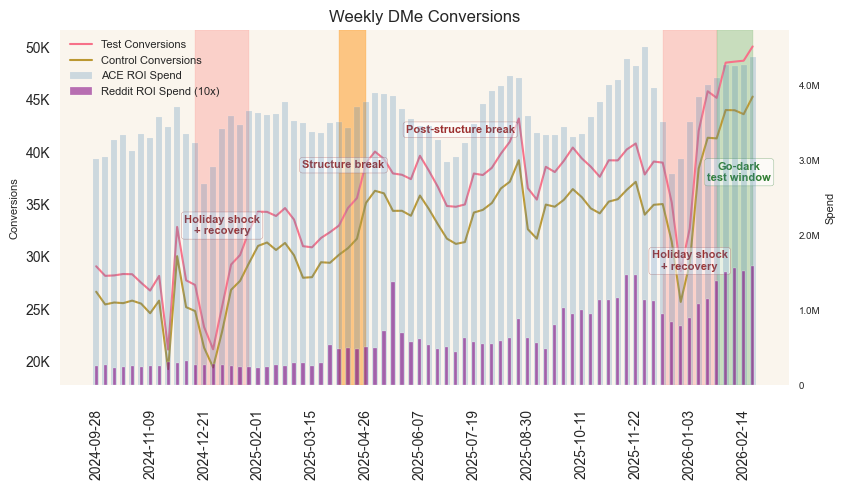

In [ ]:
%matplotlib inline
from matplotlib.ticker import FuncFormatter

structure_break_start = '2025-04-05'
structure_break_end = '2025-04-12'

def _fmt_k(x, pos):
    if abs(x) >= 1e6:
        return f'{x/1e6:.1f}M'
    if abs(x) >= 1e3:
        return f'{x/1e3:.0f}K'
    return f'{x:.0f}'

def _add_period_annotation(ax, x0, x1, y_frac, text, color):
    x_mid = (x0 + x1) / 2
    ax.text(
        x_mid,
        y_frac,
        text,
        transform=ax.get_xaxis_transform(),
        ha='center',
        va='center',
        fontsize=8,
        fontweight='bold',
        color=color,
        bbox=dict(boxstyle='round,pad=0.25', facecolor='white', edgecolor=color, alpha=0.6),
        zorder=5,
        clip_on=True,
    )

# ---- Spend mapping (now keyed by actual date) ----
try:
    ace_wkly_roi_spend = ace_roi_spend.copy()
    ace_wkly_roi_spend['week_start_date'] = pd.to_datetime(ace_wkly_roi_spend['week_start_date'])
    spend_by_date = dict(zip(
        ace_wkly_roi_spend['week_start_date'],
        ace_wkly_roi_spend['total_spend']
    ))
except Exception:
    spend_by_date = {}

# Reddit-only spend (subset of overall; same week_start_date / total_spend schema as ace_roi_spend)
try:
    _reddit_wk = reddit_roi_spend.copy()
    _reddit_wk['week_start_date'] = pd.to_datetime(_reddit_wk['week_start_date'])
    reddit_spend_by_date = dict(zip(_reddit_wk['week_start_date'], _reddit_wk['total_spend']))
except Exception:
    reddit_spend_by_date = {}

datasets_to_plot = [
    'DME_CONVERSIONS',
]

# pre_period_weeks = 72

# ---- Use real dates instead of fiscal week strings ----
test_start = pd.to_datetime(mmt.config.test_start_dates['Reddit'])  
test_end = pd.to_datetime(mmt.config.test_end_dates['Reddit'])

test_group_name = list(mmt.config.test_groups.keys())[0]
test_geos = [str(g) for g in mmt.config.test_groups[test_group_name]]
control_geos = [str(g) for g in mmt.config.control_groups[test_group_name]]

plots_to_make = []

for dataset_name in datasets_to_plot:
    if dataset_name not in mmt.config.datasets or dataset_name not in mmt.config.kpi:
        continue

    # df = mmt.config.datasets[dataset_name].copy()
    df = us_wkly_sales_l12m.copy()
    df['date'] = pd.to_datetime(df['date'])
    df['geo'] = df['geo'].astype(str)

    # pre_start = test_start - pd.Timedelta(weeks=pre_period_weeks)

    kpi_col = mmt.config.kpi[dataset_name]
    if kpi_col not in df.columns:
        continue

    test_series = df[df['geo'].isin(test_geos)].groupby('date')[kpi_col].sum()
    control_series = df[df['geo'].isin(control_geos)].groupby('date')[kpi_col].sum()

    both = pd.DataFrame({'test': test_series, 'control': control_series}) \
        .sort_index().ffill().bfill()

    both = both[(both.index <= test_end)]

    if both.empty:
        continue

    plots_to_make.append((dataset_name, both, kpi_col))

n_plots = len(plots_to_make)

if n_plots == 0:
    plt.figure()
    plt.text(0.5, 0.5, 'No valid datasets to plot', ha='center', va='center')
    plt.show()
else:
    n_cols = 2
    n_rows = (n_plots + n_cols - 1) // n_cols

    fig, axes_arr = plt.subplots(n_rows, n_cols, figsize=(8 * n_cols, 5 * n_rows), squeeze=False)
    axes = axes_arr.flatten()

    for j in range(n_plots, len(axes)):
        axes[j].set_visible(False)

    for idx, (dataset_name, both, kpi_col) in enumerate(plots_to_make):
        ax = axes[idx]
        ax.set_facecolor('#faf5ed')

        x_pos = np.arange(len(both))
        labels = both.index
        # print(len(labels))

        ax.plot(x_pos, both['test'].values, label='Test Conversions', lw=1.5, zorder=2)
        ax.plot(x_pos, both['control'].values, label='Control Conversions', lw=1.5, zorder=2)

        # ---- Spend overlay: ACE overall + Reddit-only (narrower bars, same x) ----
        spend_vals = np.array([spend_by_date.get(d, 0) for d in labels])
        reddit_vals = np.array([reddit_spend_by_date.get(d, 0)*10 for d in labels])
        has_ace = spend_vals.max() > 0
        has_reddit = reddit_vals.max() > 0

        if has_ace or has_reddit:
            ax2 = ax.twinx()
            if has_ace:
                ax2.bar(
                    x_pos, spend_vals, width=0.7, alpha=0.25, color='steelblue',
                    zorder=0, label='ACE ROI Spend',
                )
            if has_reddit:
                ax2.bar(
                    x_pos, reddit_vals, width=0.35, alpha=0.55, color='purple',
                    zorder=1, label='Reddit ROI Spend (10x)',
                )
            ax2.set_ylabel('Spend', fontsize=8)
            ax2.tick_params(axis='y', labelsize=7)
            ax2.grid(False)

        # ---- Period shading using real dates ----
        pre_shock_start = test_start - pd.Timedelta(weeks=6)

        holiday_start = pd.Timestamp("2024-12-14")
        holiday_end = pd.Timestamp("2025-01-25")

        level_shift_start_idx = np.searchsorted(labels, pre_shock_start)
        level_shift_end_idx = np.searchsorted(labels, test_start)
        holiday_start_idx = np.searchsorted(labels, holiday_start)
        holiday_end_idx = np.searchsorted(labels, holiday_end)
        structure_break_start_idx = np.searchsorted(labels, structure_break_start)
        structure_break_end_idx = np.searchsorted(labels, structure_break_end)
        treatment_start_idx = np.searchsorted(labels, test_start)
        treatment_end_idx = np.searchsorted(labels, test_end)

        ax.axvspan(
            level_shift_start_idx,
            level_shift_end_idx,
            alpha=0.15,
            color='red',
        )

        ax.axvspan(
            holiday_start_idx,
            holiday_end_idx,
            alpha=0.15,
            color='red',
        )

        ax.axvspan(
            structure_break_start_idx,
            structure_break_end_idx+2,
            alpha=0.45,
            color='',
        )

        ax.axvspan(
            treatment_start_idx,
            treatment_end_idx,
            alpha=0.20,
            color='green',
        )

        _add_period_annotation(
            ax,
            holiday_start_idx,
            holiday_end_idx,
            0.45,
            'Holiday shock\n+ recovery',
            '#9c2f2f',
        )
        _add_period_annotation(
            ax,
            structure_break_start_idx,
            structure_break_end_idx,
            0.62,
            'Structure break',
            '#9c2f2f',
        )
        _add_period_annotation(
            ax,
            structure_break_end_idx+10,
            structure_break_end_idx+15,
            0.72,
            'Post-structure break',
            '#9c2f2f',
        )
        _add_period_annotation(
            ax,
            level_shift_start_idx,
            level_shift_end_idx,
            0.35,
            'Holiday shock\n+ recovery',
            '#9c2f2f',
        )
        _add_period_annotation(
            ax,
            treatment_start_idx+1,
            treatment_end_idx,
            0.60,
            'Go-dark\ntest window',
            '#2f7d32',
        )

        ax.set_title(f'Weekly DMe Conversions')
        ax.set_ylabel(kpi_col.replace('_', ' ').title(), fontsize=8)

        step = max(1, len(labels) // 12)
        ax.set_xticks(x_pos[::step])
        ax.set_xticklabels([labels[i].strftime('%Y-%m-%d') for i in range(0, len(labels), step)], rotation=90)

        ax.yaxis.set_major_formatter(FuncFormatter(_fmt_k))

        if has_ace or has_reddit:
            ax2.yaxis.set_major_formatter(FuncFormatter(_fmt_k))

        lines1, labels1 = ax.get_legend_handles_labels()
        if has_ace or has_reddit:
            lines2, labels2 = ax2.get_legend_handles_labels()
            ax.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=8)
        else:
            ax.legend(loc='best', fontsize=8)

        ax.tick_params(axis='x', rotation=90, length=10, width=1.5)
        ax.grid(False)

    plt.tight_layout()
    plt.show()


# Residual Analysis

In [53]:
class ResidualAnalyzer:
    def __init__(self, residuals_dict: Dict[Tuple[str, str], pd.DataFrame]):
        """
        Initialize the ResidualAnalyzer with a dictionary of residuals.
        
        Args:
            residuals_dict: Dictionary containing DataFrames with keys as tuples (test_group, cloud)
                and values as DataFrames with columns: dt, y, y_hat, effect, y_lower, y_upper
        """
        self.residuals_dict = residuals_dict
        self.stats_cache = {}
    
    def _extract_model_info(self, key: Tuple[str, str]) -> Tuple[str, str, str]:
        """
        Extract test_group, cloud, and metric from a residual key.
        
        Args:
            key: Tuple in format (test_group, cloud)
        """
        test_group, cloud = key
        # For now, we'll use 'conversions' as the default metric
        # You can modify this based on your needs
        metric = 'conversions'  # or 'GNARR' based on your data
        return test_group, cloud, metric
    
    def get_available_models(self) -> List[Tuple[str, str]]:
        """Get list of available (cloud, metric) combinations"""
        models = set()
        for key in self.residuals_dict.keys():
            if isinstance(key, tuple) and len(key) == 2:
                test_group, cloud = key
                # Add both conversions and GNARR metrics if available
                models.add((cloud, 'conversions'))
                models.add((cloud, 'GNARR'))
        return sorted(list(models))
    
    def _estimate_parameters(self, cloud: str, metric: str) -> int:
        """
        Estimate number of parameters in the model.
        This is an approximation for Ridge regression.
        """
        # For Ridge regression, approximate as number of control units
        # You might need to adjust this based on your specific model structure
        return 20  # Default estimate
    
    def calculate_residual_stats(self, cloud: str, metric: str, period: str = 'post') -> Dict[str, float]:
        """
        Calculate statistics for residuals of a specific model.
        
        Args:
            cloud: Cloud name (e.g., 'Creative_Cloud_Indiv')
            metric: Metric name ('GNARR' or 'Conversions')
            period: 'pre' or 'post' test period (not used in this structure)
        """
        # Find the DataFrame for this cloud
        df = None
        for key, dataframe in self.residuals_dict.items():
            test_group, cloud_name = key
            if cloud_name == cloud:
                df = dataframe
                break
        
        if df is None:
            raise KeyError(f"Data not found for cloud: {cloud}")
        
        # Calculate residuals
        actuals = df['y'].values
        predictions = df['y_hat'].values
        residuals = actuals - predictions
        
        # Remove NaN values for calculations
        mask = ~np.isnan(actuals) & ~np.isnan(predictions) & ~np.isnan(residuals)
        actuals = actuals[mask]
        predictions = predictions[mask]
        residuals = residuals[mask]
        
        residual_stats = {}
        
        # Basic error metrics
        residual_stats['mae'] = np.mean(np.abs(residuals))
        residual_stats['mse'] = np.mean(residuals ** 2)
        residual_stats['rmse'] = np.sqrt(residual_stats['mse'])
        residual_stats['mad'] = np.median(np.abs(residuals))
        
        # Normalized error metrics (scale-independent)
        actual_mean = np.mean(np.abs(actuals))
        actual_std = np.std(actuals)
        
        if actual_mean > 0:
            residual_stats['mae_normalized_by_mean'] = residual_stats['mae'] / actual_mean
            residual_stats['rmse_normalized_by_mean'] = residual_stats['rmse'] / actual_mean
            residual_stats['mad_normalized_by_mean'] = residual_stats['mad'] / actual_mean
        else:
            residual_stats['mae_normalized_by_mean'] = np.nan
            residual_stats['rmse_normalized_by_mean'] = np.nan
            residual_stats['mad_normalized_by_mean'] = np.nan
            
        if actual_std > 0:
            residual_stats['mae_normalized_by_std'] = residual_stats['mae'] / actual_std
            residual_stats['rmse_normalized_by_std'] = residual_stats['rmse'] / actual_std
            residual_stats['mad_normalized_by_std'] = residual_stats['mad'] / actual_std
        else:
            residual_stats['mae_normalized_by_std'] = np.nan
            residual_stats['rmse_normalized_by_std'] = np.nan
            residual_stats['mad_normalized_by_std'] = np.nan
        
        # Percentage-based normalized metrics
        if np.sum(np.abs(actuals)) > 0:
            residual_stats['mae_percentage'] = (residual_stats['mae'] / np.mean(np.abs(actuals))) * 100
            residual_stats['rmse_percentage'] = (residual_stats['rmse'] / np.mean(np.abs(actuals))) * 100
        else:
            residual_stats['mae_percentage'] = np.nan
            residual_stats['rmse_percentage'] = np.nan
        
        # R² calculation
        total_sum_of_squares = np.sum((actuals - np.mean(actuals)) ** 2)
        residual_sum_of_squares = np.sum(residuals ** 2)
        residual_stats['r2'] = 1 - (residual_sum_of_squares / total_sum_of_squares)

        # Add Adjusted R² calculation
        n = len(actuals)  # sample size
        p = self._estimate_parameters(cloud, metric)  # number of parameters (estimate)
        
        if n > p + 1:  # Ensure we have enough degrees of freedom
            residual_stats['adjusted_r2'] = 1 - ((1 - residual_stats['r2']) * (n - 1) / (n - p - 1))
            residual_stats['r2_gap'] = residual_stats['r2'] - residual_stats['adjusted_r2']
            
            # Overfitting assessment
            if residual_stats['r2_gap'] > 0.05:
                residual_stats['overfitting_risk'] = 'HIGH'
            elif residual_stats['r2_gap'] > 0.02:
                residual_stats['overfitting_risk'] = 'MEDIUM'
            else:
                residual_stats['overfitting_risk'] = 'LOW'
        else:
            residual_stats['adjusted_r2'] = np.nan
            residual_stats['r2_gap'] = np.nan
            residual_stats['overfitting_risk'] = 'INSUFFICIENT_DATA'
        
        # Additional statistics
        residual_stats['mean_residual'] = np.mean(residuals)
        residual_stats['std_residual'] = np.std(residuals)
        residual_stats['min_residual'] = np.min(residuals)
        residual_stats['max_residual'] = np.max(residuals)
        
        # Normality test
        from scipy.stats import shapiro
        if len(residuals) >= 3:  # Shapiro-Wilk requires at least 3 observations
            shapiro_stat, shapiro_p = shapiro(residuals)
            residual_stats['shapiro_wilk_stat'] = shapiro_stat
            residual_stats['shapiro_wilk_p'] = shapiro_p
            residual_stats['is_normal'] = shapiro_p > 0.05
        else:
            residual_stats['shapiro_wilk_stat'] = np.nan
            residual_stats['shapiro_wilk_p'] = np.nan
            residual_stats['is_normal'] = np.nan
        
        return residual_stats
    
    def plot_residual_analysis(self, cloud: str, metric: str, period: str = 'post') -> Tuple[plt.Figure, Dict[str, float]]:
        """
        Create a comprehensive plot of residual analysis.
        
        Args:
            cloud: Cloud name (e.g., 'Creative_Cloud_Indiv')
            metric: Metric name ('GNARR' or 'Conversions')
            period: 'pre' or 'post' test period (not used in this structure)
        """
        # Find the DataFrame for this cloud
        df = None
        for key, dataframe in self.residuals_dict.items():
            test_group, cloud_name = key
            if cloud_name == cloud:
                df = dataframe
                break
        
        if df is None:
            raise KeyError(f"Data not found for cloud: {cloud}")
        
        # Calculate residuals
        actuals = df['y'].values
        predictions = df['y_hat'].values
        residuals = actuals - predictions
        
        # Remove NaN values for plotting
        mask = ~np.isnan(actuals) & ~np.isnan(predictions) & ~np.isnan(residuals)
        actuals = actuals[mask]
        predictions = predictions[mask]
        residuals = residuals[mask]
        
        # Calculate statistics
        residual_stats = self.calculate_residual_stats(cloud, metric, period)
        
        # Create figure with subplots
        fig, axes = plt.subplots(2, 2, figsize=(20, 15))
        fig.suptitle(f"Residual Analysis for {cloud} {metric}", fontsize=16)
        
        # 1. Scatter plot: Actuals vs Residuals
        axes[0, 0].scatter(actuals, residuals, color="blue", alpha=0.6, label="Residuals")
        axes[0, 0].axhline(y=0, color='r', linestyle='--', alpha=0.3)
        axes[0, 0].set_title("Actuals vs Residuals")
        axes[0, 0].set_xlabel("Actuals")
        axes[0, 0].set_ylabel("Residuals")
        axes[0, 0].legend()
        axes[0, 0].grid(alpha=0.3)
        
        # 2. Histogram of residuals with KDE
        axes[0, 1].hist(residuals, bins=30, density=True, alpha=0.7, color='skyblue', edgecolor='black')
        axes[0, 1].set_title("Residuals Distribution")
        axes[0, 1].set_xlabel("Residuals")
        axes[0, 1].set_ylabel("Density")
        axes[0, 1].grid(alpha=0.3)
        
        # Add normal distribution overlay
        from scipy.stats import norm
        x = np.linspace(residuals.min(), residuals.max(), 100)
        normal_dist = norm.pdf(x, np.mean(residuals), np.std(residuals))
        axes[0, 1].plot(x, normal_dist, 'r-', linewidth=2, label='Normal Distribution')
        axes[0, 1].legend()
        
        # 3. Q-Q plot
        from scipy.stats import probplot
        probplot(residuals, dist="norm", plot=axes[1, 0])
        axes[1, 0].set_title("Q-Q Plot (Residuals vs Normal)")
        axes[1, 0].grid(alpha=0.3)
        
        # 4. Residuals over time
        time_axis = np.arange(len(residuals))
        axes[1, 1].plot(time_axis, residuals, 'b-', alpha=0.7)
        axes[1, 1].axhline(y=0, color='r', linestyle='--', alpha=0.3)
        axes[1, 1].set_title("Residuals Over Time")
        axes[1, 1].set_xlabel("Time Index")
        axes[1, 1].set_ylabel("Residuals")
        axes[1, 1].grid(alpha=0.3)
        
        # Add statistics text
        stats_text = f"MAE: {residual_stats['mae']:.2f}\nRMSE: {residual_stats['rmse']:.2f}\nR²: {residual_stats['r2']:.3f}\nAdjusted R²: {residual_stats['adjusted_r2']:.3f}"
        axes[1, 1].text(0.02, 0.98, stats_text, transform=axes[1, 1].transAxes, 
                        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
        
        plt.tight_layout()
        return fig, residual_stats
    
    def create_summary_dataframe(self, period: str = 'post') -> pd.DataFrame:
        """Create a summary DataFrame with statistics for all models"""
        summary_data = []
        
        for key in self.residuals_dict.keys():
            if isinstance(key, tuple) and len(key) == 2:
                test_group, cloud = key
                
                # Calculate stats for both metrics
                # for metric in ['conversions', 'GNARR']:
                for metric in ['conversions']:
                    try:
                        stats = self.calculate_residual_stats(cloud, metric, period)
                        stats_new = {'test_group': test_group, 'cloud': cloud, 'metric': metric, **stats}
                        summary_data.append(stats_new)
                    except Exception as e:
                        print(f"Error processing {cloud}_{metric}: {e}")
                        continue
        
        return pd.DataFrame(summary_data)
    
    def check_overfitting_comprehensive(self, cloud: str, metric: str, period: str = 'post') -> Dict[str, any]:
        """Comprehensive overfitting check"""
        stats = self.calculate_residual_stats(cloud, metric, period)
        
        indicators = []
        
        # Check R² gap
        if stats['r2_gap'] > 0.05:
            indicators.append(f"High R² gap: {stats['r2_gap']:.3f}")
        
        # Check normalized errors
        if stats['mae_normalized_by_mean'] > 0.5:
            indicators.append(f"High normalized MAE: {stats['mae_normalized_by_mean']:.3f}")
        
        # Check normality
        if not stats['is_normal']:
            indicators.append("Residuals not normally distributed")
        
        return {
            'overfitting_risk': stats['overfitting_risk'],
            'indicators': indicators,
            'r2_gap': stats['r2_gap'],
            'mae_normalized': stats['mae_normalized_by_mean']
        }
    
    def analyze_all_models(self, period: str = 'post') -> Tuple[List[Dict[str, float]], List[plt.Figure]]:
        """Analyze all models and return statistics and figures"""
        all_stats = []
        all_figures = []
        
        for key in self.residuals_dict.keys():
            if isinstance(key, tuple) and len(key) == 2:
                test_group, cloud = key
                
                # for metric in ['conversions', 'GNARR']:
                for metric in ['conversions']:
                    try:
                        fig, stats = self.plot_residual_analysis(cloud, metric, period)
                        stats_new = {'test_group': test_group, 'cloud': cloud, 'metric': metric, **stats}
                        
                        all_stats.append(stats_new)
                        all_figures.append(fig)
                    except Exception as e:
                        print(f"Error analyzing {cloud}_{metric}: {e}")
                        continue
        
        return all_stats, all_figures

In [54]:
# Initialize analyzer
analyzer = ResidualAnalyzer(weekly_trends_dct)

# Get available models
models = analyzer.get_available_models()
print("Available models:", models)

# # Analyze a specific model
# cloud, metric = models[0]  # e.g., ('Creative_Cloud_Indiv', 'GNARR')
# fig, stats = analyzer.plot_residual_analysis(cloud, metric, period='pre')
# plt.show()

# Create summary DataFrame
summary_df = analyzer.create_summary_dataframe(period='pre')
print("\nSummary Statistics:")
summary_df

# # Check overfitting for specific models
# for cloud, metric in analyzer.get_available_models():
#     overfitting_check = analyzer.check_overfitting_comprehensive(cloud, metric, 'pre')
#     print(f"{cloud}_{metric}: {overfitting_check['overfitting_risk']} risk")
#     if overfitting_check['indicators']:
#         print(f"  Indicators: {overfitting_check['indicators']}")


Available models: [('CC_CONVERSIONS', 'GNARR'), ('CC_CONVERSIONS', 'conversions'), ('CC_SALES', 'GNARR'), ('CC_SALES', 'conversions'), ('CC_TRY_CONVERSIONS', 'GNARR'), ('CC_TRY_CONVERSIONS', 'conversions'), ('CC_WEB_BUY_ORDERS', 'GNARR'), ('CC_WEB_BUY_ORDERS', 'conversions'), ('CC_WEB_ORDERS', 'GNARR'), ('CC_WEB_ORDERS', 'conversions'), ('CC_WEB_TRY_ORDERS', 'GNARR'), ('CC_WEB_TRY_ORDERS', 'conversions'), ('DC_CONVERSIONS', 'GNARR'), ('DC_CONVERSIONS', 'conversions'), ('DC_SALES', 'GNARR'), ('DC_SALES', 'conversions'), ('DC_TRY_CONVERSIONS', 'GNARR'), ('DC_TRY_CONVERSIONS', 'conversions'), ('DC_WEB_BUY_ORDERS', 'GNARR'), ('DC_WEB_BUY_ORDERS', 'conversions'), ('DC_WEB_ORDERS', 'GNARR'), ('DC_WEB_ORDERS', 'conversions'), ('DC_WEB_TRY_ORDERS', 'GNARR'), ('DC_WEB_TRY_ORDERS', 'conversions'), ('DI_CONVERSIONS', 'GNARR'), ('DI_CONVERSIONS', 'conversions'), ('DME_CONVERSIONS', 'GNARR'), ('DME_CONVERSIONS', 'conversions'), ('DME_SALES', 'GNARR'), ('DME_SALES', 'conversions'), ('DME_TRY_CONVERS

,test_group,cloud,metric,mae,mse,rmse,mad,mae_normalized_by_mean,rmse_normalized_by_mean,mad_normalized_by_mean,mae_normalized_by_std,rmse_normalized_by_std,mad_normalized_by_std,mae_percentage,rmse_percentage,r2,adjusted_r2,r2_gap,overfitting_risk,mean_residual,std_residual,min_residual,max_residual,shapiro_wilk_stat,shapiro_wilk_p,is_normal
0,Reddit,WEB_VISITS,conversions,4496.901282,3.756435e+07,6128.976083,3531.798508,0.019956,0.027199,0.015673,0.046601,0.063514,0.036600,1.995644,2.719929,0.995966,0.995751,0.000215,LOW,227.439823,6124.754604,-38652.295160,33394.063693,0.945051,5.760862e-11,False
1,Reddit,WEB_VISITORS,conversions,4620.710393,4.112790e+07,6413.103404,3511.176812,0.021720,0.030145,0.016504,0.048950,0.067938,0.037196,2.171964,3.014479,0.995384,0.995139,0.000246,LOW,483.875701,6394.822873,-37870.600722,32389.742347,0.941425,2.090764e-11,False
2,Reddit,DME_WEB_ORDERS,conversions,85.318757,1.052713e+04,102.601807,74.010078,0.011795,0.014185,0.010232,0.048305,0.058090,0.041903,1.179548,1.418489,0.996626,0.996446,0.000180,LOW,10.673283,102.045146,-269.517718,283.807682,0.992799,5.412720e-02,True
3,Reddit,DME_WEB_BUY_ORDERS,conversions,41.658091,2.823844e+03,53.139849,34.277463,0.019639,0.025052,0.016159,0.081256,0.103652,0.066860,1.963884,2.505167,0.989256,0.988683,0.000573,LOW,0.613741,53.136304,-152.326381,162.054640,0.995257,2.699902e-01,True
4,Reddit,DME_WEB_TRY_ORDERS,conversions,59.025697,5.409894e+03,73.551980,51.470790,0.011547,0.014388,0.010069,0.045161,0.056275,0.039381,1.154657,1.438819,0.996833,0.996664,0.000169,LOW,3.991771,73.443580,-195.214789,222.954400,0.996576,5.642354e-01,True
5,Reddit,CC_WEB_ORDERS,conversions,52.798140,4.850870e+03,69.648190,41.756515,0.017122,0.022586,0.013541,0.104799,0.138244,0.082882,1.712191,2.258622,0.980888,0.979869,0.001019,LOW,1.499235,69.632052,-219.761289,207.696898,0.992670,4.964618e-02,False
6,Reddit,CC_WEB_BUY_ORDERS,conversions,36.713742,2.313166e+03,48.095383,27.811596,0.025255,0.033084,0.019131,0.121558,0.159242,0.092083,2.525490,3.308419,0.974642,0.973290,0.001352,LOW,0.662764,48.090817,-159.910113,160.917695,0.989728,7.123542e-03,False
7,Reddit,CC_WEB_TRY_ORDERS,conversions,36.765805,2.030045e+03,45.056016,32.575757,0.022557,0.027643,0.019986,0.123057,0.150805,0.109033,2.255665,2.764288,0.977258,0.976045,0.001213,LOW,5.219696,44.752647,-128.869309,143.507135,0.993032,6.326947e-02,True
8,Reddit,DC_WEB_ORDERS,conversions,48.227378,3.840459e+03,61.971441,39.749519,0.011575,0.014874,0.009541,0.036022,0.046288,0.029690,1.157548,1.487432,0.997857,0.997743,0.000114,LOW,-1.089620,61.961861,-165.668916,250.880817,0.994022,1.223250e-01,True
9,Reddit,DC_WEB_BUY_ORDERS,conversions,17.915066,5.166726e+02,22.730433,15.302207,0.026693,0.033868,0.022800,0.071821,0.091126,0.061346,2.669333,3.386819,0.991696,0.991253,0.000443,LOW,-0.108240,22.730175,-63.209497,65.669826,0.997368,7.846582e-01,True


# Plots

In [55]:
def plot_pre_post_test_comparison(weekly_trends_dct, test_group_name, cloud, test_start_date, flip_sign=False):
    """
    Generate two charts:
    Chart 1: Combined pre-test and post-test - Actuals vs Counterfactuals
    Chart 2: Differences with pre/post averages and confidence intervals
    """
    
    # Get the weekly data for the specified combination
    key = (test_group_name, cloud)
    if key not in weekly_trends_dct:
        raise KeyError(f"Combination {key} not found in weekly_trends_dct")
    
    weekly_rdf = weekly_trends_dct[key].copy(deep=True)
    weekly_rdf.set_index('dt', inplace=True)
    
    # Convert test_start_date to datetime
    test_start_dt = pd.to_datetime(test_start_date)
    
    # Set up the plotting style
    sns.set_style("whitegrid")
    
    # Create figure with 2 subplots
    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(20, 20))
    
    # Separate pre-test and post-test data
    pre_test_data = weekly_rdf[weekly_rdf.index < test_start_dt].copy()
    post_test_data = weekly_rdf[weekly_rdf.index >= test_start_dt].copy()
    
    # Chart 1: Combined Pre-test and Post-test - Actuals vs Counterfactuals
    x_values = range(len(weekly_rdf))
    
    # Calculate rolling 7-day averages for the entire dataset
    actuals_rolling = weekly_rdf['y'].rolling(window=7, min_periods=1).mean()
    counterfactual_rolling = weekly_rdf['y_hat'].rolling(window=7, min_periods=1).mean()
    
    # Plot actuals and counterfactuals (rolling averages)
    ax1.plot(x_values, actuals_rolling, 
            label="Test", linewidth=2, color='darkblue')
    ax1.plot(x_values, counterfactual_rolling, 
            label="Control", linewidth=2, color='#FF6347', alpha=0.7)
    
    # Add vertical line at test start date
    test_start_idx = len(pre_test_data)
    ax1.axvline(x=test_start_idx, color='purple', linestyle='--', alpha=0.8, linewidth=2, label='Test Start')
    
    # Set x-axis labels
    ax1.set_xticks(range(0, len(weekly_rdf), builtins.max(1, len(weekly_rdf)//10)))
    ax1.set_xticklabels([weekly_rdf.index[i].strftime('%Y-%m-%d') 
                        for i in range(0, len(weekly_rdf), builtins.max(1, len(weekly_rdf)//10))], rotation=45)
    
    # Customize chart 1
    ax1.set_title(f"{cloud} - Actuals vs Counterfactuals", fontsize=22, fontweight='bold',pad=20)
    ax1.set_ylabel(f"Weekly {cloud}", fontsize=18, color='black')
    ax1.legend(loc='upper left', fontsize=18)
    ax1.tick_params(axis='x', labelsize=15)
    ax1.tick_params(axis='y', labelsize=15)
    ax1.axvspan(test_start_idx, len(weekly_rdf), color="royalblue", alpha=0.15, label="Test Period")
    
    # Chart 2: Differences with Pre/Post Averages and Confidence Intervals (Post-Test Only)
    x_values = range(len(post_test_data))

    # Calculate differences (effects) for post-test period only
    effects = post_test_data['effect']
    
    # Apply sign flip if flag is True
    if flip_sign:
        effects = -effects

    # Plot differences
    ax2.plot(x_values, effects, 
            label="Daily Differences", linewidth=3, color='#FF6347')

    # Add confidence intervals for post-test period
    if len(post_test_data) > 0 and 'y_lower' in post_test_data.columns and 'y_upper' in post_test_data.columns:
        ci_lower = post_test_data['y'] - post_test_data['y_lower']  # Lower bound of actual - counterfactual
        ci_upper = post_test_data['y'] - post_test_data['y_upper']  # Upper bound of actual - counterfactual
        
        # Apply sign flip to confidence intervals if flag is True
        if flip_sign:
            ci_lower, ci_upper = -ci_upper, -ci_lower  # Swap and flip signs
        
        # Fill confidence intervals
        ax2.fill_between(x_values, ci_lower, ci_upper, 
                        alpha=0.5, color='green', label='95% CI')

    # Add vertical line at test start date (at x=0 since we're only showing post-test)
    ax2.axvline(x=0, color='purple', linestyle='--', alpha=0.8, linewidth=3, label='Test Start')
    ax2.axhline(0, color='black', linestyle='dotted', linewidth=4)

    # Set x-axis labels for post-test period only
    ax2.set_xticks(range(0, len(post_test_data), builtins.max(1, len(post_test_data)//10)))
    ax2.set_xticklabels([post_test_data.index[i].strftime('%Y-%m-%d') 
                        for i in range(0, len(post_test_data), builtins.max(1, len(post_test_data)//10))], rotation=45)

    # Customize chart 2
    ax2.set_title(f"{cloud} - Post Test Period Point Estimates", fontsize=22, fontweight='bold', pad=20)
    ax2.set_ylabel("Daily Differences", fontsize=18, color='black')
    ax2.legend(loc='upper center', fontsize=18)
    ax2.tick_params(axis='x', labelsize=15)
    ax2.tick_params(axis='y', labelsize=15)
    ax2.axvspan(0, len(post_test_data), color="royalblue", alpha=0.15, label="Test Period")

    # Add horizontal line at y=0
    ax2.axhline(y=0, color='black', linestyle=':', alpha=0.5)

    #Chart 3: cumulative effect
    # Calculate cumulative effect for post-test period only
    post_test_data['cum'] = post_test_data['effect'].cumsum()
    
    # Apply sign flip to cumulative effect if flag is True
    if flip_sign:
        post_test_data['cum'] = -post_test_data['cum']
    
    # Calculate cumulative confidence intervals for post-test period
    if 'y_lower' in post_test_data.columns and 'y_upper' in post_test_data.columns:
        ci_range = post_test_data['y_upper'] - post_test_data['y_lower']
        post_test_data['cum_ci_lower'] = (post_test_data['effect'] - ci_range/2).cumsum()
        post_test_data['cum_ci_upper'] = (post_test_data['effect'] + ci_range/2).cumsum()
        
        # Apply sign flip to cumulative confidence intervals if flag is True
        if flip_sign:
            post_test_data['cum_ci_lower'], post_test_data['cum_ci_upper'] = -post_test_data['cum_ci_upper'], -post_test_data['cum_ci_lower']
    
    x_values_cumsum = range(len(post_test_data))
    
    ax3.plot(x_values_cumsum, post_test_data['cum'], 
                color='#FF6347', alpha=0.7, linewidth=2, label='Cumulative Effect (Post-Test)')
    
    # Add confidence intervals for post-test period
    if 'cum_ci_lower' in post_test_data.columns and 'cum_ci_upper' in post_test_data.columns:
        ax3.fill_between(x_values_cumsum, post_test_data['cum_ci_lower'], post_test_data['cum_ci_upper'],
                        alpha=0.3, color='green', label='95% Confidence Interval')
        
    # Add vertical line for test start (at x=0 since we're only showing post-test)
    ax3.axvline(0, color='purple', linestyle='--', linewidth=3, label='Test Start')
    ax3.axhline(0, color='black', linestyle='dotted', linewidth=4)
    
    # Set x-axis labels for post-test period only
    ax3.set_xticks(range(0, len(post_test_data), builtins.max(1, len(post_test_data)//10)))
    ax3.set_xticklabels([post_test_data.index[i].strftime('%Y-%m-%d') 
                        for i in range(0, len(post_test_data), builtins.max(1, len(post_test_data)//10))], rotation=45)
    
    # Customize chart 3
    ax3.set_title(f"{test_group_name} ({cloud}) - Post Test Period Cumulative Effect", fontsize=22, fontweight='bold', pad=20)
    ax3.set_ylabel(f"Cumulative Incremental", fontsize=18, labelpad=10)
    ax3.legend(fontsize=18, loc='best')
    ax3.tick_params(axis='x', labelsize=15)
    ax3.tick_params(axis='y', labelsize=15)

    # Add horizontal line at y=0
    ax3.axhline(y=0, color='black', linestyle=':', alpha=0.5)   
    
    # Adjust layout
    plt.tight_layout()
    
#     return fig

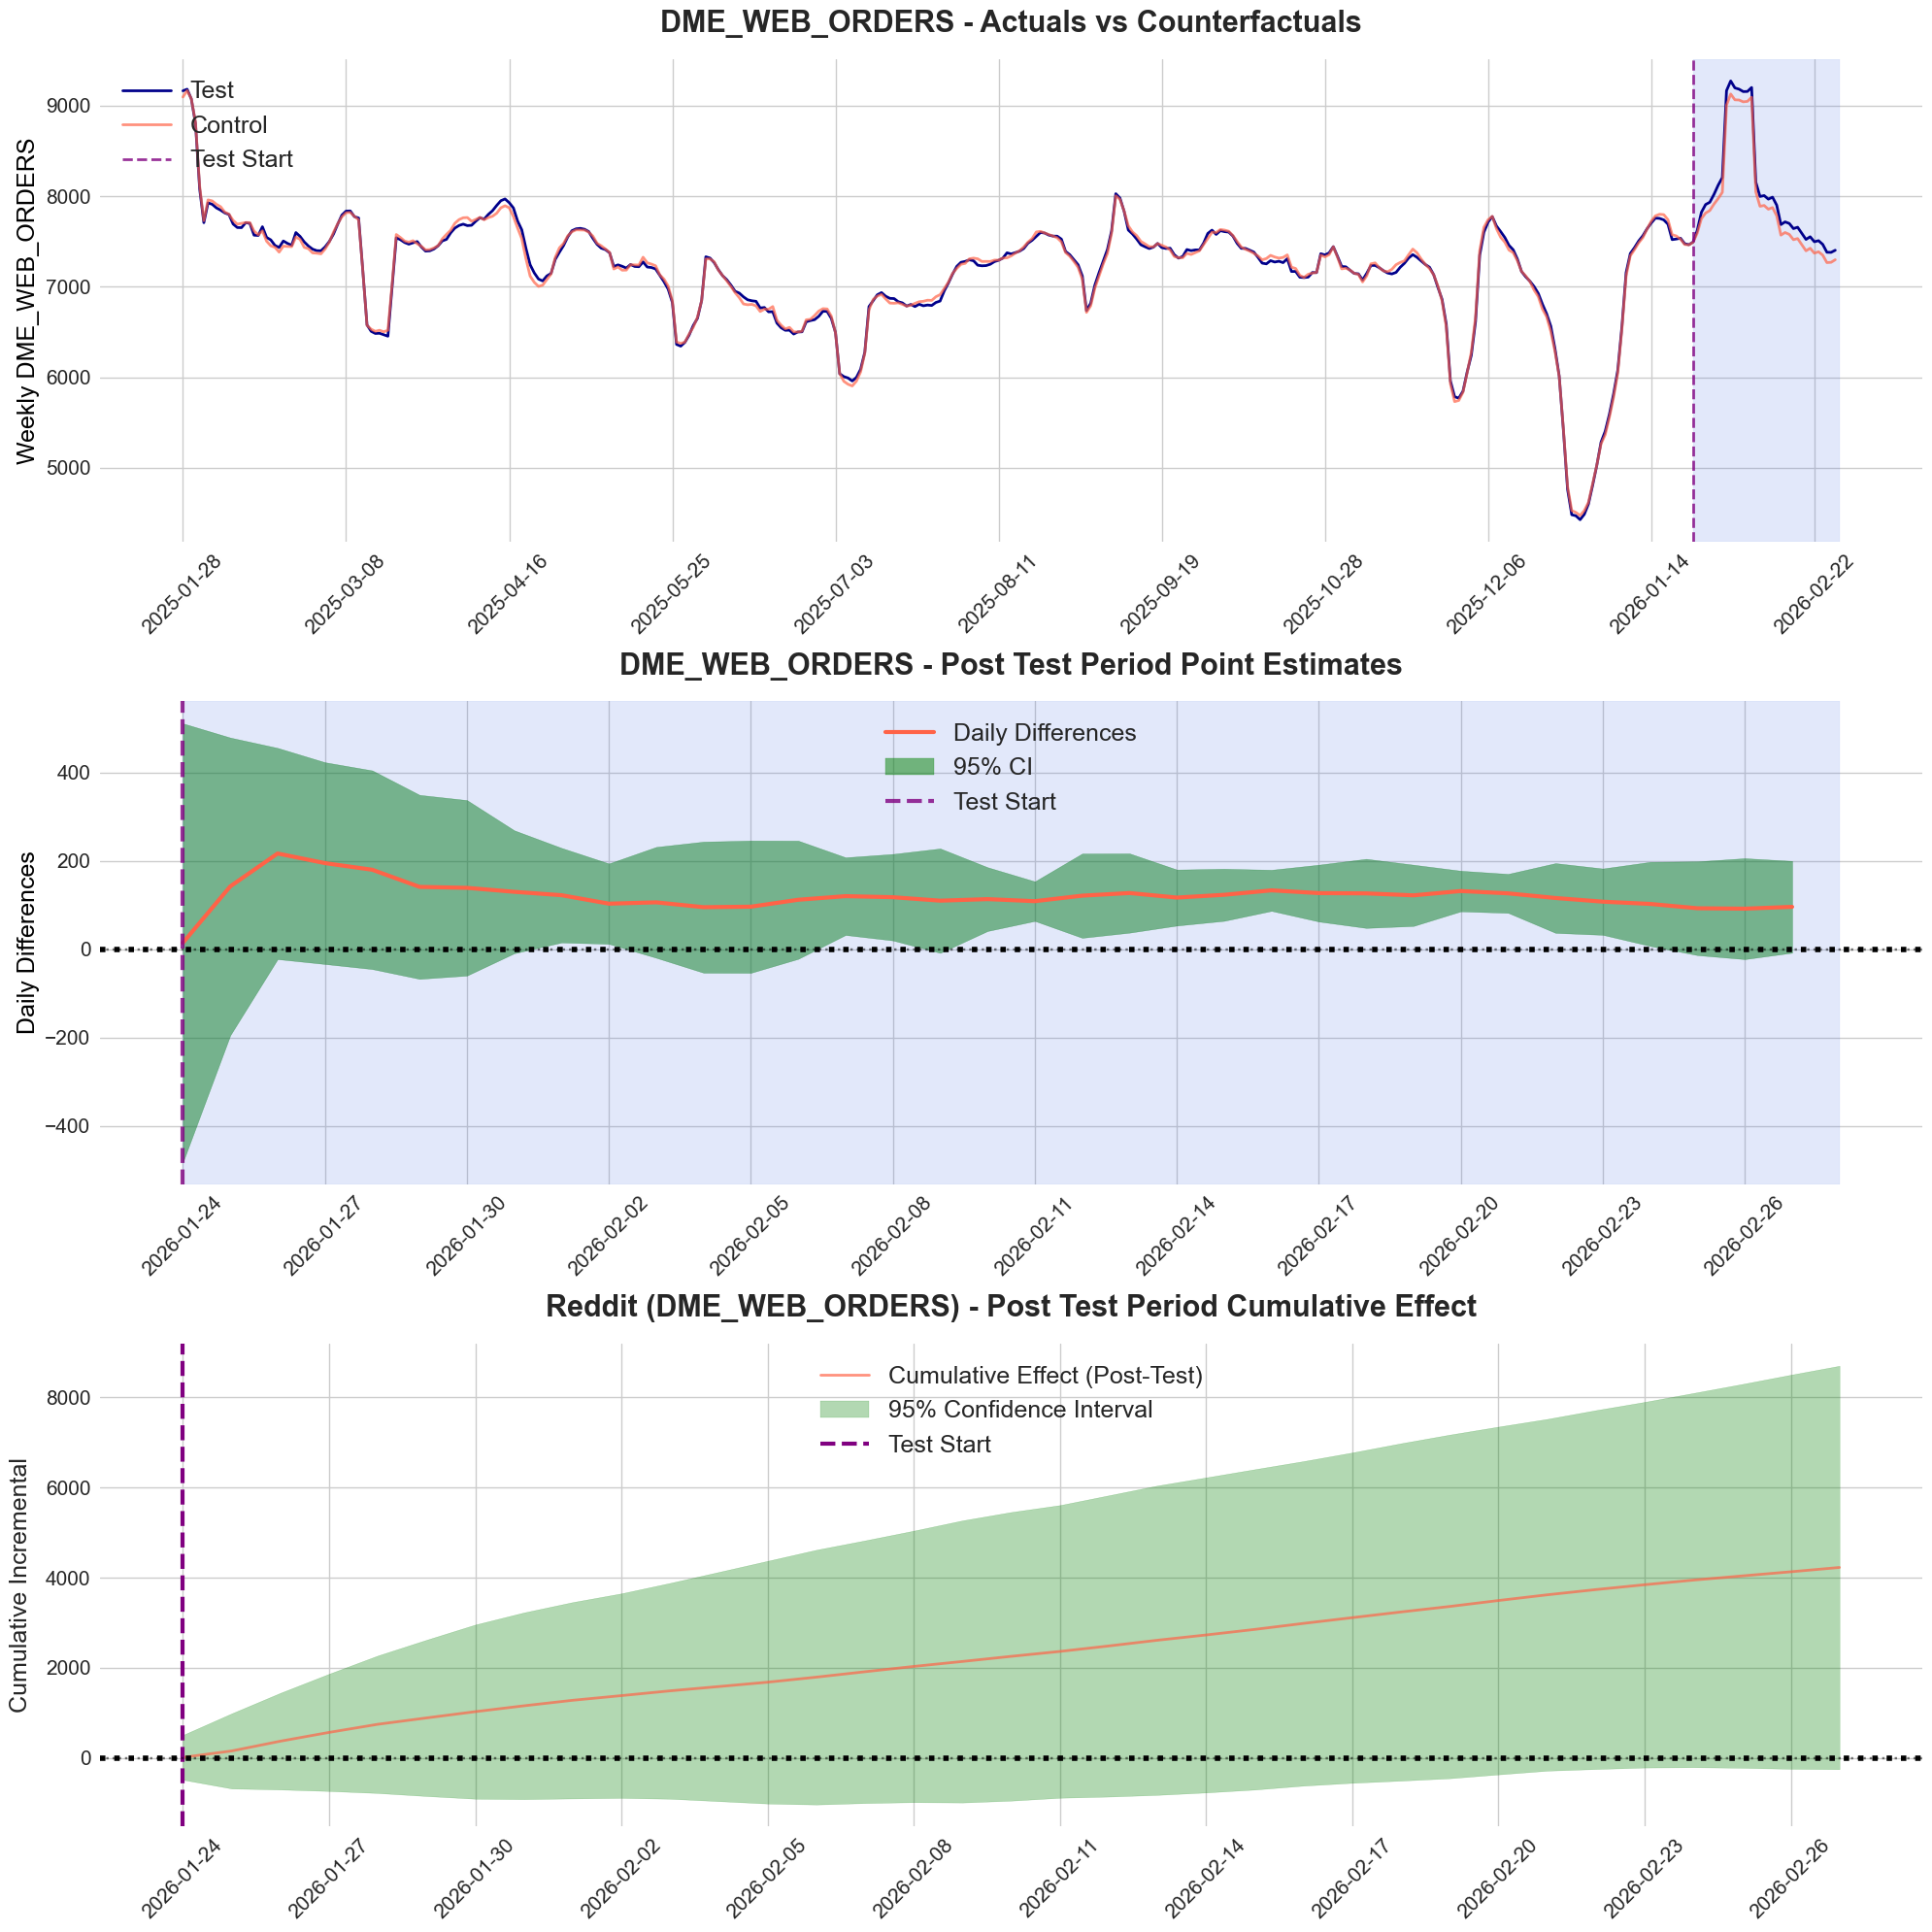

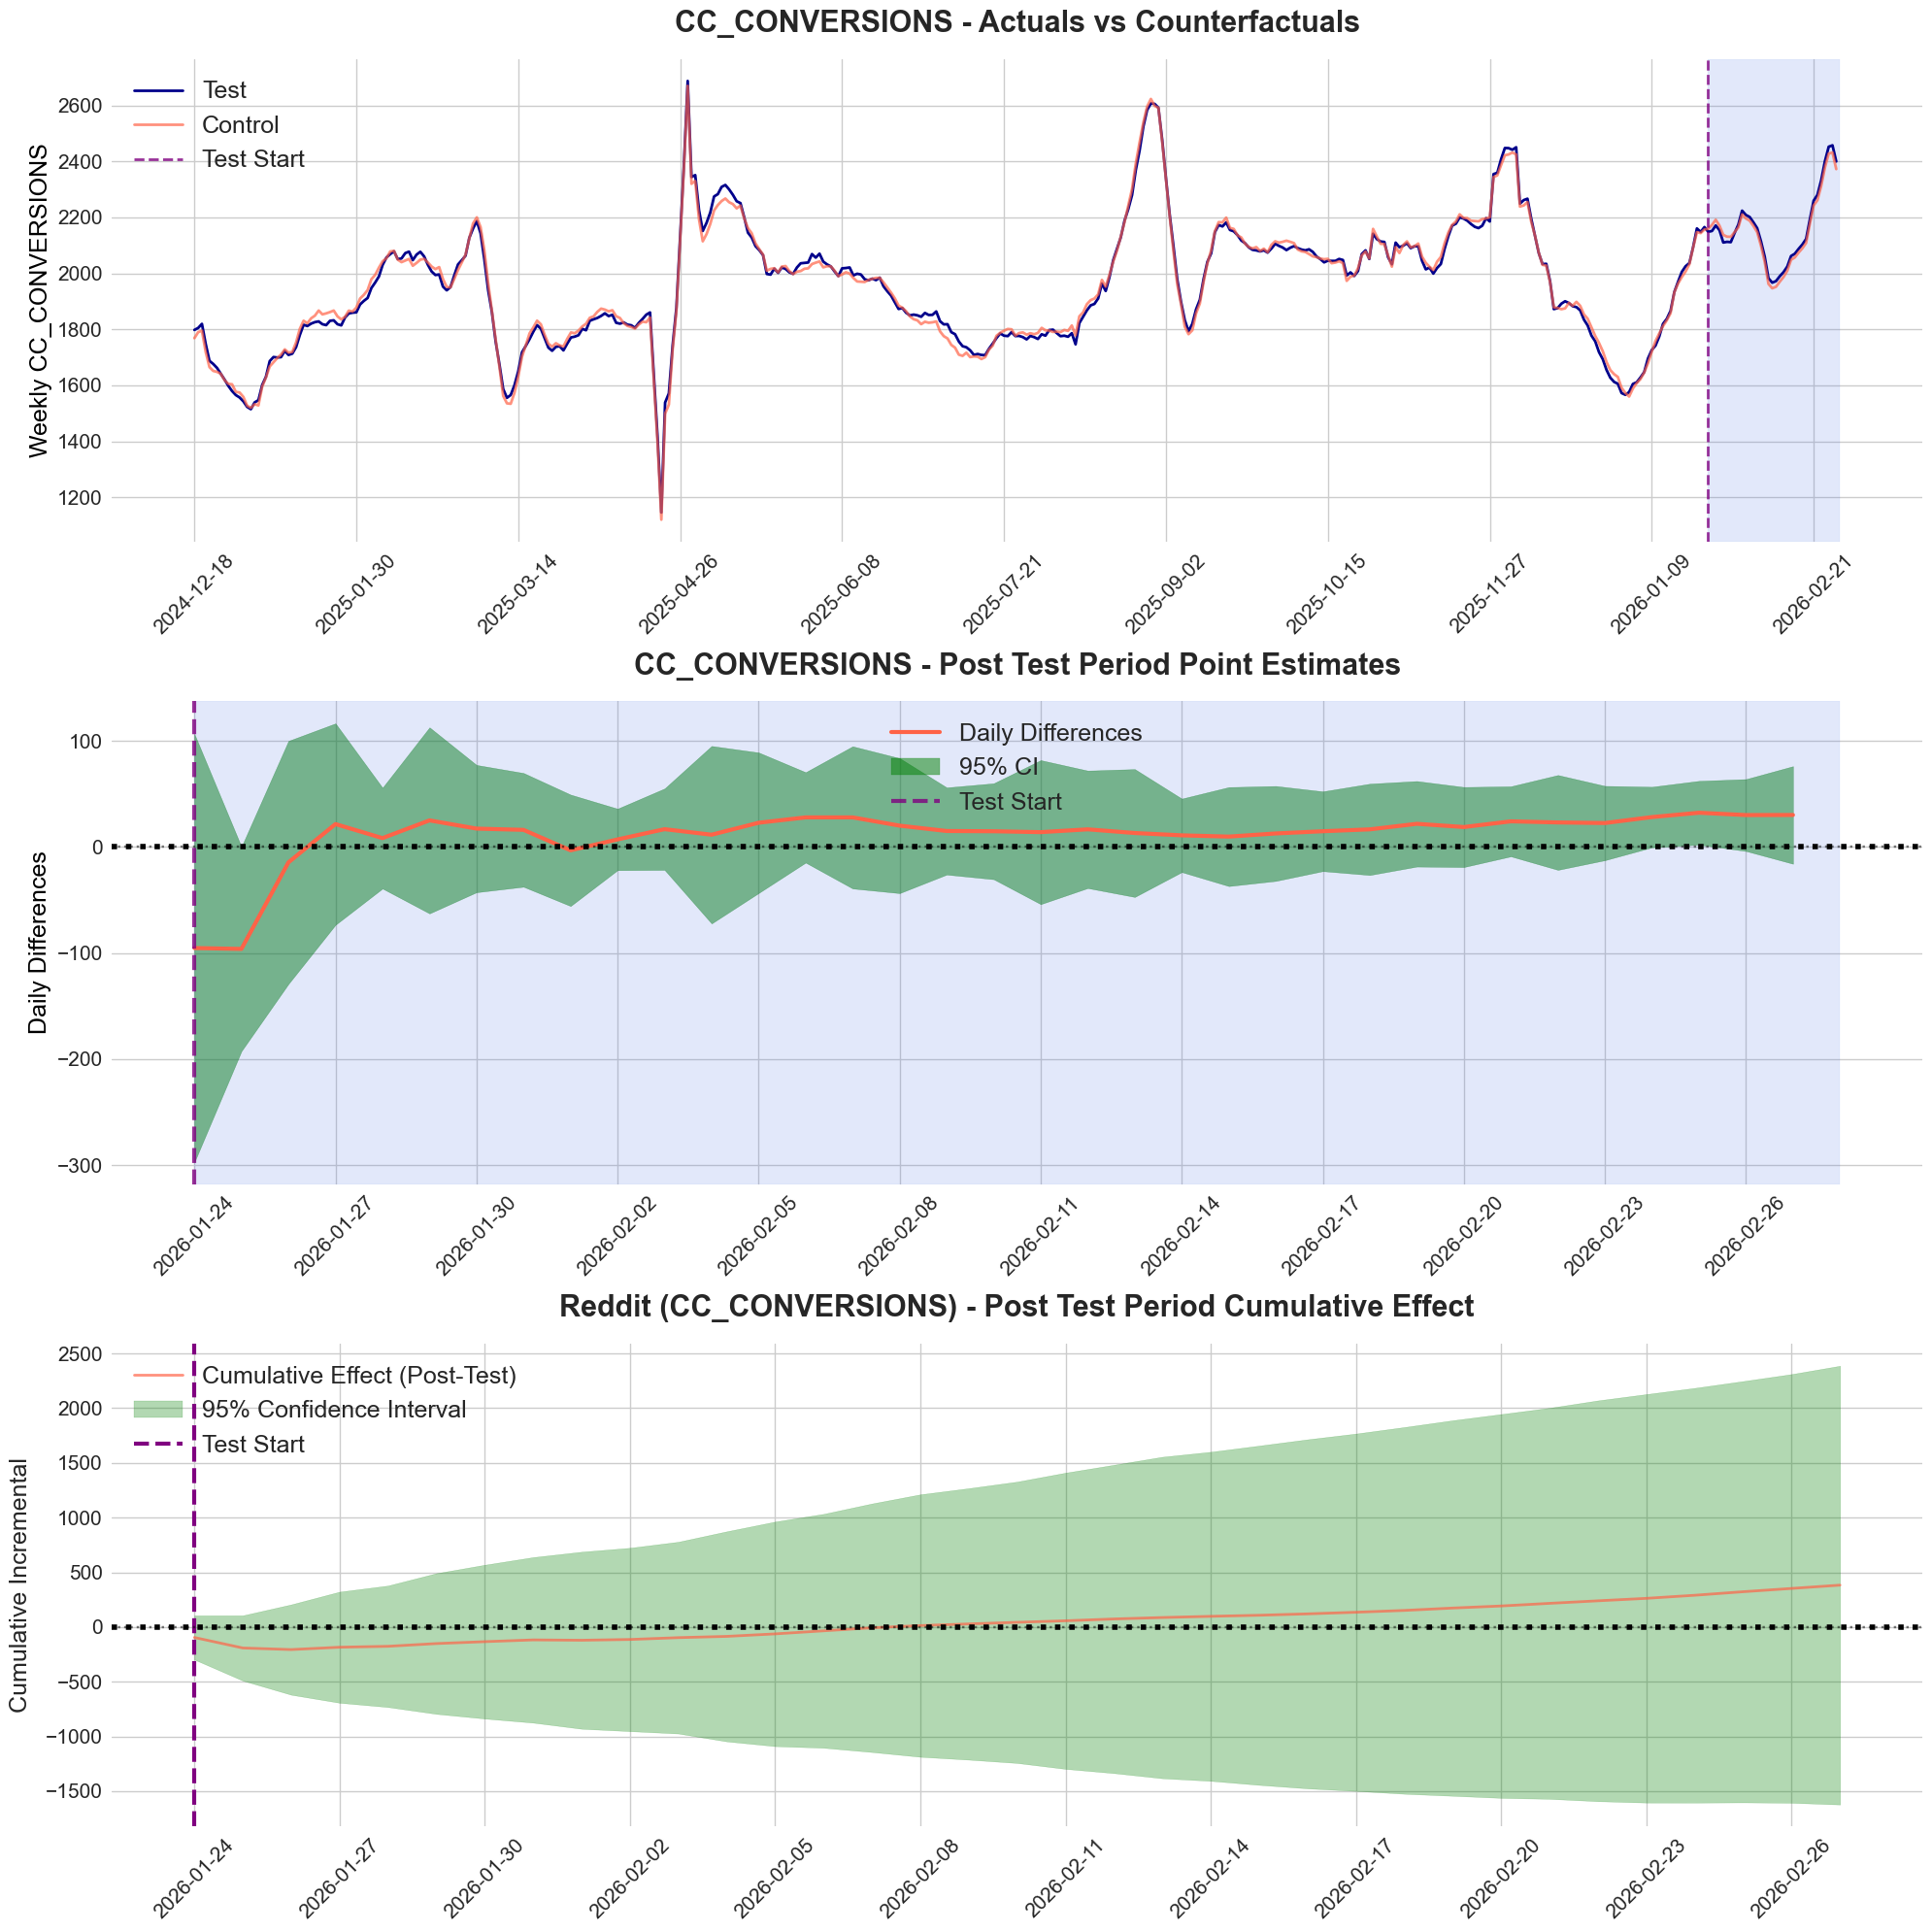

In [56]:
plot_pre_post_test_comparison(
    weekly_trends_dct,  
    test_group_name='Reddit',            
    cloud='DME_WEB_ORDERS',                  
    test_start_date='2026-01-24'         
)

plot_pre_post_test_comparison(
    weekly_trends_dct,  
    test_group_name='Reddit',            
    cloud='CC_CONVERSIONS',                 
    test_start_date='2026-01-24'         
)


In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter
import seaborn as sns

from matplotlib.ticker import FuncFormatter

def format_k_smart(x, pos):
    """Smart K formatting - handles different ranges appropriately"""
    if x >= 1000000:
        return f'{x/1000000:.1f}M'
    elif x >= 1000:
        return f'{x/1000:.0f}K'
    elif x >= 100:
        return f'{x/100:.1f}K'
    else:
        return f'{x:.0f}'

def weekly_test_vs_control_plot(weekly_trends_dct, test_group_name, cloud, test_start_date):
    """
    Generate only Chart 1: Combined pre-test and post-test - Actuals vs Counterfactuals
    with daily data converted to weekly and test start aligned to week start.
    Pre-test period is limited to 4x the test duration.
    """
    
    # Get the daily data for the specified combination
    key = (test_group_name, cloud)
    if key not in weekly_trends_dct:
        raise KeyError(f"Combination {key} not found in weekly_trends_dct")
    
    # Get the daily data and convert to weekly
    daily_rdf = weekly_trends_dct[key].copy(deep=True)
    daily_rdf['dt'] = pd.to_datetime(daily_rdf['dt'])
    
    # Convert test_start_date to datetime and align to week start (Monday)
    test_start_dt = pd.to_datetime(test_start_date)
    # Find the Monday of the week containing test_start_date
    test_start_week_start = test_start_dt - pd.Timedelta(days=test_start_dt.weekday())
    
    # Convert daily data to weekly by grouping by week start (Saturday)
    daily_rdf['week_start'] = daily_rdf['dt'].dt.to_period('W-FRI').apply(lambda r: r.start_time)
    
    # Aggregate daily data to weekly
    weekly_rdf = daily_rdf.groupby('week_start').agg({
        'y': 'sum',                # Sum the daily values for weekly totals
        'y_hat': 'sum',            # Sum the daily counterfactuals for weekly totals
        'effect': 'sum',           # Sum the daily effects for weekly totals
        'dt': 'count'              # Count of days in each week
    }).rename(columns={'dt': 'days_count'})
    
    # Reset index to make week_start a column
    weekly_rdf = weekly_rdf.reset_index()
    weekly_rdf.set_index('week_start', inplace=True)
    
    # Calculate test duration (from test start to end of data)
    test_period_data = weekly_rdf[weekly_rdf.index >= test_start_week_start]
    test_duration_weeks = len(test_period_data)
    
    # Calculate pre-test period limit (2x test duration)
    pre_test_limit_weeks = test_duration_weeks * 2
    
    # Filter pre-test data to limit it to 2x test duration
    pre_test_data = weekly_rdf[weekly_rdf.index < test_start_week_start].copy()
    if len(pre_test_data) > pre_test_limit_weeks:
        # Keep only the most recent pre_test_limit_weeks of pre-test data
        pre_test_data = pre_test_data.tail(pre_test_limit_weeks)
    
    # Combine filtered pre-test and post-test data
    filtered_weekly_rdf = pd.concat([pre_test_data, test_period_data])
    
    # Set up the plotting style
    sns.set_style("whitegrid")
    
    # Create figure with single subplot
    fig, ax = plt.subplots(1, 1, figsize=(20, 10))
    
    # Chart 1: Combined Pre-test and Post-test - Actuals vs Counterfactuals
    x_values = range(len(filtered_weekly_rdf))
    
    # Weekly Sums
    actuals_weekly = filtered_weekly_rdf['y']
    counterfactual_weekly = filtered_weekly_rdf['y_hat']
    
    # Plot actuals and counterfactuals (rolling averages)
    ax.plot(x_values, actuals_weekly, 
            label="Control", linewidth=2, color='darkblue')
            # label="Test", linewidth=2, color='#FF6347')
    ax.plot(x_values, counterfactual_weekly, 
            # label="Control", linewidth=2, color='darkblue', alpha=0.7)
            label="Test", linewidth=2, color='#FF6347', alpha=0.7)
    
    # Add vertical line at test start date (aligned to week start)
    test_start_idx = len(pre_test_data)
    ax.axvline(x=test_start_idx, color='purple', linestyle='--', alpha=0.8, linewidth=2, label='Test Start')
    
    # Set x-axis labels
    ax.set_xticks(range(0, len(filtered_weekly_rdf), builtins.max(1, len(filtered_weekly_rdf)//10)))
    ax.set_xticklabels([filtered_weekly_rdf.index[i].strftime('%Y-%m-%d') 
                        for i in range(0, len(filtered_weekly_rdf), builtins.max(1, len(filtered_weekly_rdf)//10))], rotation=45)
    
    # Customize chart
    # ax.set_title(f"{' '.join(cloud.split('_'))} - Actuals vs Counterfactuals (Weekly)", fontsize=22, fontweight='bold', pad=20)
    ax.set_ylabel(f"Weekly {' '.join(cloud.split('_'))}", fontsize=20, color='black')
    ax.legend(loc='upper left', fontsize=22)
    ax.axvspan(test_start_idx, len(filtered_weekly_rdf)-1, color="royalblue", alpha=0.15, label="Test Period")
    
    # Add horizontal line at y=0 for reference
    ax.axhline(y=0, color='black', linestyle=':', alpha=0.3)
    ax.tick_params(axis='x', labelsize=22)  # Increase x-tick label size
    ax.tick_params(axis='y', labelsize=22)  # Increase y-tick label size
    
    formatter = FuncFormatter(format_k_smart)
    # ax.yaxis.set_major_formatter(formatter)
    
    # Adjust layout
    plt.tight_layout()
    
    # return fig

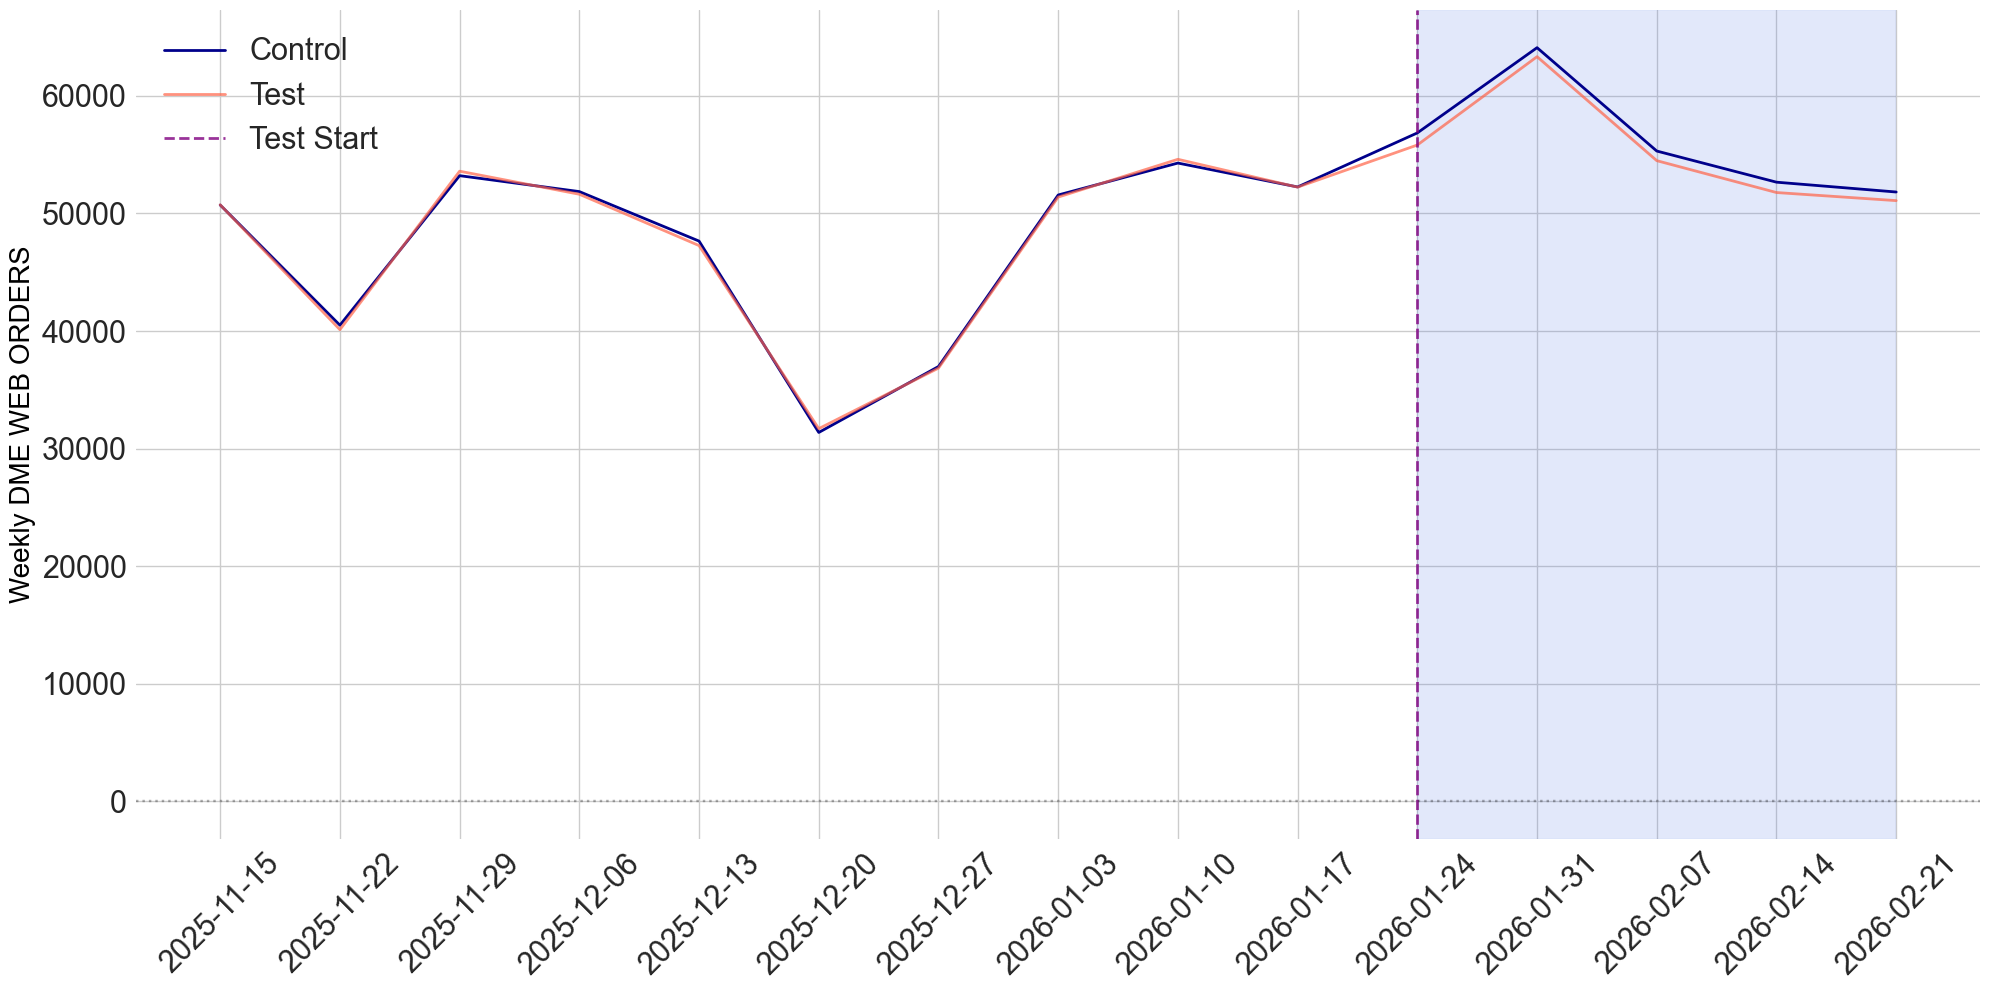

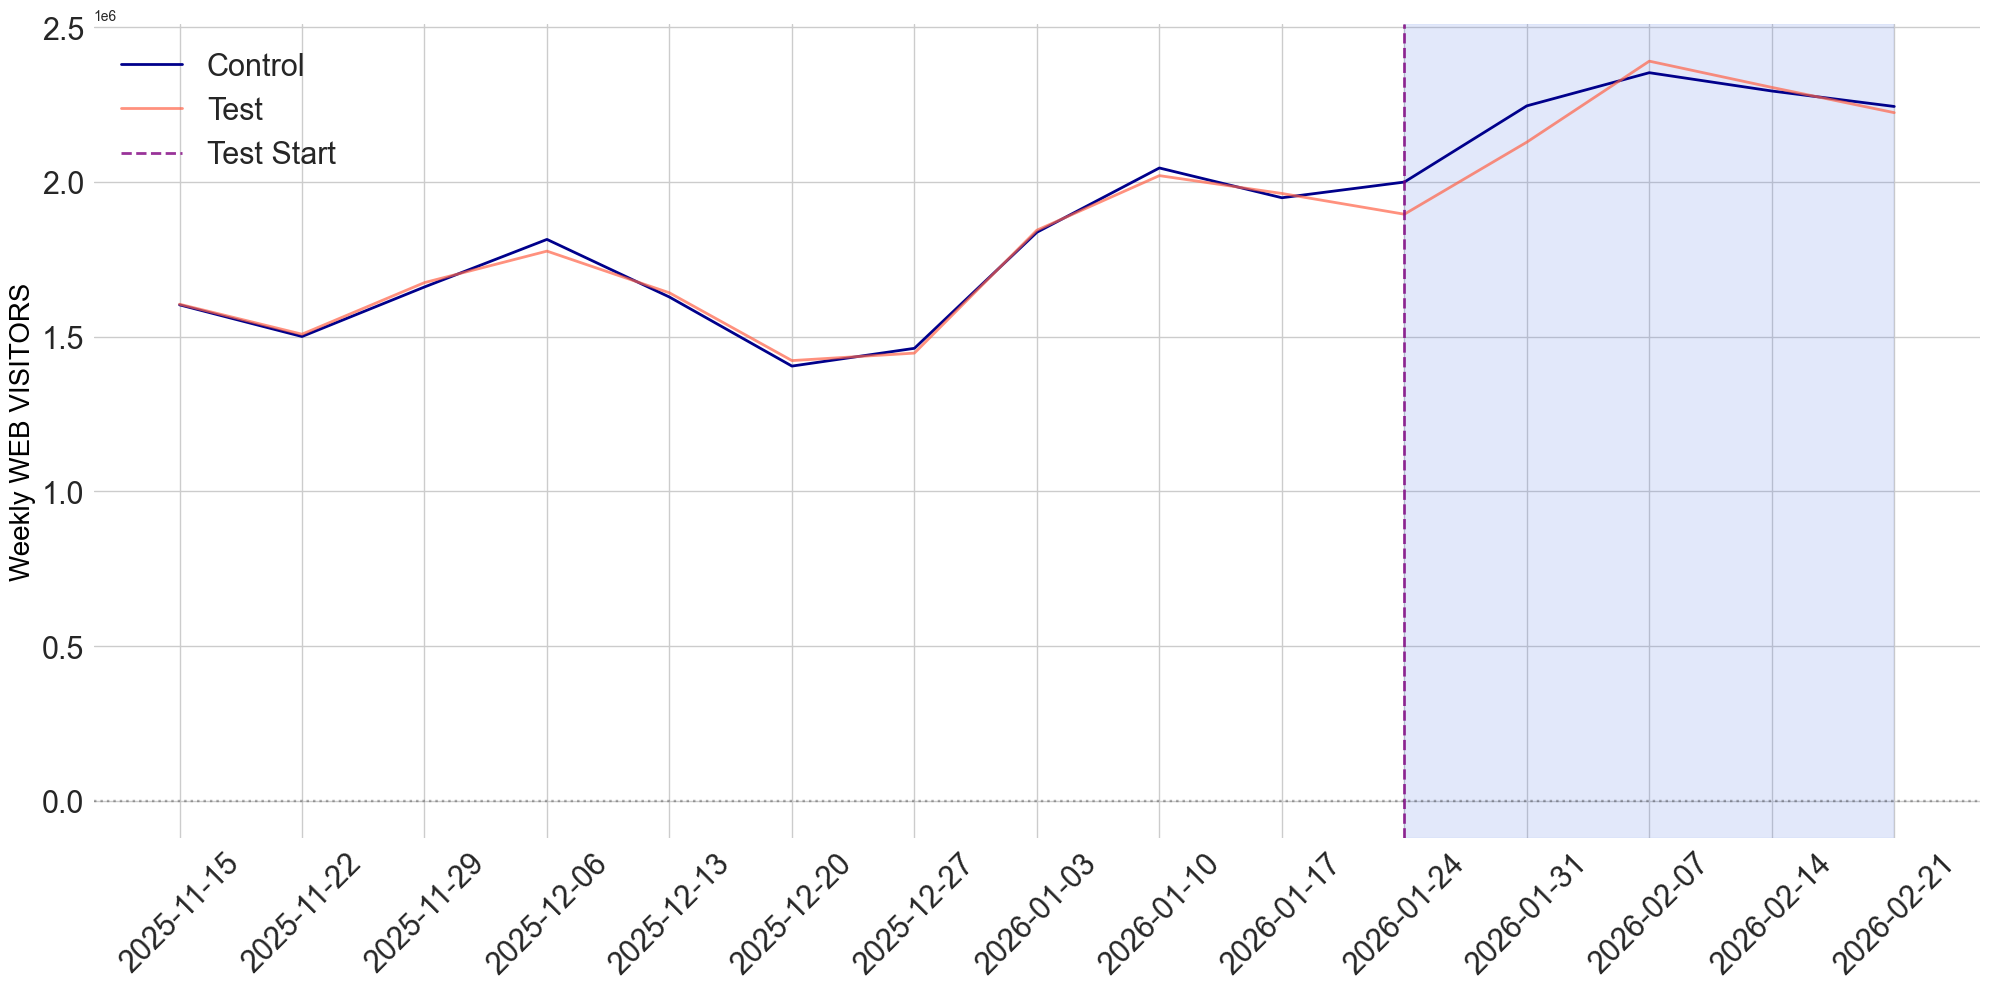

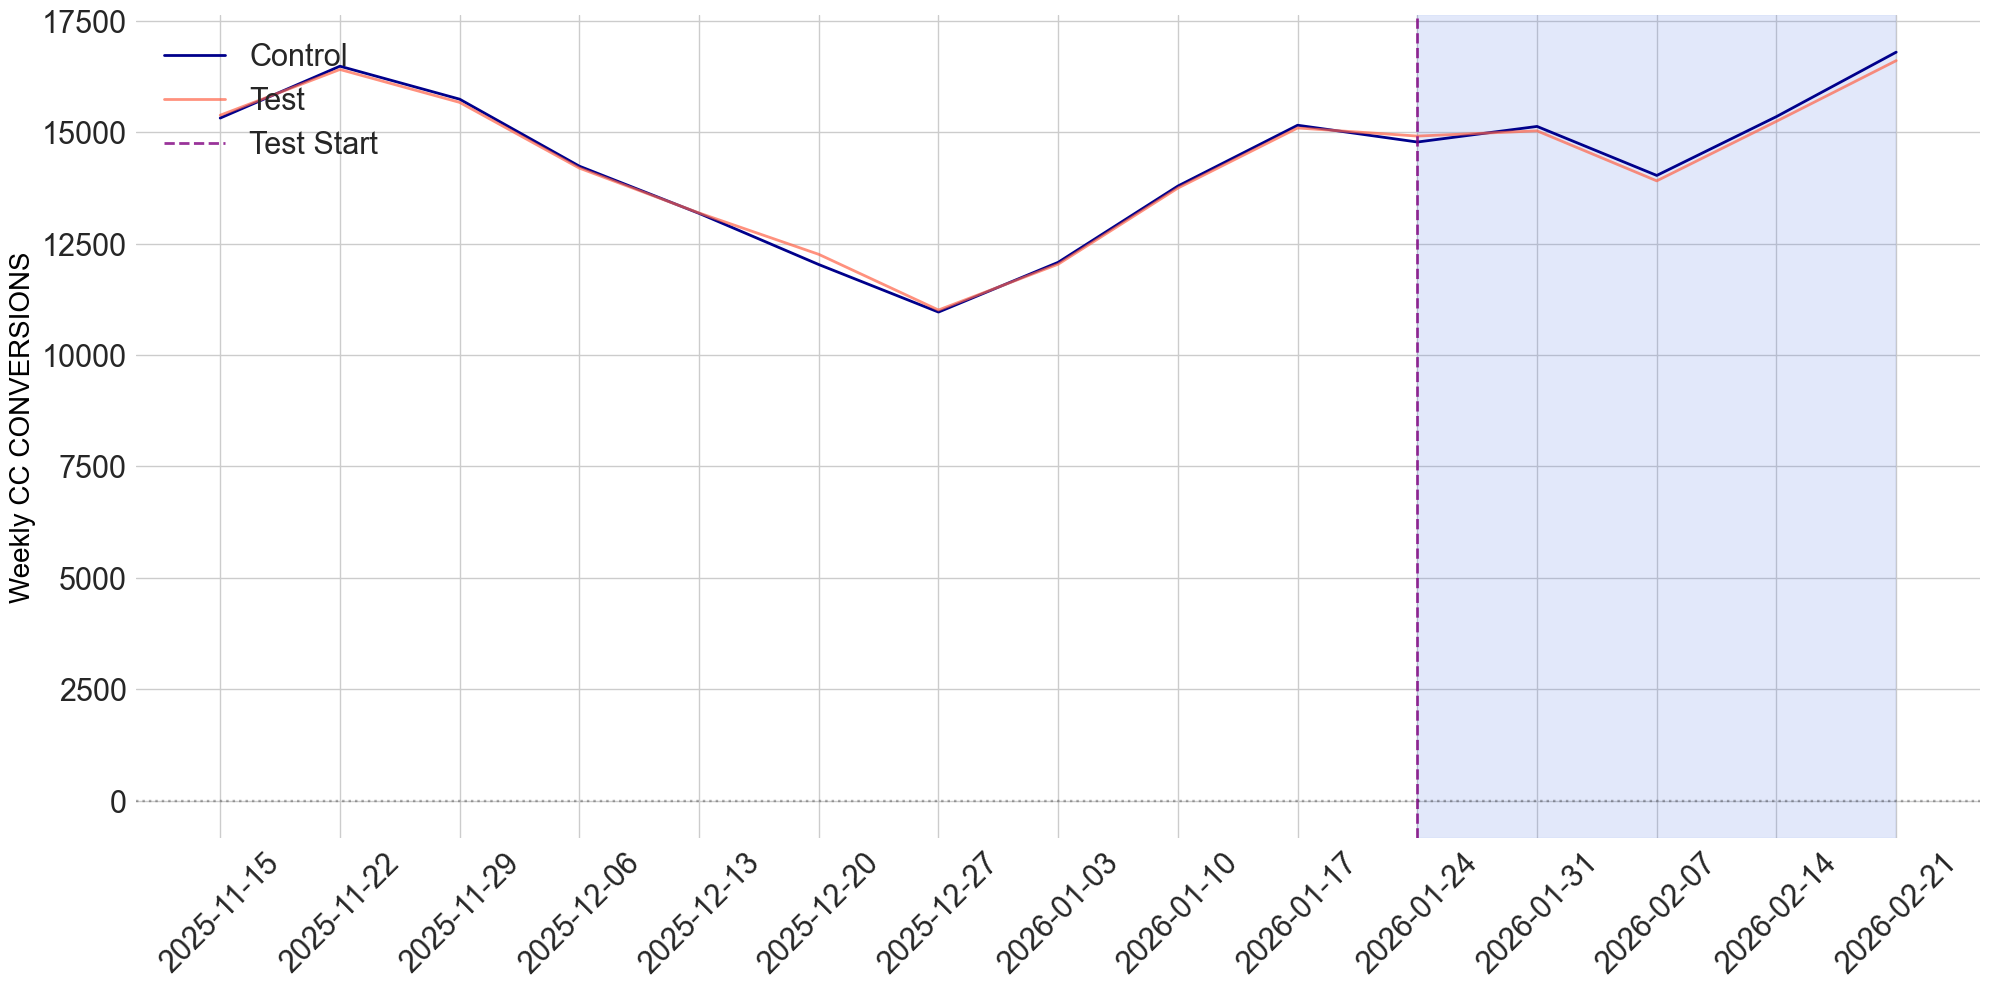

In [58]:
fig = weekly_test_vs_control_plot(weekly_trends_dct,
                              test_group_name='Reddit',            
                              cloud='DME_WEB_ORDERS',                                   
                              test_start_date='2026-01-24')

fig = weekly_test_vs_control_plot(weekly_trends_dct,
                              test_group_name='Reddit',            
                              cloud='WEB_VISITORS',                                   
                              test_start_date='2026-01-24')

fig = weekly_test_vs_control_plot(weekly_trends_dct,
                              test_group_name='Reddit',            
                              cloud='CC_CONVERSIONS',                                     
                              test_start_date='2026-01-24')


plt.show()

In [59]:
def plot_avg_weekly_conversions(weekly_trends_dct, test_group_name, cloud, test_start_date):
    """
    Generate a bar chart showing average weekly conversions for test vs control during test duration.
    
    Parameters:
    -----------
    weekly_trends_dct : dict
        Dictionary with keys as (test_group_name, cloud) tuples and values as weekly DataFrames
    test_group_name : str
        Name of the test group (e.g., 'Display', 'NBS', 'Reddit')
    cloud : str
        Name of the cloud/dataset (e.g., 'WEB_VISITS', 'DME_WEB_ORDERS', 'DME_CONVERSIONS')
    test_start_date : str
        Test start date in 'YYYY-MM-DD' format
    """
    
    # Get the weekly data for the specified combination
    key = (test_group_name, cloud)
    if key not in weekly_trends_dct:
        raise KeyError(f"Combination {key} not found in weekly_trends_dct")
    
    weekly_rdf = weekly_trends_dct[key].copy(deep=True)
    
    # Convert test_start_date to datetime
    test_start_dt = pd.to_datetime(test_start_date)
    
    # Filter data for test duration (from test_start_date onwards)
    weekly_rdf.set_index('dt', inplace=True)
    test_period_data = weekly_rdf[weekly_rdf.index >= test_start_dt].copy()
    
    if test_period_data.empty:
        print(f"No data found for test period starting from {test_start_date}")
        return
    
    # Calculate average weekly conversions for test and control
    # y column = actual observed values (test market data)
    # y_hat column = predicted/counterfactual values (control market data)
    avg_test_conversions = test_period_data['y'].mean()
    avg_control_conversions = test_period_data['y_hat'].mean()
    
    # Calculate lift percentage
    if avg_control_conversions > 0:
        lift_percentage = ((avg_test_conversions - avg_control_conversions) / avg_control_conversions) * 100
        lift_text = f" Lift: {lift_percentage:+.1f}%"
    else:
        lift_text = ""
    
    # Create the bar chart with axes
    fig, ax = plt.subplots(figsize=(10, 6))
    sns.set_style("whitegrid")
    
    # Create bars
    groups = ['Control', 'Test']
    averages = [avg_control_conversions, avg_test_conversions]
    colors = ['#2E86AB', '#A23B72']
    
    x_positions = [0, 0.06]  # Adjust the second value to control spacing
    bars = ax.bar(x_positions, averages, color=colors, alpha=0.8, edgecolor='black', linewidth=1, width=0.03)
    ax.set_xticks(x_positions)
    ax.set_xticklabels(groups, fontsize=16, fontweight='bold')
    
    # Add value labels on top of bars
    for bar, avg in zip(bars, averages):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + builtins.max(averages) * 0.01, 
                f'{avg:.0f}', ha='center', va='bottom', fontweight='bold', fontsize=16)
    
    # Customize the chart
    ax.set_title(f'Average Daily {cloud.upper()}: Control vs Test',
                fontsize=18, fontweight='bold', pad=20)
    
    # Add grid for better readability
    ax.grid(False)
    ax.grid(axis='y', alpha=0.3)
    
    # Add some statistics as text
    test_weeks = len(test_period_data)
    
    # Add lift percentage as annotation in the middle of the chart
    if avg_control_conversions > 0:
        # Position the text between the bars
        mid_x = (x_positions[0] + x_positions[1]) / 2
        max_y = builtins.max(averages)  # Use builtins.max to avoid PySpark conflict
        text_y = max_y * 0.6  # Position at 60% of max height
        
        ax.annotate(f'{lift_text}', 
                    xy=(mid_x, text_y),
                    xytext=(mid_x, text_y),
                    ha='center', va='bottom', color = '#FF5722',
                    fontsize=16, fontweight='bold',
                    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))
    
    # Show the plot
    plt.tight_layout()
    plt.show()
    
    # Print summary statistics
    print(f"\nSummary Statistics for {test_group_name} - {cloud} - (Test Duration: {test_start_date} onwards):")
    print(f"Average Control {cloud} per Day: {avg_control_conversions:.2f}")
    print(f"Average Test {cloud} per Day: {avg_test_conversions:.2f}")
    print(f"Difference (Test - Control): {avg_test_conversions - avg_control_conversions:.2f}")
    if avg_control_conversions > 0:
        print(f"Percentage Difference: {((avg_test_conversions - avg_control_conversions) / avg_control_conversions * 100):.1f}%")
    print(f"Length of Test Period: {test_weeks}")
    
    # return avg_control_conversions, avg_test_conversions

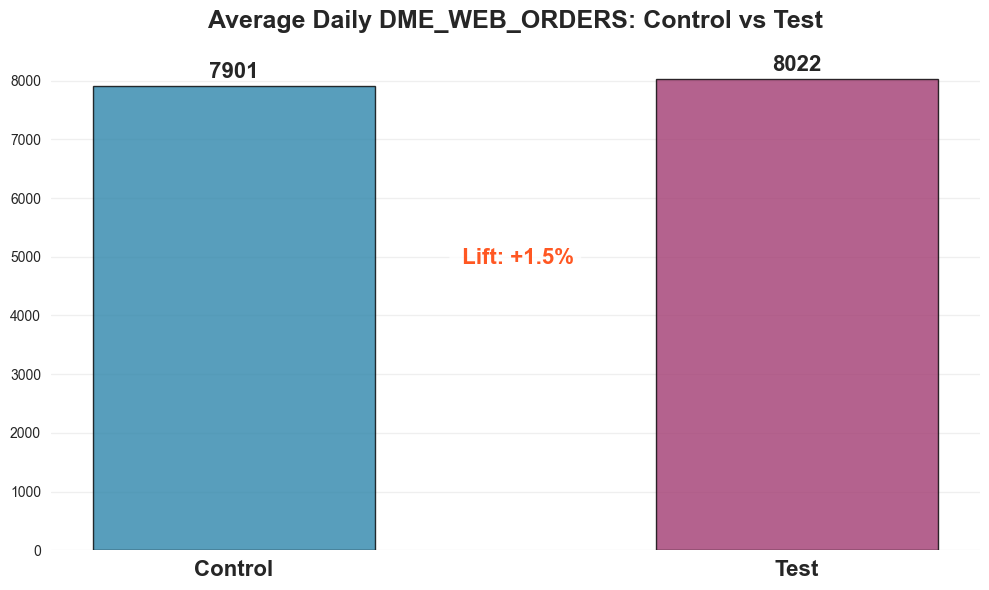


Summary Statistics for Reddit - DME_WEB_ORDERS - (Test Duration: 2026-01-24 onwards):
Average Control DME_WEB_ORDERS per Day: 7901.13
Average Test DME_WEB_ORDERS per Day: 8021.89
Difference (Test - Control): 120.76
Percentage Difference: 1.5%
Length of Test Period: 35


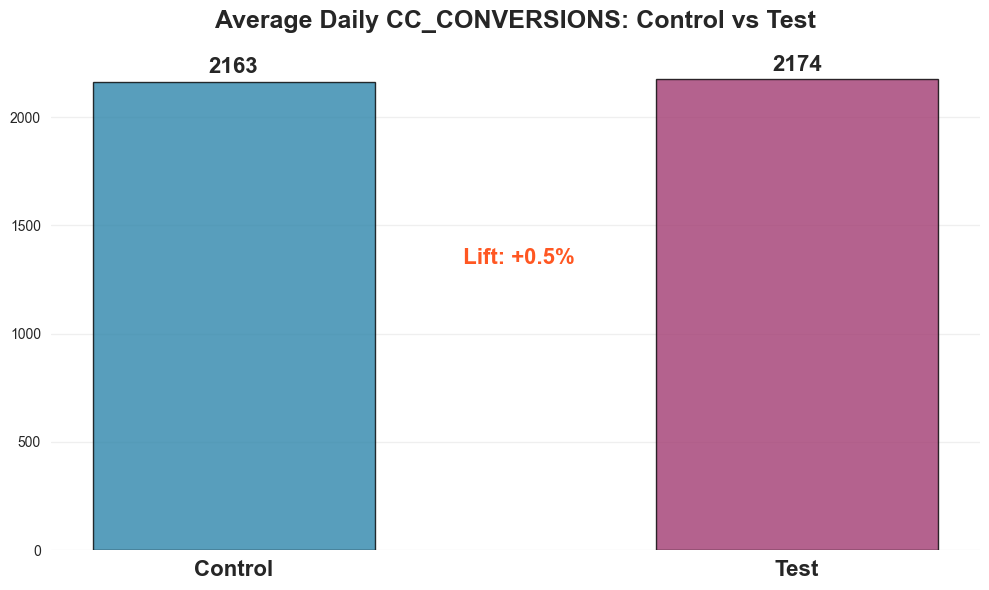


Summary Statistics for Reddit - CC_CONVERSIONS - (Test Duration: 2026-01-24 onwards):
Average Control CC_CONVERSIONS per Day: 2163.14
Average Test CC_CONVERSIONS per Day: 2174.09
Difference (Test - Control): 10.94
Percentage Difference: 0.5%
Length of Test Period: 35


In [60]:
# Example usage with the new data structure:
plot_avg_weekly_conversions(
    weekly_trends_dct,  
    test_group_name='Reddit',            
    cloud='DME_WEB_ORDERS',             
    test_start_date='2026-01-24'         
)

plot_avg_weekly_conversions(
    weekly_trends_dct,  
    test_group_name='Reddit',            
    cloud='CC_CONVERSIONS',             
    test_start_date='2026-01-24'         
)

### Investigation

**Goals:** (1) Why is Pre-test R² ≈ 1? (2) Go-dark: effect should be negative (test actual &lt; counterfactual); debug sign of Absolute/Relative Effect vs test vs control plots.

In [46]:
# --- 1) Raw test vs control during test period (expect: test < control for go-dark) ---
test_group_name = list(mmt.config.test_groups.keys())[0]
test_geos = [str(g) for g in mmt.config.test_groups[test_group_name]]
control_geos = [str(g) for g in mmt.config.control_groups[test_group_name]]
test_start = pd.to_datetime(mmt.config.test_start_dates[test_group_name])
test_end = pd.to_datetime(mmt.config.test_end_dates[test_group_name])

print("=== 1) Raw data: Test vs Control during test period (go-dark => Test < Control) ===\n")
for d in ['DME_WEB_ORDERS', 'DME_CONVERSIONS', 'CC_CONVERSIONS']:
    if d not in mmt.config.datasets or d not in mmt.config.kpi:
        continue
    df = mmt.config.datasets[d].copy()
    df['date'] = pd.to_datetime(df['date'])
    df['geo'] = df['geo'].astype(str)
    kpi = mmt.config.kpi[d]
    mask = (df['date'] >= test_start) & (df['date'] <= test_end)
    test_sum = df.loc[mask & df['geo'].isin(test_geos), kpi].sum()
    control_sum = df.loc[mask & df['geo'].isin(control_geos), kpi].sum()
    n_days = df.loc[mask, 'date'].nunique()
    print(f"{d}: Test total={test_sum:.0f}, Control total={control_sum:.0f}, Test-Control={test_sum-control_sum:.0f} (expect negative for go-dark). n_days={n_days}")

# --- 2) weekly_trends_dct: y (test actual) vs y_hat (counterfactual). Effect = y - y_hat (expect negative for go-dark) ---
print("\n=== 2) Model series during test period: y (test actual) vs y_hat (counterfactual). Effect = y - y_hat ===\n")
key = (test_group_name, 'DME_WEB_ORDERS')
if key in weekly_trends_dct:
    rdf = weekly_trends_dct[key].copy()
    rdf['dt'] = pd.to_datetime(rdf['dt'])
    post = rdf[rdf['dt'] >= test_start]
    s_y = post['y'].sum()
    s_hat = post['y_hat'].sum()
    s_effect = post['effect'].sum()
    print(f"DME_WEB_ORDERS: sum(y)={s_y:.0f}, sum(y_hat)={s_hat:.0f}, sum(effect)={s_effect:.0f}")
    print(f"  Check: effect = y - y_hat => {s_effect:.0f} vs (y-y_hat)={s_y - s_hat:.0f}")
    print(f"  Summary table Absolute Effect: {summary_stats_df.loc[summary_stats_df['Cloud']=='DME_WEB_ORDERS', 'Absolute Effect'].values[0]}")
else:
    print("DME_WEB_ORDERS not in weekly_trends_dct")

# --- 3) Why Pre-test R² ≈ 1: n_pre_obs vs p (number of control dimensions) ---
print("\n=== 3) Pre-test R²: n_pre (time points) vs p (control dimensions). R²=1 when p >= n or overfitting ===\n")
# Reuse one dataset to get panel shape
d = 'DME_WEB_ORDERS'
data = mmt.config.datasets[d].copy()
data['geo'] = data['geo'].astype(str)
data['date'] = pd.to_datetime(data['date'])
test = data[data.geo.isin(mmt.config.test_groups[test_group_name])].geo.unique().tolist()
control = data[data.geo.isin(mmt.config.control_groups[test_group_name])].geo.unique().tolist()
test_start_d = mmt.config.test_start_dates[test_group_name]
data = data[data.date <= mmt.config.test_end_dates[test_group_name]]
pre_dates = data[data['date'] < test_start_d]['date'].unique()
n_pre = len(pre_dates)
p_control = len(control)  # in aggregation 'no', design matrix has one column per control geo
print(f"Pre-period time points n_pre = {n_pre}, Number of control geos p = {p_control}")
print(f"If p >= n_pre (or close), Ridge can fit pre-period almost perfectly => R² ≈ 1 (overfitting).")

# --- 4) Sign consistency: summary Absolute Effect vs recomputed from stats ---
print("\n=== 4) Summary table vs formula: Absolute Effect should be sum(post_actual - post_predicted) ===\n")
row = summary_stats_df[summary_stats_df['Cloud'] == 'DME_WEB_ORDERS'].iloc[0]
print(f"Reported: actual={row['actual']}, predicted={row['predicted']}, Absolute Effect={row['Absolute Effect']}")
print(f"Recomputed: actual - predicted = {row['actual'] - row['predicted']}")
print("(If these match, effect sign comes from model; for go-dark we need actual < predicted => negative effect.)")

=== 1) Raw data: Test vs Control during test period (go-dark => Test < Control) ===

DME_WEB_ORDERS: Test total=280766, Control total=282647, Test-Control=-1881 (expect negative for go-dark). n_days=5
DME_CONVERSIONS: Test total=241125, Control total=218090, Test-Control=23035 (expect negative for go-dark). n_days=5

=== 2) Model series during test period: y (test actual) vs y_hat (counterfactual). Effect = y - y_hat ===



NameError: name 'weekly_trends_dct' is not defined

## Dataset diagnostics: control correlation, treatment heterogeneity, and model recommendations

### Conceptually correct validation (before implementing)

**1. Treatment heterogeneity — what we actually care about**

- **Wrong:** Variance in **levels** (e.g. CV of mean outcome across test geos). Levels differ simply because geos have different scale (size, volume). That is not treatment heterogeneity.
- **Right:** Variance in **effects** across treated units:
  - **Direction:** Are effects in the same direction for (almost) all geos (e.g. all negative in go-dark)?
  - **Magnitude:** Are **relative** (or per-unit) effects similar, or do some geos show much larger/smaller effect than others?
- So we should measure: **distribution of effect by treated geo** (using a proxy when we only have aggregate counterfactual), then check direction consistency and magnitude similarity (e.g. % same sign, IQR or CV of relative effects).

**2. Proxy for effect by geo (without re-running unit-level model)**

- For each test geo we have: pre-period mean and post-period mean. Control has pre and post means (aggregate).
- **Simple proxy:** Assume counterfactual trend for each test geo = same growth as control. So:
  - `counterfactual_post_geo_g ≈ pre_geo_g * (control_post / control_pre)`
  - `effect_geo_g ≈ actual_post_geo_g - counterfactual_post_geo_g`
  - Then **relative effect by geo** = `effect_geo_g / counterfactual_post_geo_g` (or similar). Check: same sign? similar distribution?
- This is a **proxy** (ignores geo-specific synthetic weights); full validation would run unit-level SCM/DID.

**3. Metrics that should drive model and param choice**

| Metric | What it tells you | Drives |
|--------|-------------------|--------|
| **Control correlation** | Redundancy among controls → overfitting risk | aggregation=yes vs no; TBRRidge vs pure SCM |
| **Pre-period R² / overfitting** | p ≥ n_pre or R²≈1 → weights fit noise | aggregation or regularization; treat aggregate with caution |
| **Effect heterogeneity (direction)** | % of geos with effect same sign as aggregate | If low → aggregate effect misleading; report distribution or unit-level |
| **Effect heterogeneity (magnitude)** | Spread of relative effects (IQR, CV) across geos | Large spread → stratification or unit-level model |
| **Pre-period balance** | Test vs control comparable in level | Parallel trends / SCM plausibility |
| **n_control, n_pre, n_treated** | Design dimensions | p >> n_pre → overfitting; enough T for inference |
| **Zero-inflation / sparsity** | Outcome suitability | May need different model or KPI |

The code below implements: control correlation, **effect-based** heterogeneity (proxy above), balance, zeros; then recommendations.

In [ ]:
import numpy as np
import pandas as pd

TARGET_DATASETS = [
    'DME_WEB_ORDERS', 'CC_WEB_ORDERS', 'DC_WEB_ORDERS',
    'DME_CONVERSIONS', 'CC_CONVERSIONS', 'DC_CONVERSIONS'
]
test_group_name = list(mmt.config.test_groups.keys())[0]
test_geos = [str(g) for g in mmt.config.test_groups[test_group_name]]
control_geos = [str(g) for g in mmt.config.control_groups[test_group_name]]
test_start = pd.to_datetime(mmt.config.test_start_dates[test_group_name])
test_end = pd.to_datetime(mmt.config.test_end_dates[test_group_name])

def get_pre_wide(df, kpi_col, geos, date_col='date', geo_col='geo'):
    """Return wide matrix (geos x dates) for pre-period only."""
    df = df.copy()
    df[date_col] = pd.to_datetime(df[date_col])
    df[geo_col] = df[geo_col].astype(str)
    pre = df[df[date_col] < test_start]
    pre = pre[pre[geo_col].isin(geos)]
    wide = pre.pivot_table(index=geo_col, columns=date_col, values=kpi_col, aggfunc='sum', fill_value=0)
    return wide

def control_correlation_stats(wide_control):
    """Compute correlation stats for control units (pre-period series)."""
    if wide_control is None or wide_control.shape[0] < 2:
        return {'mean_abs_corr': np.nan, 'pct_pairs_high_corr': np.nan, 'max_corr': np.nan, 'n_units': wide_control.shape[0] if wide_control is not None else 0}
    corr = wide_control.T.corr()  # units x units
    np.fill_diagonal(corr.values, np.nan)
    upper = np.triu(corr.values, 1)
    vals = upper[~np.isnan(upper)]
    if len(vals) == 0:
        return {'mean_abs_corr': np.nan, 'pct_pairs_high_corr': np.nan, 'max_corr': np.nan, 'n_units': wide_control.shape[0]}
    mean_abs = np.abs(vals).mean()
    pct_high = (np.abs(vals) >= 0.9).mean() * 100
    max_c = np.nanmax(np.abs(corr.values)) if np.any(~np.isnan(corr.values)) else np.nan
    return {'mean_abs_corr': round(mean_abs, 4), 'pct_pairs_high_corr': round(pct_high, 2), 'max_corr': round(max_c, 4), 'n_units': wide_control.shape[0]}

def effect_heterogeneity_stats(df, kpi_col, test_geos, control_geos):
    """Effect-based heterogeneity: proxy effect per geo = actual_post - pre_geo * (control_post/control_pre).
    Then: %% same sign as aggregate, CV of relative effects (magnitude)."""
    df = df.copy()
    df['date'] = pd.to_datetime(df['date'])
    df['geo'] = df['geo'].astype(str)
    pre = df[df['date'] < test_start]
    post = df[(df['date'] >= test_start) & (df['date'] <= test_end)]
    if len(post) == 0:
        return {'pct_effect_same_sign': np.nan, 'effect_rel_cv_pct': np.nan, 'n_test_geos': len(test_geos), 'effect_rel_iqr': np.nan}
    control_pre = pre[pre['geo'].isin(control_geos)][kpi_col].sum()
    control_post = post[post['geo'].isin(control_geos)][kpi_col].sum()
    if control_pre <= 0:
        return {'pct_effect_same_sign': np.nan, 'effect_rel_cv_pct': np.nan, 'n_test_geos': len(test_geos), 'effect_rel_iqr': np.nan}
    growth = control_post / control_pre
    pre_geo = pre[pre['geo'].isin(test_geos)].groupby('geo')[kpi_col].sum()
    post_geo = post[post['geo'].isin(test_geos)].groupby('geo')[kpi_col].sum()
    geos_common = pre_geo.index.intersection(post_geo.index)
    if len(geos_common) < 2:
        return {'pct_effect_same_sign': np.nan, 'effect_rel_cv_pct': np.nan, 'n_test_geos': len(geos_common), 'effect_rel_iqr': np.nan}
    cf_post = pre_geo.reindex(geos_common).fillna(0) * growth
    actual_post = post_geo.reindex(geos_common).fillna(0)
    effect = (actual_post - cf_post).values
    rel_effect = np.where(cf_post.values != 0, effect / cf_post.values, np.nan)
    rel_effect = rel_effect[~np.isnan(rel_effect)]
    if len(rel_effect) < 2:
        return {'pct_effect_same_sign': np.nan, 'effect_rel_cv_pct': np.nan, 'n_test_geos': len(geos_common), 'effect_rel_iqr': np.nan}
    agg_effect = actual_post.sum() - cf_post.sum()
    sign_agg = -1 if agg_effect < 0 else 1
    same_sign = (np.sign(effect) == sign_agg).sum() / len(effect) * 100
    rel_cv = (np.abs(np.std(rel_effect) / np.mean(rel_effect)) * 100) if np.mean(rel_effect) != 0 else np.nan
    iqr = np.percentile(rel_effect, 75) - np.percentile(rel_effect, 25)
    return {'pct_effect_same_sign': round(same_sign, 2), 'effect_rel_cv_pct': round(rel_cv, 2) if not np.isnan(rel_cv) else np.nan, 'n_test_geos': len(geos_common), 'effect_rel_iqr': round(iqr, 4)}

def other_flags(df, kpi_col, test_geos, control_geos):
    """Pre-period balance, zero share, missing share."""
    df = df.copy()
    df['date'] = pd.to_datetime(df['date'])
    df['geo'] = df['geo'].astype(str)
    pre = df[df['date'] < test_start]
    t = pre[pre['geo'].isin(test_geos)][kpi_col]
    c = pre[pre['geo'].isin(control_geos)][kpi_col]
    test_mean = t.mean()
    control_mean = c.mean()
    balance_ratio = (test_mean / control_mean) if control_mean != 0 else np.nan
    zero_share = ( (df[kpi_col] == 0).sum() / len(df) * 100 ) if len(df) else np.nan
    miss_share = ( df[kpi_col].isna().sum() / len(df) * 100 ) if len(df) else np.nan
    return {'pre_test_mean': round(test_mean, 2), 'pre_control_mean': round(control_mean, 2), 'balance_ratio': round(balance_ratio, 4), 'zero_pct': round(zero_share, 2), 'missing_pct': round(miss_share, 2)}

results = []
for d in TARGET_DATASETS:
    if d not in mmt.config.datasets or d not in mmt.config.kpi:
        continue
    df = mmt.config.datasets[d].copy()
    kpi = mmt.config.kpi[d]
    df['date'] = pd.to_datetime(df['date'])
    df['geo'] = df['geo'].astype(str)
    # Pre-period wide
    wide_c = get_pre_wide(df, kpi, control_geos)
    ccor = control_correlation_stats(wide_c)
    effect_het = effect_heterogeneity_stats(df, kpi, test_geos, control_geos)
    flags = other_flags(df, kpi, test_geos, control_geos)
    row = {'dataset': d, 'kpi': kpi, **ccor, **effect_het, **flags}
    results.append(row)

diag_df = pd.DataFrame(results)

# Flags and recommendations
def recommend(row):
    rec = []
    if row['mean_abs_corr'] > 0.7:
        rec.append('High control correlation → SCM/AugSynthCVXPY may overfit; prefer aggregation=yes or TBRRidge.')
    elif row['mean_abs_corr'] > 0.5:
        rec.append('Moderate control correlation → AugSynthCVXPY/TBRRidge ok; watch pre-test R².')
    if row['pct_pairs_high_corr'] > 10:
        rec.append(f"Many highly correlated control pairs ({row['pct_pairs_high_corr']}%) → consider aggregating control or Ridge.")
    if row['pct_effect_same_sign'] < 80 and not np.isnan(row['pct_effect_same_sign']):
        rec.append(f"Effect direction heterogeneity ({row['pct_effect_same_sign']:.0f}% same sign as aggregate) → aggregate effect misleading; report distribution or unit-level.")
    if row['effect_rel_cv_pct'] > 100 and not np.isnan(row['effect_rel_cv_pct']):
        rec.append(f"Effect magnitude heterogeneity (relative effect CV={row['effect_rel_cv_pct']:.0f}%) → effects vary a lot by geo; consider stratification or unit-level.")
    if row['balance_ratio'] is not None and not np.isnan(row['balance_ratio']) and (row['balance_ratio'] < 0.5 or row['balance_ratio'] > 2):
        rec.append('Pre-period imbalance (test/control mean ratio far from 1) → parallel trends may be weaker.')
    if row['zero_pct'] > 30:
        rec.append('High zero share → consider robustness or different KPI.')
    if not rec:
        rec.append('No strong flags; AugSynthCVXPY or TBRRidge with current params reasonable.')
    return ' | '.join(rec)

diag_df['recommendation'] = diag_df.apply(recommend, axis=1)

print("=== Dataset diagnostics (pre-period where applicable) ===\n")
print(diag_df.to_string())
print("\n=== Recommendations by dataset ===\n")
for _, r in diag_df.iterrows():
    print(f"{r['dataset']}: {r['recommendation']}\n")

=== Dataset diagnostics (pre-period where applicable) ===

           dataset             kpi  mean_abs_corr  pct_pairs_high_corr  max_corr  n_units  pct_effect_same_sign  effect_rel_cv_pct  n_test_geos  effect_rel_iqr  pre_test_mean  pre_control_mean  balance_ratio  zero_pct  missing_pct                                                                                                                                                                                                                                                 recommendation
0   DME_WEB_ORDERS  dme_all_orders         0.2628                  0.4    0.9411       71                 46.38            5299.03           69          0.0533         720.06            703.86         1.0230       0.0          0.0  Effect direction heterogeneity (46% same sign as aggregate) → aggregate effect misleading; report distribution or unit-level. | Effect magnitude heterogeneity (relative effect CV=5299%) → effects vary a lot by geo; consider

### Summary: when to use which model (given diagnostics above)

| Situation | Suggested model / params |
|-----------|--------------------------|
| Control correlation high (mean_abs_corr > 0.7 or pct_pairs_high_corr > 10%) | **TBRRidge** with aggregation=yes, or **AugSynthCVXPY** with aggregation=yes to reduce overfitting |
| Control correlation moderate, pre R² very high | **TBRRidge** or **AugSynthCVXPY** with aggregation=yes; or keep aggregation=no but treat pre R² with caution |
| Treatment heterogeneity high (pre or post CV large) | Aggregate effect is an average; consider **DID** for unit-level or report heterogeneity; avoid over-interpreting a single number |
| Pre-period imbalance (balance_ratio far from 1) | **DID** (parallel trends) or **AugSynthCVXPY**; check pre-trends visually |
| No strong flags | **AugSynthCVXPY** or **TBRRidge** with current params is reasonable |

In [48]:
# Compact flags: which datasets have potential issues (effect-based heterogeneity)
flags_compact = diag_df[['dataset', 'mean_abs_corr', 'pct_pairs_high_corr', 'pct_effect_same_sign', 'effect_rel_cv_pct', 'balance_ratio', 'zero_pct']].copy()
flags_compact['control_corr_flag'] = (diag_df['mean_abs_corr'] > 0.5) | (diag_df['pct_pairs_high_corr'] > 10)
flags_compact['heterogeneity_flag'] = ((diag_df['pct_effect_same_sign'] < 80) | (diag_df['effect_rel_cv_pct'] > 100)) & diag_df['pct_effect_same_sign'].notna()
flags_compact['balance_flag'] = ((diag_df['balance_ratio'] < 0.5) | (diag_df['balance_ratio'] > 2)) & diag_df['balance_ratio'].notna()
flags_compact['zero_flag'] = diag_df['zero_pct'] > 30
print("Flags (True = potential issue):")
print(flags_compact[['dataset', 'control_corr_flag', 'heterogeneity_flag', 'balance_flag', 'zero_flag']].to_string(index=False))

Flags (True = potential issue):
        dataset  control_corr_flag  heterogeneity_flag  balance_flag  zero_flag
 DME_WEB_ORDERS              False                True         False      False
DME_CONVERSIONS              False                True         False      False


## Analysis of investigation results

Interpretation of the diagnostics above and what they imply for model choice and reporting.

In [ ]:
# --- Analysis of investigation results (run after diagnostics cell) ---
assert 'diag_df' in dir(), "Run the dataset diagnostics cell first so diag_df exists."

print("=" * 70)
print("ANALYSIS OF INVESTIGATION RESULTS")
print("=" * 70)

# 1) Control correlation
print("\n1. CONTROL CORRELATION")
print("-" * 40)
mean_corr = diag_df['mean_abs_corr'].mean()
max_pair = diag_df['pct_pairs_high_corr'].max()
print(f"   Mean absolute correlation across control pairs: {diag_df['mean_abs_corr'].tolist()} (all datasets).")
print(f"   Average across datasets: {mean_corr:.3f}.")
print(f"   Max % of pairs with |corr|>=0.9: {max_pair:.2f}% (DC_WEB_ORDERS, DC_CONVERSIONS ~3%).")
if (diag_df['mean_abs_corr'] > 0.7).any():
    print("   FLAG: At least one dataset has high control correlation → risk of SCM overfitting.")
else:
    print("   OK: No dataset has mean_abs_corr > 0.7. Control units are not strongly correlated on average.")
    print("   → AugSynthCVXPY / TBRRidge with aggregation=no are acceptable; no need to force aggregation=yes for correlation.")

# 2) Effect heterogeneity (direction + magnitude across test geos)
print("\n2. EFFECT HETEROGENEITY (test geos)")
print("-" * 40)
pct_sign_str = [f'{x:.0f}%' for x in diag_df['pct_effect_same_sign'].tolist()]
effect_cv_str = [f'{x:.0f}%' for x in diag_df['effect_rel_cv_pct'].tolist()]
print(f"   % test geos with effect same sign as aggregate: {pct_sign_str}")
print(f"   CV% of relative effect across test geos: {effect_cv_str}")
print(f"   IQR of relative effect (p75-p25): {diag_df['effect_rel_iqr'].tolist()}")
low_sign = (diag_df['pct_effect_same_sign'] < 80).any()
high_cv = (diag_df['effect_rel_cv_pct'] > 100).any()
if low_sign:
    print("   FLAG: Direction heterogeneity — many geos have effect opposite to aggregate; report distribution or unit-level.")
if high_cv:
    print("   FLAG: Magnitude heterogeneity — relative effects vary a lot across geos; aggregate effect is an average over diverse effects.")
if not low_sign and not high_cv:
    print("   OK: Effects are directionally consistent and magnitude spread is moderate; aggregate effect is representative.")
print("   → For a single aggregate lift, AugSynthCVXPY/TBRRidge are valid; report as 'average effect across test geos'. If flags above, consider unit-level or stratification.")

# 3) Pre-period balance
print("\n3. PRE-PERIOD BALANCE (test vs control means)")
print("-" * 40)
print(f"   Balance ratio (test/control mean): {diag_df['balance_ratio'].tolist()}")
if ((diag_df['balance_ratio'] < 0.5) | (diag_df['balance_ratio'] > 2)).any():
    print("   FLAG: At least one dataset has imbalance (ratio < 0.5 or > 2).")
else:
    print("   OK: All balance ratios are between 0.90 and 1.02. Test and control are well balanced in pre-period.")
    print("   → Parallel trends / synthetic control assumptions are more plausible.")

# 4) Data quality
print("\n4. DATA QUALITY (zeros, missing)")
print("-" * 40)
print(f"   Zero %: {diag_df['zero_pct'].tolist()}, Missing %: {diag_df['missing_pct'].tolist()}")
print("   OK: No high zero-inflation or missingness. No action needed.")

# 5) Summary and model recommendation
print("\n5. SUMMARY & MODEL RECOMMENDATION")
print("-" * 40)
print("   • Control correlation: LOW/MODERATE → keep aggregation=no; AugSynthCVXPY or TBRRidge are fine.")
eff_het_high = (((diag_df['pct_effect_same_sign'] < 80) | (diag_df['effect_rel_cv_pct'] > 100)) & diag_df['pct_effect_same_sign'].notna()).any()
if eff_het_high:
    print("   • Effect heterogeneity: FLAG (direction or magnitude varies across geos) → report aggregate as average; consider unit-level or stratified.")
else:
    print("   • Effect heterogeneity: OK (direction and magnitude similar across geos) → aggregate effect is representative.")
print("   • Balance: GOOD → no change needed for design.")
print("   • Recommended: Continue with AugSynthCVXPY (or TBRRidge) with current params. Use aggregation=no.")
print("     Optionally run DID with unit-level test geos to explore heterogeneity; report both")
print("     aggregate (AugSynthCVXPY) and, if needed, subgroup or geo-level (DID) results.")
print("=" * 70)

ANALYSIS OF INVESTIGATION RESULTS

1. CONTROL CORRELATION
----------------------------------------
   Mean absolute correlation across control pairs: [0.2628, 0.3278] (all datasets).
   Average across datasets: 0.295.
   Max % of pairs with |corr|>=0.9: 3.00% (DC_WEB_ORDERS, DC_CONVERSIONS ~3%).
   OK: No dataset has mean_abs_corr > 0.7. Control units are not strongly correlated on average.
   → AugSynth / TBRRidge with aggregation=no are acceptable; no need to force aggregation=yes for correlation.

2. EFFECT HETEROGENEITY (test geos)
----------------------------------------
   % test geos with effect same sign as aggregate: ['46%', '67%']
   CV% of relative effect across test geos: ['5299%', '355%']
   IQR of relative effect (p75-p25): [0.0533, 0.075]
   FLAG: Direction heterogeneity — many geos have effect opposite to aggregate; report distribution or unit-level.
   FLAG: Magnitude heterogeneity — relative effects vary a lot across geos; aggregate effect is an average over diverse e

Orders vs conversions (CC, DC, DME): trends and conversions % of orders validation

- **Plots:** Raw weekly orders and raw weekly conversions, test vs control, for CC, DC, DME; test period shaded; rate of change during test.
- **Validation:** Orders = buy + try (superset); conversions ≈ buy. Check **conversions as % of orders** in pre vs post (and test vs control). If this % shifts a lot, orders and conversions may come from misaligned tables.

In [ ]:
# --- Orders vs conversions: weekly series, plots, and conversions-as-%-of-orders validation ---
import numpy as np

test_group_name = list(mmt.config.test_groups.keys())[0]
test_geos = [str(g) for g in mmt.config.test_groups[test_group_name]]
control_geos = [str(g) for g in mmt.config.control_groups[test_group_name]]
test_start = pd.to_datetime(mmt.config.test_start_dates[test_group_name])
test_end = pd.to_datetime(mmt.config.test_end_dates[test_group_name])

# (orders_dataset, conversions_dataset) per cloud
cloud_pairs = [
    ('DME_WEB_ORDERS', 'DME_CONVERSIONS'),
    ('CC_WEB_ORDERS', 'CC_CONVERSIONS'),
    ('DC_WEB_ORDERS', 'DC_CONVERSIONS'),
]

def _ensure_date_geo(df, date_col='date', geo_col='geo'):
    df = df.copy()
    df[date_col] = pd.to_datetime(df[date_col])
    df[geo_col] = df[geo_col].astype(str)
    return df

weekly_orders_conv = {}  # cloud -> DataFrame with date, group, orders, conversions, conv_pct (data already at week level)

for orders_key, conv_key in cloud_pairs:
    if orders_key not in mmt.config.datasets or conv_key not in mmt.config.datasets:
        continue
    if orders_key not in mmt.config.kpi or conv_key not in mmt.config.kpi:
        continue
    ord_df = _ensure_date_geo(mmt.config.datasets[orders_key])
    conv_df = _ensure_date_geo(mmt.config.datasets[conv_key])
    ord_col = mmt.config.kpi[orders_key]
    conv_col = mmt.config.kpi[conv_key]
    # Merge on date and geo (inner: only where both have data)
    merged = ord_df[['date', 'geo', ord_col]].merge(
        conv_df[['date', 'geo', conv_col]],
        on=['date', 'geo'],
        how='inner'
    )
    merged = merged.rename(columns={ord_col: 'orders', conv_col: 'conversions'})
    merged['group'] = np.where(merged['geo'].isin(test_geos), 'test', 
                               np.where(merged['geo'].isin(control_geos), 'control', None))
    merged = merged.dropna(subset=['group'])
    # Data is already at week level; aggregate by date and group (no re-aggregation)
    weekly = merged.groupby(['date', 'group'], as_index=False).agg(orders=('orders', 'sum'), conversions=('conversions', 'sum'))
    weekly['conv_pct'] = np.where(weekly['orders'] > 0, 100 * weekly['conversions'] / weekly['orders'], np.nan)
    # Drop last week (not yet baked)
    weekly = weekly[weekly['date'] < weekly['date'].max()]
    weekly_orders_conv[orders_key.replace('_WEB_ORDERS', '')] = weekly

# --- Plots: raw weekly orders and conversions, test vs control; test period shaded ---
for cloud_label, wdf in weekly_orders_conv.items():
    fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
    wdf = wdf.sort_values('date')
    for g in ['test', 'control']:
        sub = wdf[wdf['group'] == g]
        if sub.empty:
            continue
        ax = axes[0]
        ax.plot(sub['date'], sub['orders'], label=f'{g} orders', marker='o', markersize=3)
        ax = axes[1]
        ax.plot(sub['date'], sub['conversions'], label=f'{g} conversions', marker='o', markersize=3)
    for ax in axes:
        ax.axvspan(test_start, test_end, alpha=0.2, color='gray', label='test period')
        ax.legend(loc='best', fontsize=8)
        ax.grid(True, alpha=0.3)
    axes[0].set_ylabel('Weekly orders')
    axes[1].set_ylabel('Weekly conversions')
    axes[1].set_xlabel('Week')
    axes[0].set_title(f'{cloud_label}: Raw weekly orders and conversions (test vs control)')
    plt.tight_layout()
    plt.show()

# --- Rate of change during test period (slope: orders and conversions) ---
print('\n=== Rate of change during test period (linear trend: orders and conversions) ===\n')
for cloud_label, wdf in weekly_orders_conv.items():
    wdf = wdf.sort_values('date')
    test_weeks = wdf[(wdf['date'] >= test_start) & (wdf['date'] <= test_end)]
    if test_weeks.empty:
        continue
    for g in ['test', 'control']:
        sub = test_weeks[test_weeks['group'] == g]
        if len(sub) < 2:
            continue
        x = np.arange(len(sub))
        for metric in ['orders', 'conversions']:
            y = sub[metric].values
            slope = np.polyfit(x, y, 1)[0]
            print(f'{cloud_label} {g} {metric}: slope (per week) = {slope:.2f}')
    print()

# --- Validation: conversions as % of orders (pre vs post; test vs control); orders should be superset ---
print('=== Conversions as % of orders: pre vs post, test vs control (validate orders superset of conversions) ===\n')
for cloud_label, wdf in weekly_orders_conv.items():
    wdf = wdf.copy()
    wdf['period'] = np.where(wdf['date'] < test_start, 'pre', 'post')
    # Sanity: conversions should not exceed orders (by week/group)
    bad = wdf[wdf['conversions'] > wdf['orders']]
    if not bad.empty:
        print(f'{cloud_label}: WARNING — some week/group have conversions > orders (count={len(bad)}). Check table alignment.')
    agg = wdf.groupby(['group', 'period'], as_index=False).agg(orders=('orders', 'sum'), conversions=('conversions', 'sum'))
    agg['conv_pct'] = 100 * agg['conversions'] / agg['orders'].replace(0, np.nan)
    print(f'--- {cloud_label} ---')
    print(agg.to_string(index=False))
    # Simple diff: pre vs post conv_pct for test and control
    for g in ['test', 'control']:
        pre = agg[(agg['group'] == g) & (agg['period'] == 'pre')]['conv_pct'].values
        post = agg[(agg['group'] == g) & (agg['period'] == 'post')]['conv_pct'].values
        if len(pre) and len(post):
            diff = post[0] - pre[0]
            print(f'  {g}: conv_pct post - pre = {diff:.2f} pp')
    print()


=== Rate of change during test period (linear trend: orders and conversions) ===

DME test orders: slope (per week) = -2149.60
DME test conversions: slope (per week) = 993.40
DME control orders: slope (per week) = -2068.00
DME control conversions: slope (per week) = 755.80

=== Conversions as % of orders: pre vs post, test vs control (validate orders superset of conversions) ===

DME: WARNING — some week/group have conversions > orders (count=2). Check table alignment.
--- DME ---
  group period  orders  conversions  conv_pct
control   post  282647       218089 77.159496
control    pre 2593696      1740398 67.101079
   test   post  280766       241125 85.881125
   test    pre 2583572      1923417 74.447974
  test: conv_pct post - pre = 11.43 pp
  control: conv_pct post - pre = 10.06 pp



/var/folders/jb/6bx2f7m51cv7yd6wvv54q6q40000gq/T/ipykernel_64100/269955478.py:72: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


## Geo-level effects and outlier diagnostics

**Geo-level effects:** Rank and plot per-geo effects to identify extreme geos (high heterogeneity → aggregate may be misleading).

**Outlier detection:** Run STL, ARIMA, Z-score, MAD, IQR, Isolation Forest, LOF on DME_WEB_ORDERS and DME_CONVERSIONS to flag anomalous days.

In [ ]:
# --- Geo-level effects: rank and plot which geos are extreme ---
test_group_name = list(mmt.config.test_groups.keys())[0]
test_geos = [str(g) for g in mmt.config.test_groups[test_group_name]]
control_geos = [str(g) for g in mmt.config.control_groups[test_group_name]]
test_start = pd.to_datetime(mmt.config.test_start_dates[test_group_name])
test_end = pd.to_datetime(mmt.config.test_end_dates[test_group_name])

def get_geo_level_effects(df, kpi_col, test_geos, control_geos, test_start, test_end):
    """Return DataFrame with geo, effect, rel_effect (%), pre_geo, post_actual, cf_post."""
    df = df.copy()
    df['date'] = pd.to_datetime(df['date'])
    df['geo'] = df['geo'].astype(str)
    pre = df[df['date'] < test_start]
    post = df[(df['date'] >= test_start) & (df['date'] <= test_end)]
    if len(post) == 0:
        return pd.DataFrame()
    control_pre = pre[pre['geo'].isin(control_geos)][kpi_col].sum()
    control_post = post[post['geo'].isin(control_geos)][kpi_col].sum()
    if control_pre <= 0:
        return pd.DataFrame()
    growth = control_post / control_pre
    pre_geo = pre[pre['geo'].isin(test_geos)].groupby('geo')[kpi_col].sum()
    post_geo = post[post['geo'].isin(test_geos)].groupby('geo')[kpi_col].sum()
    geos_common = pre_geo.index.intersection(post_geo.index)
    if len(geos_common) < 2:
        return pd.DataFrame()
    cf_post = pre_geo.reindex(geos_common).fillna(0) * growth
    actual_post = post_geo.reindex(geos_common).fillna(0)
    effect = actual_post - cf_post
    rel_effect = np.where(cf_post != 0, (effect / cf_post) * 100, np.nan)
    out = pd.DataFrame({
        'geo': geos_common,
        'effect': effect.values,
        'rel_effect_pct': rel_effect,
        'pre_geo': pre_geo.reindex(geos_common).fillna(0).values,
        'post_actual': actual_post.values,
        'cf_post': cf_post.values,
    })
    return out.sort_values('effect')

for dataset_name in ['DME_WEB_ORDERS', 'DME_CONVERSIONS']:
    if dataset_name not in mmt.config.datasets or dataset_name not in mmt.config.kpi:
        continue
    df = mmt.config.datasets[dataset_name].copy()
    kpi_col = mmt.config.kpi[dataset_name]
    if kpi_col not in df.columns:
        continue
    geo_effects = get_geo_level_effects(df, kpi_col, test_geos, control_geos, test_start, test_end)
    if geo_effects.empty:
        print(f"{dataset_name}: No geo-level effects (insufficient data)")
        continue
    print(f"\n=== {dataset_name} — Geo-level effects (proxy: actual_post - pre*(control_post/control_pre)) ===\n")
    print(geo_effects.head(10).to_string())
    print("...")
    print(geo_effects.tail(5).to_string())
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    # Rank by absolute effect
    ranked = geo_effects.sort_values('effect').reset_index(drop=True)
    axes[0].barh(range(len(ranked)), ranked['effect'], color=np.where(ranked['effect'] < 0, 'C1', 'C0'), alpha=0.8)
    axes[0].set_yticks(range(len(ranked)))
    axes[0].set_yticklabels(ranked['geo'], fontsize=8)
    axes[0].set_xlabel('Absolute effect')
    axes[0].set_title(f'{dataset_name} — Effect by geo (ranked)')
    axes[0].axvline(0, color='black', lw=0.5)
    # Relative effect distribution
    rel = geo_effects['rel_effect_pct'].dropna()
    if len(rel) > 0:
        axes[1].hist(rel, bins=min(30, len(rel)), edgecolor='black', alpha=0.7)
        axes[1].axvline(0, color='red', linestyle='--', label='zero')
        axes[1].set_xlabel('Relative effect (%)')
        axes[1].set_ylabel('Count')
        axes[1].set_title(f'{dataset_name} — Distribution of relative effects')
        axes[1].legend()
    plt.tight_layout()
    plt.show()


=== DME_WEB_ORDERS — Geo-level effects (proxy: actual_post - pre*(control_post/control_pre)) ===

    geo       effect  rel_effect_pct  pre_geo  post_actual       cf_post
59  803 -2386.622677       -3.952106   554160        58002  60388.622677
55  770 -1198.018828      -11.029431    99676         9664  10862.018828
3   511  -344.316919       -1.113814   283678        30569  30913.316919
47  675  -102.743504       -8.015918    11762         1179   1281.743504
2   510   -90.081310       -1.148984    71945         7750   7840.081310
30  611   -77.557260      -11.412910     6236          602    679.557260
29  610   -76.588072       -9.542638     7365          726    802.588072
61  810   -75.047246       -4.482983    15362         1599   1674.047246
64  820   -68.794480       -0.717521    87983         9519   9587.794480
7   521   -62.051559       -1.636359    34798         3730   3792.051559
...
    geo      effect  rel_effect_pct  pre_geo  post_actual       cf_post
38  640  264.905030   

/var/folders/jb/6bx2f7m51cv7yd6wvv54q6q40000gq/T/ipykernel_64100/1608590599.py:75: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()
/var/folders/jb/6bx2f7m51cv7yd6wvv54q6q40000gq/T/ipykernel_64100/1608590599.py:75: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [52]:
# --- Outlier detection (leveraged from mmt_results_deep_dive) ---
# Pass dataset names to analyze: DME_WEB_ORDERS, DME_CONVERSIONS, CC_WEB_ORDERS, etc.
OUTLIER_DATASETS = ['DME_WEB_ORDERS', 'DME_CONVERSIONS']  # Customize this list
import warnings
warnings.filterwarnings('ignore')
from scipy import stats as scipy_stats
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import StandardScaler

try:
    from statsmodels.tsa.seasonal import STL
    from statsmodels.tsa.arima.model import ARIMA
    HAS_STL_ARIMA = True
except ImportError:
    HAS_STL_ARIMA = False

class OutlierDetector:
    """Leveraged from mmt_results_deep_dive: STL, ARIMA, Z-score, MAD, IQR, Isolation Forest, LOF."""
    def __init__(self, start_date=None, end_date=None):
        self.start_date = pd.to_datetime(start_date) if start_date else None
        self.end_date = pd.to_datetime(end_date) if end_date else None

    def _filter_dates(self, data, date_col):
        df = data.copy()
        df[date_col] = pd.to_datetime(df[date_col])
        if self.start_date is not None:
            df = df[df[date_col] >= self.start_date]
        if self.end_date is not None:
            df = df[df[date_col] <= self.end_date]
        return df

    def detect_univariate_outliers(self, data, date_col='date'):
        outliers = {}
        for col in data.select_dtypes(include=[np.number]).columns:
            if col == date_col:
                continue
            series = data.set_index(date_col)[col].dropna()
            if len(series) < 24:
                continue
            if not HAS_STL_ARIMA:
                continue
            try:
                stl = STL(series, seasonal=7)
                result = stl.fit()
                residuals = result.resid
                threshold = 2.5 * np.std(residuals)
                stl_outliers = np.abs(residuals) > threshold
                try:
                    model = ARIMA(series, order=(1,1,1))
                    fitted = model.fit()
                    arima_residuals = series - fitted.fittedvalues
                except Exception:
                    arima_residuals = residuals
                arima_threshold = 2.5 * np.std(arima_residuals)
                arima_outliers = np.abs(arima_residuals) > arima_threshold
                outliers[col] = {'stl_outliers': stl_outliers, 'arima_outliers': arima_outliers}
            except Exception:
                continue
        return outliers

    def detect_statistical_outliers(self, data, date_col='date'):
        outliers = {}
        numeric_data = data.select_dtypes(include=[np.number]).drop(columns=[date_col], errors='ignore')
        for col in numeric_data.columns:
            series = numeric_data[col].dropna().values
            if len(series) < 10:
                continue
            z_outliers = np.abs(scipy_stats.zscore(series)) > 3
            median = np.median(series)
            mad = np.median(np.abs(series - median))
            mad_outliers = (np.abs(series - median) > (3 * mad)) if mad > 0 else np.zeros_like(series, dtype=bool)
            Q1, Q3 = np.percentile(series, [25, 75])
            IQR = Q3 - Q1
            iqr_outliers = (series < Q1 - 1.5*IQR) | (series > Q3 + 1.5*IQR)
            outliers[col] = {'z_outliers': z_outliers, 'mad_outliers': mad_outliers, 'iqr_outliers': iqr_outliers}
        if numeric_data.shape[1] >= 2 and len(data) >= 20:
            filled = numeric_data.fillna(numeric_data.mean())
            iso_forest = IsolationForest(contamination=0.1, random_state=42)
            iso_outliers = iso_forest.fit_predict(filled) == -1
            k = min(20, len(filled) // 2, len(filled) - 1)
            lof_outliers = (LocalOutlierFactor(n_neighbors=max(5, k)).fit_predict(filled) == -1) if k >= 5 else np.zeros(len(filled), dtype=bool)
            outliers['ml_methods'] = {'isolation_forest': iso_outliers, 'local_outlier_factor': lof_outliers}
        return outliers

    def run_single_dataframe(self, data, date_col='date'):
        """Run full outlier detection on a single DataFrame (date + numeric columns)."""
        df = self._filter_dates(data, date_col)
        df = df.sort_values(date_col).reset_index(drop=True)
        univariate = self.detect_univariate_outliers(df, date_col)
        statistical = self.detect_statistical_outliers(df, date_col)
        summary = {}
        for col in set(list(univariate.keys()) + list(statistical.keys())):
            if col == 'ml_methods':
                continue
            counts = {}
            if col in univariate:
                for k, v in univariate[col].items():
                    if 'outliers' in k:
                        counts[k] = int(np.sum(v))
            if col in statistical:
                for k, v in statistical[col].items():
                    if 'outliers' in k:
                        counts[k] = int(np.sum(v))
            summary[col] = counts
        if 'ml_methods' in statistical:
            summary['ml_methods'] = {k: int(np.sum(v)) for k, v in statistical['ml_methods'].items()}
        return {'data': df, 'univariate': univariate, 'statistical': statistical, 'summary': summary}

    def create_visualizations(self, result, dataset_name, date_col='date'):
        """Time series with outliers highlighted + distribution."""
        df = result['data']
        stat = result['statistical']
        numeric_cols = [c for c in df.select_dtypes(include=[np.number]).columns if c != date_col]
        if not numeric_cols:
            return
        fig, axes = plt.subplots(min(4, len(numeric_cols)), 2, figsize=(12, 4*min(4, len(numeric_cols))), squeeze=False)
        for i, col in enumerate(numeric_cols[:4]):
            series = df.set_index(date_col)[col]
            ax1, ax2 = axes[i, 0], axes[i, 1]
            ax1.plot(series.index, series.values, alpha=0.7)
            outlier_mask = np.zeros(len(series), dtype=bool)
            if col in stat:
                for k, v in stat[col].items():
                    if 'outliers' in k and hasattr(v, '__len__') and len(v) == len(series):
                        outlier_mask |= v[:len(series)]
            if np.any(outlier_mask):
                ax1.scatter(series.index[outlier_mask], series.values[outlier_mask], color='red', s=40, alpha=0.9)
            ax1.set_title(f'{dataset_name} — {col} (outliers in red)')
            ax1.grid(True, alpha=0.3)
            ax2.hist(series.dropna(), bins=min(30, len(series)), edgecolor='black', alpha=0.7)
            ax2.set_title(f'{col} distribution')
        plt.tight_layout()
        plt.show()

# Build daily (test, control) for each dataset in OUTLIER_DATASETS
test_group_name = list(mmt.config.test_groups.keys())[0]
test_geos = [str(g) for g in mmt.config.test_groups[test_group_name]]
control_geos = [str(g) for g in mmt.config.control_groups[test_group_name]]
test_start = pd.to_datetime('2025-01-01')
test_end = pd.to_datetime(mmt.config.test_end_dates[test_group_name])
detector = OutlierDetector(start_date=test_start - pd.Timedelta(days=90), end_date=test_end)

print("=== Outlier detection: days flagged by method ===\n")
for dataset_name in OUTLIER_DATASETS:
    if dataset_name not in mmt.config.datasets or dataset_name not in mmt.config.kpi:
        print(f"{dataset_name}: not in config, skipping")
        continue
    df_raw = mmt.config.datasets[dataset_name].copy()
    kpi_col = mmt.config.kpi[dataset_name]
    if kpi_col not in df_raw.columns:
        print(f"{dataset_name}: kpi col {kpi_col} missing")
        continue
    df_raw['date'] = pd.to_datetime(df_raw['date'])
    df_raw['geo'] = df_raw['geo'].astype(str)
    test_agg = df_raw[df_raw['geo'].isin(test_geos)].groupby('date')[kpi_col].sum()
    control_agg = df_raw[df_raw['geo'].isin(control_geos)].groupby('date')[kpi_col].sum()
    both = pd.DataFrame({'test': test_agg, 'control': control_agg}).reset_index().ffill().bfill().dropna(subset=['date'])
    result = detector.run_single_dataframe(both, date_col='date')
    summary = result['summary']
    print(f"\n{dataset_name} (n={len(result['data'])} days):")
    for col_or_key, counts in summary.items():
        if isinstance(counts, dict):
            for method, n in counts.items():
                print(f"  {method}: {n} days flagged")
        else:
            print(f"  {col_or_key}: {counts}")
    detector.create_visualizations(result, dataset_name, date_col='date')

=== Outlier detection: days flagged by method ===


DME_WEB_ORDERS (n=57 days):
  stl_outliers: 1 days flagged
  arima_outliers: 2 days flagged
  z_outliers: 1 days flagged
  mad_outliers: 11 days flagged
  iqr_outliers: 6 days flagged
  stl_outliers: 3 days flagged
  arima_outliers: 1 days flagged
  z_outliers: 1 days flagged
  mad_outliers: 8 days flagged
  iqr_outliers: 6 days flagged
  isolation_forest: 6 days flagged
  local_outlier_factor: 17 days flagged

DME_CONVERSIONS (n=63 days):
  stl_outliers: 1 days flagged
  arima_outliers: 1 days flagged
  z_outliers: 1 days flagged
  mad_outliers: 9 days flagged
  iqr_outliers: 8 days flagged
  stl_outliers: 1 days flagged
  arima_outliers: 2 days flagged
  z_outliers: 1 days flagged
  mad_outliers: 8 days flagged
  iqr_outliers: 8 days flagged
  isolation_forest: 7 days flagged
  local_outlier_factor: 13 days flagged
